# HAGRID — Reproducible Analysis Notebook
## Journal of Transport Geography — Paper Companion

> **Purpose:** This notebook reproduces all figures and tables presented in the paper in the order they appear. Reviewers and readers can execute the cells **sequentially** to verify every result, inspect the underlying data, and explore the analysis pipeline.

**Study Area:** Region Hanover, Germany  
**Simulation Framework:** HAGRID (Holistic Agent-based parcel delivery Generation including Routing and Demand estimation)  
**Reference Day:** Tuesday, May 13, 2025

---

### Notebook Structure *(aligned with the paper)*

| # | Notebook Section | Paper Element | Paper Section | Content |
|:--|:---|:---|:---|:---|
| 1 | Setup & Configuration | — | — | Libraries, figure defaults, area type scheme |
| 2 | Data Loading | — | — | Load all spatial & tabular input datasets |
| 3 | Study Area Characterization | **Figure 1**, **Table 1** | §3.1 | Area type maps & cluster analysis results |
| 4 | Parcel Demand Distribution | **Figure 2** | §3.2 | 7 LSPs × Total / B2C / B2B parcel maps |
| 5 | Calibration & Validation | **Table 2**, **Figure 3** | §3.3 | Operational KPI statistics & validation plots |
| 6 | Tour Characteristics | **Table 3**, **Figure 4**, **Figure 5**, **Figure 6** | §4.1 | Area type metrics, hexbin plots, fleet composition, ECDF & boxplots |
| 7 | Delivery Costs | **Figure 7**, **Figure 8** | §4.2 | Density–cost relationship & cost surface |
| 8 | CO₂ Emissions | **Figure 9**, **Figure 10**, **Table 4** | §4.3 | Emission benchmarking, emission surface & network metrics |
| — | **Appendix** | | | |
| A | Logistics Hub Map & Table | **App. 1A**, **App. 1B** | Appendix | Hub locations map & hub attributes table |
| B | Van Specifications | **App. B** | Appendix | LMD van specs & emission parameters |
| C | Multivariate Pair Grid | **App. C** | Appendix | 6 × 6 pairwise tour-KPI diagnostics |
| D | Operational KPIs by Area Type | **App. D** | Appendix | 34 KPIs × 11 area types + LaTeX export |
| 9 | Summary | — | — | Key findings recap & output file inventory |

> **Note:** Figure and table numbers correspond to the paper manuscript.

## 1. Setup & Configuration

Import all required libraries, configure matplotlib for publication-quality figures, and define the area type classification scheme with associated color palettes used throughout the analysis.

In [1]:
# --- Core Libraries ---
import sys, pathlib, re
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, Point, box
from shapely import wkt
from shapely.ops import linemerge
import pickle

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.font_manager as font_manager
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, to_hex
from matplotlib.patches import Patch
from matplotlib.offsetbox import DrawingArea, HPacker, VPacker, TextArea, AnnotationBbox
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns

# --- Geo / Basemap ---
import contextily as ctx
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# --- Machine Learning / Statistics ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import curve_fit

# --- HAGRID package (needed to unpickle Service objects in result DataFrames) ---
_nb_dir = pathlib.Path.cwd()
_pkg_name = "hagrid_output_analysis"

def _find_package(start: pathlib.Path, name: str, max_depth: int = 4) -> pathlib.Path | None:
    candidates: list[pathlib.Path] = []
    for base in [start] + list(start.parents)[:max_depth]:
        for init in base.rglob(f"{name}/__init__.py"):
            pkg_dir = init.parent
            src_dir = pkg_dir.parent
            if name in [p.name for p in pkg_dir.parents]:
                continue
            candidates.append(src_dir)
    if not candidates:
        return None
    src_hits = [c for c in candidates if c.name == "src"]
    if src_hits:
        return min(src_hits, key=lambda p: len(p.parts))
    return min(candidates, key=lambda p: len(p.parts))

_src_dir = _find_package(_nb_dir, _pkg_name)
if _src_dir is None:
    raise FileNotFoundError(
        f"Could not locate '{_pkg_name}' package starting from {_nb_dir}."
    )
if str(_src_dir) not in sys.path:
    sys.path.insert(0, str(_src_dir))

from hagrid_output_analysis.models import Service  # noqa: F401 — required for pickle

# Ensure Service can be unpickled regardless of slots/dict format
def _service_setstate(self, state):
    if isinstance(state, tuple) and len(state) == 2:
        dict_state, slot_state = state
        for d in (dict_state, slot_state):
            if d:
                for k, v in d.items():
                    object.__setattr__(self, k, v)
    elif isinstance(state, dict):
        for k, v in state.items():
            object.__setattr__(self, k, v)

Service.__setstate__ = _service_setstate

%matplotlib inline

# --- Publication-quality figure defaults ---
sns.set_theme(style='white', palette='mako', rc={'figure.figsize': (7.8, 7.8)})
mpl.rc('font', family='sans-serif', weight='bold')
mpl.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans',
                                    'Bitstream Vera Sans', 'sans-serif']
mpl.rc('xtick', labelsize=8)
mpl.rc('ytick', labelsize=8)

# --- Area Type Classification ---
# 8-category classification based on cluster analysis of the study area
area_type_dict = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence"
}

category_dict = {str(k): v for k, v in area_type_dict.items()}

# Color palette for 8 detailed area types (viridis-based)
category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}

# Build a matching colormap and hex palette for seaborn
category_color = {cat: i / (len(category_color_dict) - 1) for i, cat in enumerate(category_color_dict)}
cmap_area = LinearSegmentedColormap.from_list("custom_cmap", sns.color_palette("viridis_r", len(category_color_dict))[::-1])
palette_dict = {cat: to_hex(cmap_area(category_color[cat])) for cat in category_color_dict}

# Aggregated 3-category mapping (detailed name → group)
AREA_GROUP_LOOKUP = {
    "Metropolitan Center": "Urban",
    "High-Density Residential Use": "Urban",
    "Dense Mixed Use": "Urban",
    "Residential Use": "Suburban",
    "Industrial Use": "Suburban",
    "Urbanized Periphery": "Suburban",
    "Rural with Industrial Influence": "Rural",
    "Rural without Industrial Influence": "Rural",
}

def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'

print("Setup complete.")

Setup complete.


## 2. Data Loading

Load all spatial and tabular datasets required for the analysis. All geospatial data use **EPSG:25832** (ETRS89 / UTM zone 32N).

| Dataset | Source | Description |
|:---|:---|:---|
| Analysis zones (250 m) | HAGRID preprocessing | Regular zones covering Region Hanover |
| Parcel demand | HAGRID demand model | Per-carrier B2B/B2C volumes for the reference day (Tue, 13 May 2025) |
| DHL reference streets | Empirical (2021) | Street-level daily delivery volumes for validation |
| Region boundary | Administrative data | Region Hanover boundary polygon |
| Region clusters | Cluster analysis | Pre-computed area type classifications (8 detailed + 3 aggregated) |
| Socioeconomic data | Census & company register | Population locations, company locations with employee counts |
| Tour results (basecase) | HAGRID + MATSim | Simulated tour-level KPIs (500 iterations, reference day) |

In [2]:
# --- Analysis Grid (250 m cells) ---
grid_gdf = gpd.read_file("../input/final_grid_250.shp")
grid_gdf = grid_gdf.reset_index().rename(columns={"index": "grid_index"})

# --- Parcel Demand (Reference Day: Tuesday) ---
parcel_input_demand_tuesday = gpd.read_file("../input/hagrid_parcel_demand_2025-05-13_(Tuesday).shp")

# CRS verification — both must be EPSG:25832 (ETRS89 / UTM zone 32N)
assert grid_gdf.crs.to_epsg() == 25832, "Grid CRS is not EPSG:25832"
assert parcel_input_demand_tuesday.crs.to_epsg() == 25832, "Demand CRS is not EPSG:25832"

# --- DHL Reference Street Data (2021) for validation ---
dhl_streets_gdf = gpd.read_file("../../parcel-demand-estimation/input/dhl2streets_2021.shp", encoding='UTF-8')
dhl_streets_gdf = dhl_streets_gdf.to_crs("EPSG:25832")
dhl_streets_gdf = dhl_streets_gdf.rename(columns={'tagesschni': 'dhl_tag'})  # daily DHL volume

# --- Region Hanover Boundary ---
gdf_region = gpd.read_file("../input/Region Hannover.shp")
gdf_region = gdf_region.to_crs(epsg=25832)

# --- Region Clusters (Area Types from cluster analysis) ---
with open('../input/regionclusters.pkl', 'rb') as f:
    regionclusters = pd.read_pickle(f)

# Assign area type labels
regionclusters['area_type_agg'] = regionclusters['raumtyp'].apply(determine_area_type)
regionclusters['area_type'] = regionclusters['raumtyp'].astype(str).map(category_dict)

# --- Socioeconomic Data ---
unternehmen = gpd.read_file('../input/companies_Total_reduced.shp')
persons_total = gpd.read_file("../input/persons_total.shp")

# --- Tour-Level Simulation Results (Basecase, Tuesday) ---
bc = pd.read_pickle('../input/simRes/batch/processed/basecase_13052025_500it_result_JoTG_distance_sort.pkl')
bc_valid = bc[bc['Vehicle Utilization (%)'] > 0.05].copy()

print(f"Grid cells: {len(grid_gdf):,}")
print(f"Parcel demand points: {len(parcel_input_demand_tuesday):,}")
print(f"DHL reference streets: {len(dhl_streets_gdf):,}")
print(f"Region clusters: {len(regionclusters):,}")
print(f"Companies: {len(unternehmen):,}")
print(f"Persons: {len(persons_total):,}")
print(f"Tours (basecase): {len(bc):,}")
print("All data loaded successfully.")

c:\Users\bienzeisler\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)


Grid cells: 15,917
Parcel demand points: 69,302
DHL reference streets: 12,342
Region clusters: 8
Companies: 52,931
Persons: 1,150,862
Tours (basecase): 1,715
All data loaded successfully.


## 3. Study Area Characterization *(→ Figure 1)*

The Region Hanover serves as the study area, encompassing approximately 2,290 km² with a population of around 1.2 million. To capture the spatial heterogeneity relevant for parcel logistics, we classify the study area in 8 area types

Each spatial unit is assigned one of **8 detailed categories** based on land use, building density, and population structure. For aggregated analyses, these are grouped into **3 macro categories**:

| Aggregated Type | Detailed Categories |
|:---|:---|
| **Urban** | Metropolitan Center, High-Density Residential Use, Dense Mixed Use |
| **Suburban** | Residential Use, Industrial Use, Urbanized Periphery |
| **Rural** | Rural with Industrial Influence, Rural without Industrial Influence |

**Figure 1** presents two complementary views:
- **(a)** Aggregated classification (Urban / Suburban / Rural)
- **(b)** Detailed 8-category classification

This spatial differentiation underpins all subsequent analyses, as parcel demand characteristics, tour performance, and logistics efficiency vary systematically across area types.

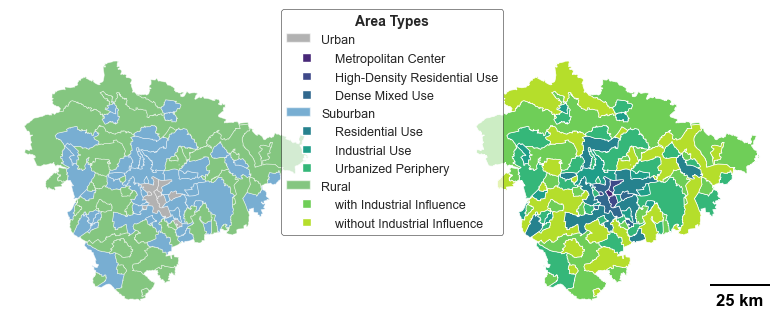

In [3]:
# ── Figure 1: Study Area Characterization — Area Types ──────────────

# Reproject to Web Mercator for map display
regionclusters_copy = regionclusters.copy().to_crs(epsg=3857)

# --- Color definitions ---
agg_colors = {'Urban': '#808080', 'Suburban': '#1f78b4', 'Rural': '#33a02c'}
agg_color_list = [agg_colors[key] for key in sorted(agg_colors.keys())]

detailed_categories = sorted(category_color_dict.keys())
detailed_color_list = [category_color_dict[cat] for cat in detailed_categories]

# Ensure consistent category ordering
regionclusters_copy['area_type'] = regionclusters_copy['area_type'].astype('category')
regionclusters_copy['area_type'] = regionclusters_copy['area_type'].cat.set_categories(detailed_categories)

# --- Dual-panel map (Figure 1) ---
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

# Panel a: Aggregated area types (Urban / Suburban / Rural)
regionclusters_copy.plot(
    column='area_type_agg', ax=axs[0], legend=False, alpha=0.6,
    edgecolor='white', linewidth=0.5, cmap=ListedColormap(agg_color_list)
)
axs[0].set_xticks([])
axs[0].set_yticks([])

# Panel b: Detailed area types (8 categories)
regionclusters_copy.plot(
    column='area_type', ax=axs[1], legend=False, alpha=1,
    edgecolor='white', linewidth=0.5, cmap=ListedColormap(detailed_color_list)
)
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].add_artist(ScaleBar(1, units="m", location='lower right'))

# --- Hierarchical legend (aggregated + detailed sub-categories) ---
from matplotlib.legend_handler import HandlerPatch
import matplotlib.patches as mpatches

class _WideHandler(HandlerPatch):
    """Wide rectangular patch for aggregated categories."""
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        p = mpatches.FancyBboxPatch((xdescent, ydescent + height * 0.15),
                                     width * 0.95, height * 1,
                                     boxstyle="square,pad=0",
                                     facecolor=orig_handle.get_facecolor(),
                                     edgecolor=orig_handle.get_edgecolor(),
                                     alpha=orig_handle.get_alpha(),
                                     transform=trans)
        return [p]

class _SquareHandler(HandlerPatch):
    """Small square patch for detailed sub-categories."""
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        size = height * 1
        p = mpatches.FancyBboxPatch((xdescent + width - size, ydescent + height * 0.05),
                                     size, size,
                                     boxstyle="square,pad=0",
                                     facecolor=orig_handle.get_facecolor(),
                                     edgecolor=orig_handle.get_edgecolor(),
                                     alpha=orig_handle.get_alpha(),
                                     transform=trans)
        return [p]

_agg_patches = [
    Patch(facecolor='#808080', edgecolor='white', label='Urban', alpha=0.6),
    Patch(facecolor='#1f78b4', edgecolor='white', label='Suburban', alpha=0.6),
    Patch(facecolor='#33a02c', edgecolor='white', label='Rural', alpha=0.6),
]
_det_patches = [
    Patch(facecolor='#482878', edgecolor='white', label='    Metropolitan Center'),
    Patch(facecolor='#3f4989', edgecolor='white', label='    High-Density Residential Use'),
    Patch(facecolor='#31688e', edgecolor='white', label='    Dense Mixed Use'),
    Patch(facecolor='#26828e', edgecolor='white', label='    Residential Use'),
    Patch(facecolor='#1f9e89', edgecolor='white', label='    Industrial Use'),
    Patch(facecolor='#35b779', edgecolor='white', label='    Urbanized Periphery'),
    Patch(facecolor='#6fce58', edgecolor='white', label='    with Industrial Influence'),
    Patch(facecolor='#b5de2b', edgecolor='white', label='    without Industrial Influence'),
]

legend_elements = [
    _agg_patches[0], _det_patches[0], _det_patches[1], _det_patches[2],
    _agg_patches[1], _det_patches[3], _det_patches[4], _det_patches[5],
    _agg_patches[2], _det_patches[6], _det_patches[7],
]
_handler_map = {p: _WideHandler() for p in _agg_patches}
_handler_map.update({p: _SquareHandler() for p in _det_patches})

legend = fig.legend(
    handles=legend_elements,
    labels=[h.get_label() for h in legend_elements],
    loc='lower center', ncol=1, fontsize=9,
    title="Area Types", title_fontsize=10,
    prop={'weight': 'normal', 'size': 9},
    handler_map=_handler_map,
    frameon=True, bbox_to_anchor=(0.5, 0.3)
)
legend.get_frame().set_alpha(0.65)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(0.5)

for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig("figures-and-tables/jotg_figure1_area_types_dual_map.pdf", dpi=300, bbox_inches='tight')
plt.show()

### *(→ Table 1)* — Input Data Sources

> **Table 1** in the paper provides a comprehensive overview of all external input data sources used in the HAGRID framework, including national parcel market statistics, population and company registers, OpenStreetMap building data, logistics service provider (LSP) reference data, and MATSim transport network data.
>
> This table is compiled from external sources and documentation — it is **not generated programmatically** in this notebook. Please refer to **Table 1** in the paper for the complete data source inventory.

## 4. Parcel Demand Distribution *(→ Figure 2)*

Spatial distribution of estimated parcel volumes per 250 m grid cell for each of the **7 logistics service providers (LSPs)** modelled in HAGRID: DHL, DPD, GLS, Hermes, Amazon Logistics, UPS, and FedEx.

The figure is organised as a **7 × 3 panel grid** (carriers × variants):
- **Total** — combined B2B + B2C volumes
- **B2C** — business-to-consumer parcels only
- **B2B** — business-to-business parcels only

Values are displayed on a logarithmic scale (`log1p` transform) to accommodate the wide range of parcel densities spanning from sparse rural cells to dense urban cores. A **shared plasma colormap** with identical value range across all 21 panels enables direct visual comparison of spatial coverage and concentration patterns between carriers and market segments.


In [4]:
# ── 4.0  Data preparation: spatial joins & B2B / B2C aggregation ──────────

target_crs = "EPSG:25832"

def _to_crs(gdf):
    """Reproject to target CRS if necessary."""
    return gdf.to_crs(target_crs) if gdf.crs != target_crs else gdf

# Ensure consistent CRS
regionclusters = _to_crs(regionclusters)
unternehmen   = _to_crs(unternehmen)
persons_total  = _to_crs(persons_total)
pakete         = _to_crs(parcel_input_demand_tuesday)

# Grid-level parcel enrichment 
joined = gpd.sjoin(
    pakete, grid_gdf[["grid_index", "geometry"]], how="inner", predicate="intersects"
)
b2x_cols      = [c for c in pakete.columns if any(c.endswith(s) for s in ("_b2b", "_b2c"))]
grid_enriched = (
    grid_gdf[["grid_index", "cell_size", "postal_cod", "main_landu", "geometry"]]
    .merge(joined.groupby("grid_index")[b2x_cols].sum().reset_index(),
           on="grid_index", how="left")
    .fillna(0)
)
grid_enriched["total_parcels"] = grid_enriched[b2x_cols].sum(axis=1)

#  Cluster-level spatial joins
persons_in_clusters     = gpd.sjoin(persons_total, regionclusters, how="left", predicate="within")
unternehmen_in_clusters = gpd.sjoin(unternehmen,   regionclusters, how="left", predicate="within")
pakete_in_clusters      = gpd.sjoin(pakete,         regionclusters, how="left", predicate="within")

#  B2B / B2C totals per demand point 
provider_b2b_cols = ["ama_b2b", "dhl_b2b", "dpd_b2b", "fxt_b2b", "gls_b2b", "her_b2b", "ups_b2b"]
provider_b2c_cols = ["ama_b2c", "dhl_b2c", "dpd_b2c", "fxt_b2c", "gls_b2c", "her_b2c", "ups_b2c"]

pakete_in_clusters["B2B_sum"] = (
    pakete_in_clusters[[c for c in provider_b2b_cols if c in pakete_in_clusters.columns]]
    .fillna(0).sum(axis=1)
)
pakete_in_clusters["B2C_sum"] = (
    pakete_in_clusters[[c for c in provider_b2c_cols if c in pakete_in_clusters.columns]]
    .fillna(0).sum(axis=1)
)

# Area per cluster (km²) 
regionclusters["area_km2"] = regionclusters.geometry.area / 1e6

print(f"Grid cells with parcels: {(grid_enriched['total_parcels'] > 0).sum():,} / {len(grid_enriched):,}")
print(f"Spatial joins complete — {len(pakete_in_clusters):,} demand points mapped to clusters.")

# --- Carrier distribution maps: Total / B2C / B2B (7 × 3 grid) ---
carriers = ["dhl", "dpd", "gls", "her", "ama", "ups", "fxt"]
carrier_labels = {"dhl": "DHL", "dpd": "DPD", "gls": "GLS", "her": "Hermes",
                  "ama": "Amazon\nLogistics", "ups": "UPS", "fxt": "FedEx"}
variants = ["total", "b2c", "b2b"]
variant_titles = {"total": "Total", "b2c": "B2C", "b2b": "B2B"}

# Compute log-transformed columns for each carrier × variant
log_columns = []
for carrier in carriers:
    grid_enriched[f"{carrier}_total"] = grid_enriched[f"{carrier}_b2b"] + grid_enriched[f"{carrier}_b2c"]
    for var in variants:
        log_col = f"{carrier}_{var}_log"
        grid_enriched[log_col] = np.log1p(grid_enriched[f"{carrier}_{var}"])
        log_columns.append(log_col)

Grid cells with parcels: 6,949 / 15,917
Spatial joins complete — 69,302 demand points mapped to clusters.


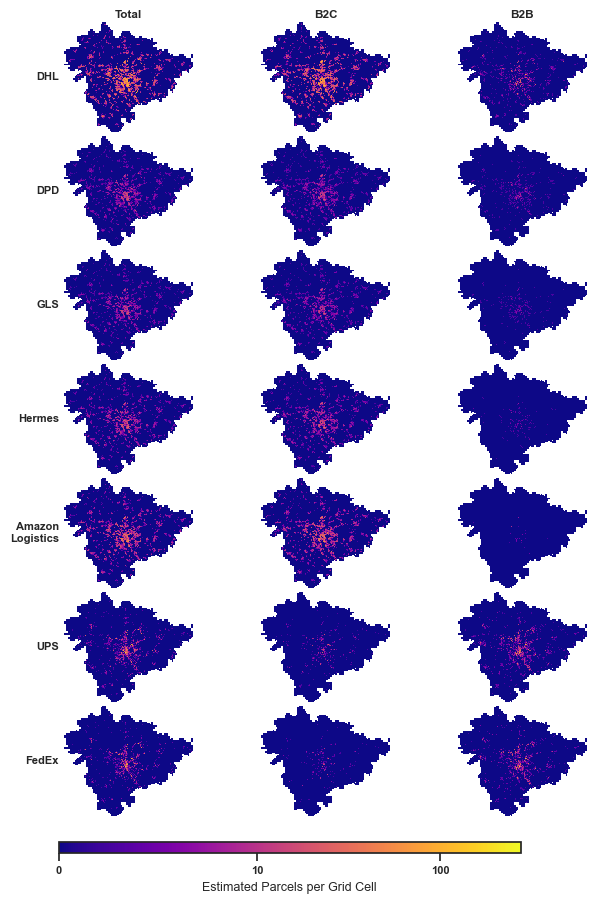

In [5]:
# Shared color scale across all panels for comparability
global_vmax = grid_enriched[log_columns].max().max()

nrows, ncols = len(carriers), len(variants)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.8, 8.9))

# Use the same tight extent for all maps
xmin, ymin, xmax, ymax = grid_enriched.total_bounds
xpad = (xmax - xmin) * 0.01
ypad = (ymax - ymin) * 0.01

for row, carrier in enumerate(carriers):
    for col, var in enumerate(variants):
        ax = axes[row, col]
        grid_enriched.plot(
            column=f"{carrier}_{var}_log",
            ax=ax,
            cmap="plasma",
            linewidth=0,
            edgecolor="none",
            vmin=0,
            vmax=global_vmax
        )

        # Tight map extent
        ax.set_xlim(xmin - xpad, xmax + xpad)
        ax.set_ylim(ymin - ypad, ymax + ypad)
        ax.set_axis_off()

        # Column headers
        if row == 0:
            ax.set_title(variant_titles[var], fontsize=8.5, weight="bold", pad=2)

        # Row labels
        if col == 0:
            ax.text(
                -0.03,
                0.5,
                carrier_labels[carrier],
                transform=ax.transAxes,
                fontsize=8,
                weight="bold",
                va="center",
                ha="right"
            )

fig.subplots_adjust(
    left=0.12,
    right=0.985,
    top=0.975,
    bottom=0.08,
    wspace=0.01,
    hspace=0.01
)

# Shared colorbar underneath all panels
cbar_ax = fig.add_axes([0.16, 0.04, 0.68, 0.012])
sm = plt.cm.ScalarMappable(
    cmap="plasma",
    norm=mpl.colors.Normalize(vmin=0, vmax=global_vmax)
)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Estimated Parcels per Grid Cell", fontsize=9)

raw_ticks = [0, 10, 100]
tick_positions = [np.log1p(t) for t in raw_ticks]
valid_ticks = [
    (raw, pos) for raw, pos in zip(raw_ticks, tick_positions)
    if pos <= global_vmax
]

cbar.set_ticks([pos for raw, pos in valid_ticks])
cbar.set_ticklabels([str(raw) for raw, pos in valid_ticks])
cbar.ax.tick_params(labelsize=8)

plt.savefig(
    "figures-and-tables/jotg_figure2_carrier_distribution_maps.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 5. Calibration and Validation *(→ Table 2, Figure 3)*

### Table 2 — Descriptive Statistics of Operational KPIs

Summary statistics of the six calibration KPIs across all 1,715 simulated delivery tours. These include measures of central tendency, spread, and range to characterise the overall distribution of tour-level operational outcomes.


In [6]:
# ── Table 2: Descriptive Statistics of Operational KPIs ─────────────────
kpi_cols = {
    'Tour Length (km)': 'Tour Length (km)',
    'Tour Duration (hrs)': 'Tour Duration (hrs)',
    'Driving Share of Tour (%)': 'Driving Share of Tour (%)',
    'Vehicle Utilization (%)': 'Vehicle Utilization (%)',
    'Mean Distance Between Stops (km)': 'Mean Distance Between Stops (km)',
    'Average Speed (km/h)': 'Average Speed (km/h)',
}

desc_rows = []
for label, col in kpi_cols.items():
    s = bc_valid[col]
    desc_rows.append({
        'KPI': label,
        'Count': int(s.count()),
        'Mean': round(s.mean(), 2),
        'Std': round(s.std(), 2),
        'Min': round(s.min(), 2),
        '25%': round(s.quantile(0.25), 2),
        'Median': round(s.median(), 2),
        '75%': round(s.quantile(0.75), 2),
        'Max': round(s.max(), 2),
    })

# Start/end times (Timestamps with date 1970-01-01)
for time_label, time_col in [('Start Time', 'Start time formatted'), ('End Time', 'End time formatted')]:
    ts = bc_valid[time_col]
    desc_rows.append({
        'KPI': time_label,
        'Count': int(ts.count()),
        'Mean': str(ts.mean().time())[:8],
        'Std': '',
        'Min': str(ts.min().time())[:8],
        '25%': str(ts.quantile(0.25).time())[:8],
        'Median': str(ts.median().time())[:8],
        '75%': str(ts.quantile(0.75).time())[:8],
        'Max': str(ts.max().time())[:8],
    })

table2 = pd.DataFrame(desc_rows).set_index('KPI')
table2.to_csv('figures-and-tables/jotg_table2_descriptive_kpis.csv')
table2


,Count,Mean,Std,Min,25%,Median,75%,Max
KPI,,,,,,,,
Tour Length (km),1715,90.33,47.37,6.52,55.38,83.31,116.76,435.82
Tour Duration (hrs),1715,7.68,1.74,0.82,7.35,8.06,8.65,13.56
Driving Share of Tour (%),1715,42.43,15.62,7.19,31.06,42.66,54.0,86.63
Vehicle Utilization (%),1715,0.69,0.21,0.05,0.58,0.74,0.84,1.0
Mean Distance Between Stops (km),1715,1.18,0.57,0.17,0.82,1.05,1.36,7.82
Average Speed (km/h),1715,27.46,5.03,15.39,24.12,26.85,30.11,58.98
Start Time,1715,08:41:43,,06:56:11,07:47:03,08:02:24,09:12:00,17:16:53
End Time,1715,16:22:28,,08:42:28,15:38:44,16:17:05,17:14:26,20:59:27


### Figure 3 — Calibration and Validation

The HAGRID parcel demand model is validated along two complementary dimensions:

1. **Street-level delivery volumes (Panel a):** Observed daily DHL deliveries per street (2021 reference) vs. HAGRID-estimated volumes using OLS regression.
2. **Cumulative distance distribution (Panel b):** Simulated tour distance distribution compared against empirical industry data.

> Streets with extremely high reference volumes (> 1,000 deliveries/day) are excluded as outliers.


In [7]:
# --- Prepare validation data: aggregate DHL volumes by street name ---
demand_agg = parcel_input_demand_tuesday.groupby("name")[["dhl_b2b", "dhl_b2c"]].sum()
demand_agg["total_dhl"] = demand_agg["dhl_b2b"] + demand_agg["dhl_b2c"]

tag_agg = dhl_streets_gdf.groupby("name")[["dhl_tag"]].sum()

merged = demand_agg.merge(tag_agg, on="name")
merged = merged[merged["dhl_tag"] < 1000]  # Filter outlier streets with extremely high reference volumes

print(f"Matched streets for validation: {len(merged):,}")

Matched streets for validation: 8,307


Simulated Distance Distribution (%): [19.9 43.2 25.7  8.5  2.4  0.2]


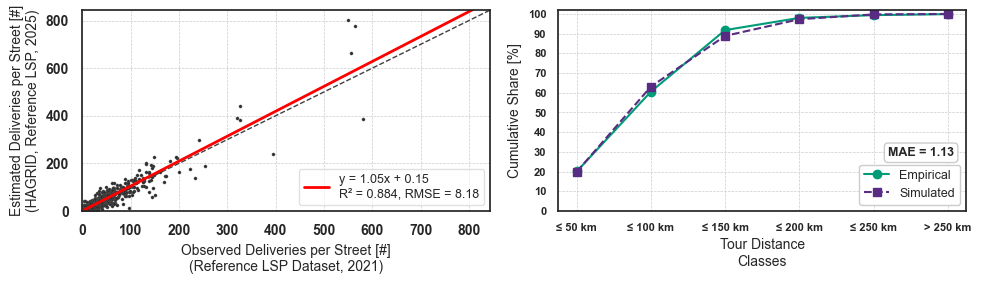

Regression: slope=1.05, intercept=0.15, R²=0.884, RMSE=8.18
Cumulative Distance MAE: 1.13 Percentage Points


In [49]:
from matplotlib.font_manager import FontProperties

# === Cumulative Distance Distribution Data ===
labels = ["\u2264 50 km", "\u2264 100 km", "\u2264 150 km", "\u2264 200 km", "\u2264 250 km", "> 250 km"]
x_dist = np.arange(len(labels))

empirical = np.array([20.1, 40.5, 31.2, 6.2, 1.4, 0.5])

# Compute Simulated Distance Distribution from Simulation Results
bins = [0, 50, 100, 150, 200, 250, np.inf]
tour_lengths = bc_valid['Tour Length (km)']
sim_counts = pd.cut(tour_lengths, bins=bins, right=True).value_counts(sort=False)
simulated = (sim_counts / sim_counts.sum() * 100).values

print("Simulated Distance Distribution (%):", np.round(simulated, 1))

empirical_cumsum = np.cumsum(empirical)
simulated_cumsum = np.cumsum(simulated)

# === Linear Regression on Street-Level DHL Comparison ===
X = merged["dhl_tag"].values.reshape(-1, 1)
y = merged["total_dhl"].values

reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)

slope = reg.coef_[0]
intercept = reg.intercept_
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# === Two-Panel Validation Figure ===
# Avoid Alpha/Transparency to Prevent PDF Rasterization
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

# --- Panel A: Scatter with Regression Line ---
axs[0].scatter(X, y, facecolor="#2C2C2C", edgecolor="#555555", s=5, linewidths=0.3)

lims = [0, max(np.max(X), np.max(y)) * 1.05]
axs[0].plot(lims, lims, '--', color="#404040", linewidth=1)
axs[0].set_xlim(lims)
axs[0].set_ylim(lims)

x_fit = np.linspace(*lims, 200)
y_fit = reg.predict(x_fit.reshape(-1, 1))
label = f"y = {slope:.2f}x + {intercept:.2f}\nR\u00b2 = {r2:.3f}, RMSE = {rmse:.2f}"
axs[0].plot(x_fit, y_fit, color="red", linewidth=2, label=label)

axs[0].set_xlabel("Observed Deliveries per Street [#]\n(Reference LSP Dataset, 2021)", size=10)
axs[0].set_ylabel("Estimated Deliveries per Street [#]\n(HAGRID, Reference LSP, 2025)", size=10)
axs[0].grid(True, linestyle="--", linewidth=0.5, color="#CCCCCC")
axs[0].legend(loc="lower right", fontsize=50, prop={'weight': 'normal', 'size': 9},
              framealpha=0.6, edgecolor="#CCCCCC")
axs[0].tick_params(labelsize=10)

# --- Panel B: Cumulative Distance Distribution ---
axs[1].plot(x_dist, empirical_cumsum, marker="o", linestyle="-", label="Empirical", color="#009B77", linewidth=1.5)
axs[1].plot(x_dist, simulated_cumsum, marker="s", linestyle="--", label="Simulated", color="#582C83", linewidth=1.5)
axs[1].set_xticks(x_dist)
axs[1].set_xticklabels(labels, size=8)
axs[1].set_yticks(np.arange(0, 110, 10))
axs[1].tick_params(axis='both', which='both', direction='out', length=5, width=1)
axs[1].grid(True, linestyle='--', linewidth=0.5, color="#CCCCCC")
axs[1].set_ylabel("Cumulative Share [%]", size=10)
axs[1].set_xlabel("Tour Distance\nClasses", size=10)
axs[1].set_ylim(0, 102)

mae = np.mean(np.abs(simulated_cumsum - empirical_cumsum))
props = dict(boxstyle="round", facecolor="white", edgecolor="#CCCCCC")
axs[1].text(0.97, 0.26, f"MAE = {mae:.2f}", transform=axs[1].transAxes,
            fontsize=9, verticalalignment='bottom', horizontalalignment='right', bbox=props)
axs[1].legend(loc="lower right", fontsize=8, prop={'weight': 'normal', 'size': 9},
              framealpha=1.0, edgecolor="#CCCCCC")

plt.tight_layout()
plt.savefig("figures-and-tables/jotg_figure3_combined_validation_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"Regression: slope={slope:.2f}, intercept={intercept:.2f}, R\u00b2={r2:.3f}, RMSE={rmse:.2f}")
print(f"Cumulative Distance MAE: {mae:.2f} Percentage Points")

## 6. Simulation Results — Tour Characteristics *(→ Table 3, Figures 4–6)*

### Table 3 — Descriptive Metrics for Area Types

Parcel demand, population, and company data are spatially joined to the area-type clusters to produce a quantitative characterisation of each area type. The analysis covers:

- **Demographics** — population density, company density, employee density (per km²)
- **Parcel volume** — total, B2B, and B2C parcels, parcel density per km²
- **B2B share** — ratio of business-to-business parcels to total volume

Results are reported at two levels of spatial aggregation.


In [9]:
# ── 5.0  Data preparation: spatial joins & B2B / B2C aggregation ──────────

target_crs = "EPSG:25832"

def _to_crs(gdf):
    """Reproject to target CRS if necessary."""
    return gdf.to_crs(target_crs) if gdf.crs != target_crs else gdf

# Ensure consistent CRS
regionclusters = _to_crs(regionclusters)
unternehmen   = _to_crs(unternehmen)
persons_total  = _to_crs(persons_total)
pakete         = _to_crs(parcel_input_demand_tuesday)

# ── Grid-level parcel enrichment ─────────────────────────────────────────
joined = gpd.sjoin(
    pakete, grid_gdf[["grid_index", "geometry"]], how="inner", predicate="intersects"
)
b2x_cols      = [c for c in pakete.columns if any(c.endswith(s) for s in ("_b2b", "_b2c"))]
grid_enriched = (
    grid_gdf[["grid_index", "cell_size", "postal_cod", "main_landu", "geometry"]]
    .merge(joined.groupby("grid_index")[b2x_cols].sum().reset_index(),
           on="grid_index", how="left")
    .fillna(0)
)
grid_enriched["total_parcels"] = grid_enriched[b2x_cols].sum(axis=1)

# ── Cluster-level spatial joins ──────────────────────────────────────────
persons_in_clusters     = gpd.sjoin(persons_total, regionclusters, how="left", predicate="within")
unternehmen_in_clusters = gpd.sjoin(unternehmen,   regionclusters, how="left", predicate="within")
pakete_in_clusters      = gpd.sjoin(pakete,         regionclusters, how="left", predicate="within")

# ── B2B / B2C totals per demand point ────────────────────────────────────
provider_b2b_cols = ["ama_b2b", "dhl_b2b", "dpd_b2b", "fxt_b2b", "gls_b2b", "her_b2b", "ups_b2b"]
provider_b2c_cols = ["ama_b2c", "dhl_b2c", "dpd_b2c", "fxt_b2c", "gls_b2c", "her_b2c", "ups_b2c"]

pakete_in_clusters["B2B_sum"] = (
    pakete_in_clusters[[c for c in provider_b2b_cols if c in pakete_in_clusters.columns]]
    .fillna(0).sum(axis=1)
)
pakete_in_clusters["B2C_sum"] = (
    pakete_in_clusters[[c for c in provider_b2c_cols if c in pakete_in_clusters.columns]]
    .fillna(0).sum(axis=1)
)

# ── Area per cluster (km²) ──────────────────────────────────────────────
regionclusters["area_km2"] = regionclusters.geometry.area / 1e6

print(f"Grid cells with parcels: {(grid_enriched['total_parcels'] > 0).sum():,} / {len(grid_enriched):,}")
print(f"Spatial joins complete — {len(pakete_in_clusters):,} demand points mapped to clusters.")

Grid cells with parcels: 6,949 / 15,917
Spatial joins complete — 69,302 demand points mapped to clusters.


#### Table 3a — Detailed Analysis (8 Area Types)

Demographic and parcel metrics aggregated by the 8 detailed area types, including population density, company density, employee density, total parcel volume, B2B/B2C breakdown, parcel density per km², and B2B share.

In [10]:
# ── Reusable aggregation helper ───────────────────────────────────────────
from functools import reduce

_DENSITY_MAP = {
    # density column        ← numerator column
    "persons_density":      "num_persons",
    "companies_density":    "num_companies",
    "employees_density":    "employees",
    "pakete_density":       "num_pakete",
    "b2b_density":          "num_B2B_pakete",
    "b2c_density":          "num_B2C_pakete",
}

def _build_area_summary(group_col: str, csv_path: str) -> pd.DataFrame:
    """Aggregate demographic & parcel metrics by *group_col*, add densities
    and a total row, export transposed CSV, and return the transposed DataFrame."""

    frames = [
        persons_in_clusters.groupby(group_col).size().reset_index(name="num_persons"),
        unternehmen_in_clusters.groupby(group_col).size().reset_index(name="num_companies"),
        unternehmen_in_clusters.groupby(group_col)["employees"].sum().reset_index(),
        pakete_in_clusters.groupby(group_col)["total"].sum().reset_index(name="num_pakete"),
        pakete_in_clusters.groupby(group_col)["B2B_sum"].sum().reset_index(name="num_B2B_pakete"),
        pakete_in_clusters.groupby(group_col)["B2C_sum"].sum().reset_index(name="num_B2C_pakete"),
        regionclusters.groupby(group_col)["area_km2"].sum().reset_index(),
    ]
    df = reduce(lambda l, r: l.merge(r, on=group_col), frames)

    # Densities (per km²) and B2B share
    for den_col, num_col in _DENSITY_MAP.items():
        df[den_col] = df[num_col] / df["area_km2"]
    df["b2b_anteil"] = df["num_B2B_pakete"] / df["num_pakete"]

    # Total row — recompute ratios from sums
    totals = df.select_dtypes("number").sum()
    for den_col, num_col in _DENSITY_MAP.items():
        totals[den_col] = totals[num_col] / totals["area_km2"]
    totals["b2b_anteil"] = totals["num_B2B_pakete"] / totals["num_pakete"]
    totals[group_col] = "Total"

    df = pd.concat([df, pd.DataFrame(totals).T], ignore_index=True)
    df_t = df.set_index(group_col).T
    df_t.to_csv(csv_path)
    return df_t


# ── 6a  Detailed analysis (8 area types) ────────────────────────────────
results_t = _build_area_summary("area_type", "figures-and-tables/jotg_table3_result_raumtyp_diff.csv")
results_t

area_type,Dense Mixed Use,High-Density Residential Use,Industrial Use,Metropolitan Center,Residential Use,Rural with Industrial Influence,Rural without Industrial Influence,Urbanized Periphery,Total
num_persons,155529,125135,81300,11547,278087,135993,93699,269550,1150840.0
num_companies,6974,4617,5880,3967,10253,4880,1863,14496,52930.0
employees,106322,64854,103034,65340,123710,35036,14242,137725,650263.0
num_pakete,23233,21344,16860,6735,54481,25902,17380,56758,222693.0
num_B2B_pakete,5934,4966,4732,3151,10711,3903,1654,12959,48010.0
num_B2C_pakete,17299,16378,12128,3584,43770,21999,15726,43799,174683.0
area_km2,36.416843,11.968036,99.490687,2.406003,201.076208,804.115116,660.618832,479.196132,2295.287857
persons_density,4270.798563,10455.767255,817.161915,4799.245645,1382.993058,169.121308,141.835194,562.50454,501.392449
companies_density,191.504794,385.77758,59.101009,1648.792541,50.990617,6.068783,2.820083,30.250662,23.060288
employees_density,2919.583131,5418.934187,1035.614523,27157.072006,615.239372,43.570876,21.558574,287.408413,283.303464


#### Table 3b — Aggregated Analysis (Urban / Suburban / Rural)

Same metrics as Table 3a, aggregated to the three macro area types for a higher-level comparison.

In [11]:
# ── 6b  Aggregated analysis (3 area types) ───────────────────────────────
results_agg_t = _build_area_summary("area_type_agg", "figures-and-tables/jotg_table3_result_raumtyp_agg.csv")
results_agg_t

area_type_agg,Rural,Suburban,Urban,Total
num_persons,229692,628937,292211,1150840.0
num_companies,6743,30629,15558,52930.0
employees,49278,364469,236516,650263.0
num_pakete,43282,128099,51312,222693.0
num_B2B_pakete,5557,28402,14051,48010.0
num_B2C_pakete,37725,99697,37261,174683.0
area_km2,1464.733948,779.763027,50.790882,2295.287857
persons_density,156.814827,806.574534,5753.217668,501.392449
companies_density,4.603566,39.279882,306.314822,23.060288
employees_density,33.64297,467.409953,4656.662583,283.303464


### Figure 4 — Tour Length vs. Vehicle Utilization (Hexbin Plots)

Hexbin plots showing the relationship between tour length and vehicle utilization for different aggregated area types. Urban tours cluster at high utilization and short distances, suburban tours occupy a balanced middle ground, and rural tours can exceed 150 km with low utilization.


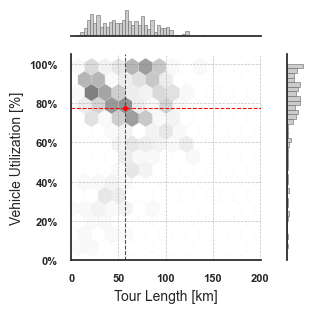

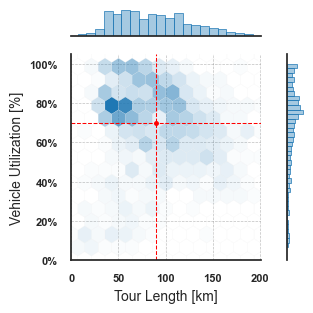

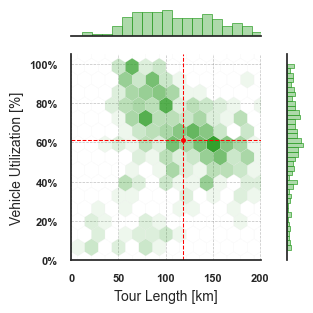

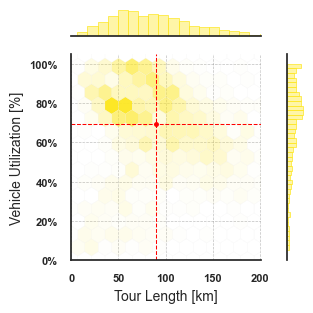

In [47]:
# ── Figure 4: Hexbin JointPlots — Tour Length vs. Vehicle Utilization ───
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]

def create_transparent_cmap(hex_color, n_shades=20):
    color_rgb = np.array(hex_to_rgb(hex_color)) / 255.0
    alpha = np.linspace(0, 1, n_shades)
    cmap_colors = np.column_stack([np.tile(color_rgb, (n_shades, 1)), alpha])
    return LinearSegmentedColormap.from_list(f'{hex_color}_cmap', cmap_colors)

def to_percent(y, position):
    return f"{int(100 * y)}%"

percent_formatter = FuncFormatter(to_percent)

# --- Configuration ---
panel_colors = {
    'Urban': '#808080',
    'Suburban': '#1f78b4',
    'Rural': '#33a02c',
    'Total': '#fde725',
}
panel_labels = {
    'Urban': '(a) Urban',
    'Suburban': '(b) Suburban',
    'Rural': '(c) Rural',
    'Total': '(d) Total',
}
panel_files = {
    'Urban': 'figures-and-tables/jotg_figure4_hexbin_urban.pdf',
    'Suburban': 'figures-and-tables/jotg_figure4_hexbin_suburban.pdf',
    'Rural': 'figures-and-tables/jotg_figure4_hexbin_rural.pdf',
    'Total': 'figures-and-tables/jotg_figure4_hexbin_total.pdf',
}
panel_order = ['Urban', 'Suburban', 'Rural', 'Total']

bc_valid = bc[bc['Vehicle Utilization (%)'] > 0.05].copy()
bc_valid['area_type_agg'] = bc_valid['main_area_type'].apply(determine_area_type)

x_min, x_max = 0, 201
y_min, y_max = 0, 1.05
gridsize = 14

for atype in panel_order:
    subset = bc_valid if atype == 'Total' else bc_valid[bc_valid['area_type_agg'] == atype]
    subset = subset[subset['Tour Length (km)'] < 500]

    cmap = create_transparent_cmap(panel_colors[atype])
    color = panel_colors[atype]

    mean_x = subset['Tour Length (km)'].mean()
    mean_y = subset['Vehicle Utilization (%)'].mean()

    g = sns.jointplot(
        data=subset,
        x='Tour Length (km)',
        y='Vehicle Utilization (%)',
        kind='hex',
        cmap=cmap,
        marginal_kws=dict(bins=40, fill=True, color=color, alpha=0.4,
                          edgecolor=color, linewidth=0.5),
        gridsize=gridsize,
        joint_kws={'extent': (x_min, x_max, y_min, y_max),
                   'edgecolors': 'whitesmoke', 'linewidths': 0.1}
    )
    g.fig.set_size_inches(3.3, 3.3)
    g.ax_joint.set_xlim(x_min, x_max)
    g.ax_joint.set_ylim(y_min, y_max)
    g.ax_joint.set_xticks([0, 50, 100, 150, 200])

    # Mean crosshairs
    g.ax_joint.axhline(mean_y, ls='--', lw=0.75, color='red')
    g.ax_joint.axvline(mean_x, ls='--', lw=0.75, color='red')
    g.ax_joint.plot(mean_x, mean_y, '.', markersize=5, color='red')

    g.ax_joint.yaxis.set_major_formatter(percent_formatter)
    g.ax_joint.tick_params(axis='both', which='major', labelsize=8)
    g.set_axis_labels('Tour Length [km]', 'Vehicle Utilization [%]', fontsize=10)
    # g.ax_joint.set_title(panel_labels[atype], fontsize=10, weight='bold')
    g.ax_joint.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

    plt.tight_layout()
    plt.savefig(panel_files[atype], format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

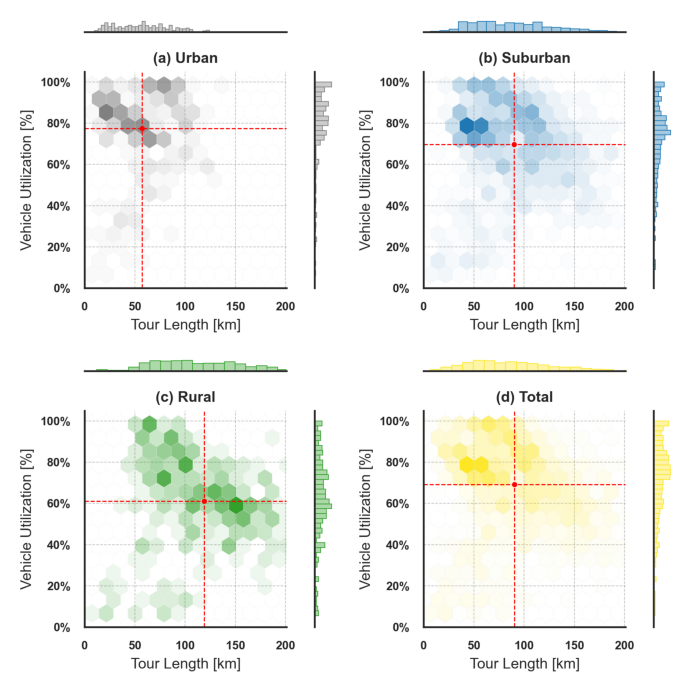

In [46]:
# ── Figure 4 (combined): exact 2x2 composition of the single JointPlots ───
import io
from PIL import Image

panel_order_combined = ['Urban', 'Suburban', 'Rural', 'Total']
panel_grid_pos = {
    'Urban': (0, 0),
    'Suburban': (0, 1),
    'Rural': (1, 0),
    'Total': (1, 1),
}

def render_single_jointplot_panel(atype):
    subset = bc_valid if atype == 'Total' else bc_valid[bc_valid['area_type_agg'] == atype]
    subset = subset[subset['Tour Length (km)'] < 500]

    cmap = create_transparent_cmap(panel_colors[atype])
    color = panel_colors[atype]

    mean_x = subset['Tour Length (km)'].mean()
    mean_y = subset['Vehicle Utilization (%)'].mean()

    g = sns.jointplot(
        data=subset,
        x='Tour Length (km)',
        y='Vehicle Utilization (%)',
        kind='hex',
        cmap=cmap,
        marginal_kws=dict(
            bins=40,
            fill=True,
            color=color,
            alpha=0.4,
            edgecolor=color,
            linewidth=0.5
        ),
        gridsize=gridsize,
        joint_kws={
            'extent': (x_min, x_max, y_min, y_max),
            'edgecolors': 'whitesmoke',
            'linewidths': 0.1
        }
    )

    g.fig.set_size_inches(3.3, 3.3)
    g.ax_joint.set_xlim(x_min, x_max)
    g.ax_joint.set_ylim(y_min, y_max)
    g.ax_joint.set_xticks([0, 50, 100, 150, 200])

    g.ax_joint.axhline(mean_y, ls='--', lw=0.75, color='red')
    g.ax_joint.axvline(mean_x, ls='--', lw=0.75, color='red')
    g.ax_joint.plot(mean_x, mean_y, '.', markersize=5, color='red')

    g.ax_joint.yaxis.set_major_formatter(percent_formatter)
    g.ax_joint.tick_params(axis='both', which='major', labelsize=8)
    g.set_axis_labels('Tour Length [km]', 'Vehicle Utilization [%]', fontsize=10)
    g.ax_joint.set_title(panel_labels[atype], fontsize=10, weight='bold')
    g.ax_joint.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

    g.fig.tight_layout()
    buffer = io.BytesIO()
    g.fig.savefig(buffer, format='png', dpi=300, bbox_inches='tight')
    buffer.seek(0)
    panel_img = np.asarray(Image.open(buffer).convert('RGBA'))
    plt.close(g.fig)
    return panel_img

panel_images = {atype: render_single_jointplot_panel(atype) for atype in panel_order_combined}

fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for atype in panel_order_combined:
    row, col = panel_grid_pos[atype]
    ax = axes[row, col]
    ax.imshow(panel_images[atype])
    ax.axis('off')

fig.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
plt.savefig(
    'figures-and-tables/jotg_figure4_hexbin_combined_2x2_exact.pdf',
    format='pdf',
    dpi=300,
    bbox_inches='tight'
    )
plt.show()

### Figure 5 — Fleet Composition and Total Driven Distance

Comparison of the number of LMD vehicles and total daily driven distance across the three aggregated area types (Urban, Suburban, Rural), differentiated by vehicle class (medium van / large van) and propulsion type (ICE / EV).


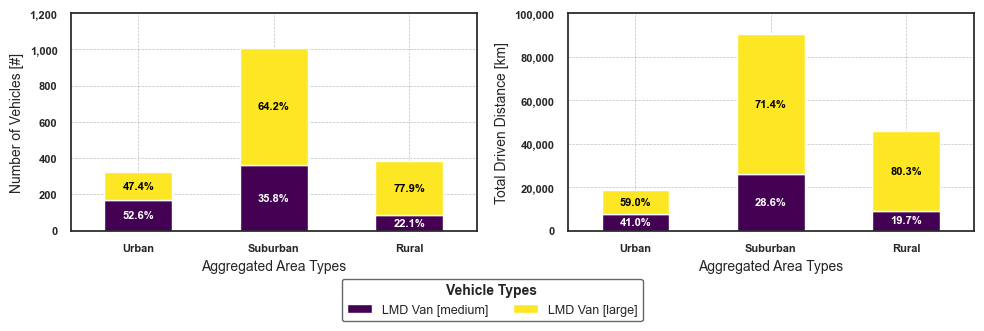

In [13]:
# ── Figure 5: Fleet Composition & Total Driven Distance ─────────────────
import matplotlib.ticker as mticker

def annotate_percent(ax, data, text_colors):
    """Annotate stacked bars with percentage labels."""
    x_positions = np.arange(len(data.index))
    for x_pos, (_, row) in zip(x_positions, data.iterrows()):
        total = row.sum()
        cumulative = 0
        for col_idx, value in enumerate(row):
            if not np.isfinite(value) or value <= 0 or total == 0:
                cumulative += value if np.isfinite(value) else 0
                continue
            pct = value / total * 100
            y = cumulative + value / 2
            ax.text(x_pos, y, f"{pct:.1f}%", ha='center', va='center',
                    color=text_colors[col_idx % len(text_colors)], fontsize=8, fontweight='bold')
            cumulative += value

# Ensure area_type_agg exists on bc_valid
if 'area_type_agg' not in bc_valid.columns:
    bc_valid['area_type_agg'] = bc_valid['main_area_type'].apply(determine_area_type)

aggregated_df = bc_valid.groupby(['area_type_agg', 'veh_size']).agg({
    'vehicle_id': 'count',
    'Tour Length (km)': 'sum'
})

total_tour_length = bc_valid.groupby('area_type_agg')['Tour Length (km)'].sum().rename('Total Tour Length (km)')
aggregated_df = aggregated_df.join(total_tour_length, on='area_type_agg').round(2).reset_index()

scenario_order = ['Urban', 'Suburban', 'Rural']
aggregated_df = aggregated_df[aggregated_df['area_type_agg'].isin(scenario_order)]
aggregated_df['area_type_agg'] = pd.Categorical(aggregated_df['area_type_agg'], categories=scenario_order, ordered=True)
aggregated_df.sort_values('area_type_agg', inplace=True)

veh_order = sorted(aggregated_df['veh_size'].unique())
text_colors = ['white', 'black']

fig, axs = plt.subplots(1, 2, figsize=(10, 3))

# Panel a: Number of vehicles
vehicle_count_plot = aggregated_df.pivot(index='area_type_agg', columns='veh_size', values='vehicle_id')[veh_order]
vehicle_count_plot.plot(kind='bar', stacked=True, ax=axs[0], cmap='viridis')
axs[0].set_ylabel('Number of Vehicles [#]', fontsize=10)
axs[0].set_xlabel('Aggregated Area Types', fontsize=10)
axs[0].set_xticklabels(vehicle_count_plot.index, rotation=0, fontsize=8)
axs[0].set_ylim(0, 1200)
axs[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
annotate_percent(axs[0], vehicle_count_plot, text_colors)

# Panel b: Total driven distance
tour_length_plot = aggregated_df.pivot(index='area_type_agg', columns='veh_size', values='Tour Length (km)')[veh_order]
tour_length_plot.plot(kind='bar', stacked=True, ax=axs[1], cmap='viridis')
axs[1].set_ylabel('Total Driven Distance [km]', fontsize=10)
axs[1].set_xlabel('Aggregated Area Types', fontsize=10)
axs[1].set_xticklabels(tour_length_plot.index, rotation=0, fontsize=8)
axs[1].set_ylim(0, 100000)
axs[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
annotate_percent(axs[1], tour_length_plot, text_colors)

# Unified legend
handles, labels = axs[0].get_legend_handles_labels()
label_map = {
    veh_order[0]: "LMD Van [medium]",
    veh_order[1] if len(veh_order) > 1 else veh_order[0]: "LMD Van [large]"
}
legend_labels = [label_map.get(v, v) for v in veh_order]
fig.legend(handles[:len(veh_order)], legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.12),
           title="Vehicle Types", fontsize=9, title_fontsize=10, ncol=len(legend_labels),
           prop={'weight': 'normal', 'size': 9}, frameon=True, edgecolor='black', framealpha=0.6)
axs[0].get_legend().remove()
axs[1].get_legend().remove()

plt.tight_layout()
for ax in axs:
    ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5, zorder=100)

plt.savefig('figures-and-tables/jotg_figure5_fleet_composition_distance.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

### Figure 6 — Tour KPI Distributions (Boxplots & ECDFs)

The combination of box plots *(above)* and Empirical Cumulative Distribution Function plots *(below)* highlighting different KPI distributions across the 8 detailed area types.

**KPIs analysed:** Tour Length, Tour Duration, Driving Share of Tour, Vehicle Utilization, Mean Distance Between Stops, Average Speed.


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\1839139780.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\1839139780.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\1839139780.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\1839139780.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an 

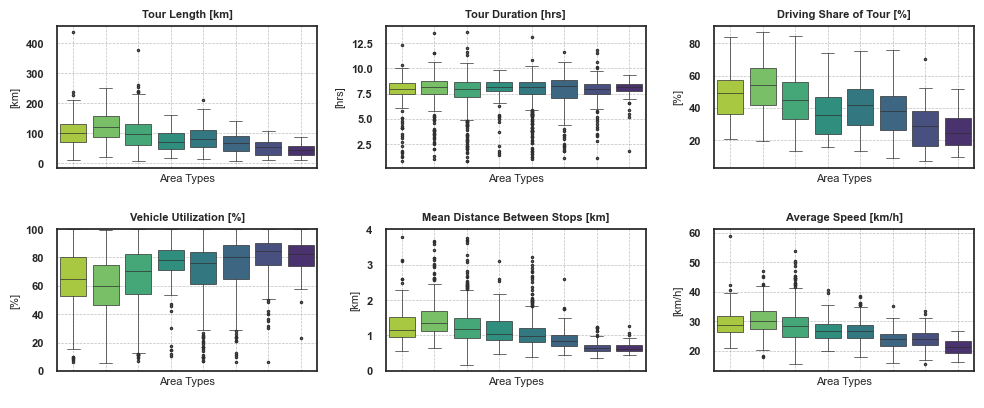

In [14]:
# ── Figure 6a: Boxplot Grid — Tour KPI Distributions by Area Type ───────

# Data preparation: map area type descriptions & select KPI columns
bc_valid['main_area_type_desc'] = bc_valid['main_area_type'].astype(str).map(category_dict)

kpi_columns = ['Tour Length (km)', 'Tour Duration (hrs)', 'Driving Share of Tour (%)',
               'Vehicle Utilization (%)', 'Mean Distance Between Stops (km)',
               'Average Speed (km/h)', 'main_area_type_desc']

bc_selected = bc_valid[kpi_columns].copy()

# Scale utilization to 0–100 if stored as fraction
if bc_selected['Vehicle Utilization (%)'].max() <= 1.5:
    bc_selected['Vehicle Utilization (%)'] = bc_selected['Vehicle Utilization (%)'] * 100.0

order = list(reversed(palette_dict.keys()))
x_axis_col = 'main_area_type_desc'

plot_titles = ['Tour Length [km]', 'Tour Duration [hrs]',
               'Driving Share of Tour [%]', 'Vehicle Utilization [%]',
               'Mean Distance Between Stops [km]', 'Average Speed [km/h]']
y_axes_cols = ['Tour Length (km)', 'Tour Duration (hrs)',
               'Driving Share of Tour (%)', 'Vehicle Utilization (%)',
               'Mean Distance Between Stops (km)', 'Average Speed (km/h)']
y_axis_labels = ['[km]', '[hrs]', '[%]', '[%]', '[km]', '[km/h]']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 4.25))

for i, ax in enumerate(axes.flat):
    sns.boxplot(
        data=bc_selected, y=y_axes_cols[i], x=x_axis_col, ax=ax,
        palette=palette_dict, order=order, linewidth=0.5,
        flierprops={"marker": ".", "markersize": 3}
    )
    ax.set_title(plot_titles[i], fontsize=8, weight='bold')
    ax.set_xlabel('Area Types\n', fontsize=8)
    ax.set_ylabel(y_axis_labels[i], fontsize=8)
    ax.tick_params(axis='x', labelbottom=False)
    ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    ax.legend().set_visible(False)

    if y_axes_cols[i] == 'Mean Distance Between Stops (km)':
        ax.set_ylim(0, 4)
    elif y_axes_cols[i] == 'Vehicle Utilization (%)':
        ax.set_ylim(0, 100)

# Shared legend
custom_legend_labels = list(category_color_dict.keys())[::-1]
handles = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=v,
               markeredgewidth=0.5, markeredgecolor='black', markersize=8)
    for v in reversed(palette_dict.values())
]
# fig.legend(handles, custom_legend_labels, loc='upper center', ncol=4,
#            bbox_to_anchor=(0.5, 0.06), fontsize=9, prop={'weight': 'normal', 'size': 9})

plt.tight_layout(rect=[0, 0.001, 1, 0.9999])
plt.savefig('figures-and-tables/jotg_figure6a_boxplot_distributions.pdf', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\1778277286.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\1778277286.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\1778277286.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\1778277286.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label star

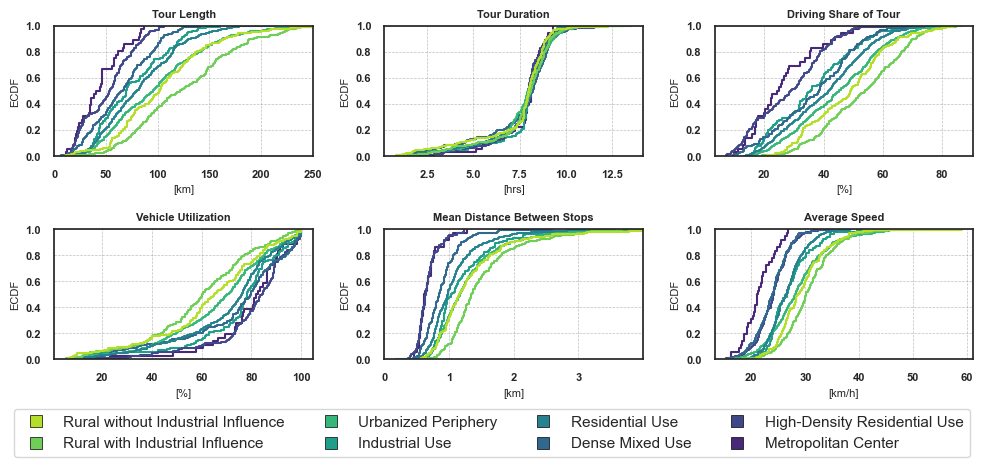

In [15]:
# ── Figure 6b: ECDF Grid — Tour KPI Distributions by Area Type ──────────

plot_titles_ecdf = ['Tour Length', 'Tour Duration',
                    'Driving Share of Tour', 'Vehicle Utilization',
                    'Mean Distance Between Stops', 'Average Speed']
x_axes_cols = ['Tour Length (km)', 'Tour Duration (hrs)',
               'Driving Share of Tour (%)', 'Vehicle Utilization (%)',
               'Mean Distance Between Stops (km)', 'Average Speed (km/h)']
x_axis_labels = ['[km]', '[hrs]', '[%]', '[%]', '[km]', '[km/h]']

hue_col_name = 'main_area_type_desc'

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 4.25))

for i, ax in enumerate(axes.flat):
    sns.ecdfplot(data=bc_selected, x=x_axes_cols[i], ax=ax,
                 hue=hue_col_name, palette=category_color_dict)
    ax.set_title(plot_titles_ecdf[i], fontsize=8, weight='bold')
    ax.set_xlabel(x_axis_labels[i], fontsize=8)
    ax.set_ylabel('ECDF', fontsize=8)
    ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    ax.legend().set_visible(False)

    if plot_titles_ecdf[i] == 'Tour Length':
        ax.set_xticks(range(0, 251, 50))
        ax.set_xlim(0, 250)
    elif plot_titles_ecdf[i] == 'Mean Distance Between Stops':
        ax.set_xticks(range(0, 4, 1))
        ax.set_xlim(0, 4)

# Shared legend (reuse from 6a)
handles = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=v,
               markeredgewidth=0.5, markeredgecolor='black', markersize=8)
    for v in reversed(palette_dict.values())
]
fig.legend(handles, custom_legend_labels, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, 0.035), fontsize=9, prop={'weight': 'normal'})

plt.tight_layout(rect=[0, 0.001, 1, 0.9999])
plt.savefig('figures-and-tables/jotg_figure6b_ecdf_distributions.pdf', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\2618692957.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\2618692957.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\2618692957.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\2618692957.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an 

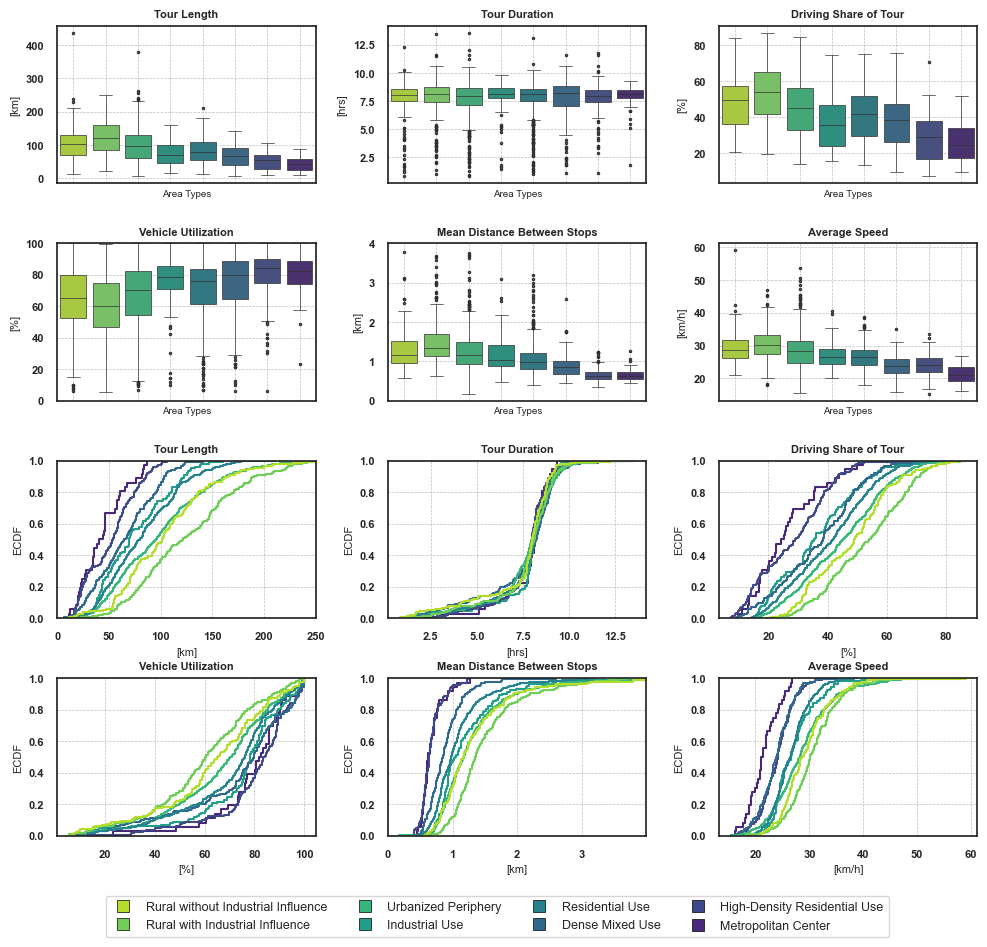

In [16]:
# ── Figure 6 Combined: Boxplot + ECDF Grid ──────────────────────────────

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 9))

# --- Top 2 rows: Boxplots (Figure 6a) ---
plot_titles = ['Tour Length', 'Tour Duration',
               'Driving Share of Tour', 'Vehicle Utilization',
               'Mean Distance Between Stops', 'Average Speed']
y_axes_cols = ['Tour Length (km)', 'Tour Duration (hrs)',
               'Driving Share of Tour (%)', 'Vehicle Utilization (%)',
               'Mean Distance Between Stops (km)', 'Average Speed (km/h)']
y_axis_labels = ['[km]', '[hrs]', '[%]', '[%]', '[km]', '[km/h]']

order = list(reversed(palette_dict.keys()))
x_axis_col = 'main_area_type_desc'

for i, ax in enumerate(axes[:2].flat):
    sns.boxplot(
        data=bc_selected, y=y_axes_cols[i], x=x_axis_col, ax=ax,
        palette=palette_dict, order=order, linewidth=0.5,
        flierprops={"marker": ".", "markersize": 3}
    )
    ax.set_title(plot_titles[i], fontsize=8, weight='bold')
    ax.set_xlabel('Area Types', fontsize=7)
    ax.set_ylabel(y_axis_labels[i], fontsize=8)
    ax.tick_params(axis='x', labelbottom=False)
    ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    ax.legend().set_visible(False)

    if y_axes_cols[i] == 'Mean Distance Between Stops (km)':
        ax.set_ylim(0, 4)
    elif y_axes_cols[i] == 'Vehicle Utilization (%)':
        ax.set_ylim(0, 100)

# --- Bottom 2 rows: ECDFs (Figure 6b) ---
plot_titles_ecdf = ['Tour Length', 'Tour Duration',
                    'Driving Share of Tour', 'Vehicle Utilization',
                    'Mean Distance Between Stops', 'Average Speed']
x_axes_cols = ['Tour Length (km)', 'Tour Duration (hrs)',
               'Driving Share of Tour (%)', 'Vehicle Utilization (%)',
               'Mean Distance Between Stops (km)', 'Average Speed (km/h)']
x_axis_labels = ['[km]', '[hrs]', '[%]', '[%]', '[km]', '[km/h]']
hue_col_name = 'main_area_type_desc'

for i, ax in enumerate(axes[2:].flat):
    sns.ecdfplot(data=bc_selected, x=x_axes_cols[i], ax=ax,
                 hue=hue_col_name, palette=category_color_dict)
    ax.set_title(plot_titles_ecdf[i], fontsize=8, weight='bold')
    ax.set_xlabel(x_axis_labels[i], fontsize=8)
    ax.set_ylabel('ECDF', fontsize=8)
    ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    ax.legend().set_visible(False)

    if plot_titles_ecdf[i] == 'Tour Length':
        ax.set_xticks(range(0, 251, 50))
        ax.set_xlim(0, 250)
    elif plot_titles_ecdf[i] == 'Mean Distance Between Stops':
        ax.set_xticks(range(0, 4, 1))
        ax.set_xlim(0, 4)

# Shared legend at bottom
custom_legend_labels = list(category_color_dict.keys())[::-1]
handles = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=v,
               markeredgewidth=0.5, markeredgecolor='black', markersize=8)
    for v in reversed(palette_dict.values())
]
fig.legend(handles, custom_legend_labels, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, 0.01), fontsize=9, prop={'weight': 'normal', 'size': 9})

plt.subplots_adjust(left=0.06, right=0.98, top=0.97, bottom=0.07, hspace=0.38, wspace=0.28)
plt.savefig('figures-and-tables/jotg_figure6_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 7. Delivery Costs *(→ Figure 7, Figure 8)*

### Figure 7 — Parcel Delivery Density vs. Average Delivery Cost

Scatter plot of parcel delivery density against average delivery cost per parcel, aggregated by detailed area type. A power-law fit captures the systematic density–cost relationship across spatial contexts. Individual LSP-level data points are also shown to illustrate cost dispersion within area types.


In [17]:
# ── Compute avg_stop_density_parcels_per_km2 ─────────────────────────────
# Replicates the matsim notebook methodology: for each service stop, compute
# local parcel density inside a 1 km buffer, then average per tour.
# Uses MATSim network link midpoints as fallback for services without coords.
import matsim

STOP_BUFFER_M = 1000
TARGET_CRS    = 25832

# Load MATSim network for link-geometry fallback
network = matsim.read_network('../input/car_network_encfix.xml.gz').as_geo().set_crs('epsg:25832')
link_geometry = network[['link_id', 'geometry']].set_index('link_id').to_dict()['geometry']

COORD_PATTERN = re.compile(r"\(\s*([-\d\.eE]+)\s*;\s*([-\d\.eE]+)\s*\)")

def parse_coord(coord_value):
    """Parse various coord formats into a shapely Point."""
    if coord_value is None:
        return None
    if isinstance(coord_value, Point):
        return coord_value
    if isinstance(coord_value, (tuple, list)) and len(coord_value) == 2:
        try:
            return Point(float(coord_value[0]), float(coord_value[1]))
        except (TypeError, ValueError):
            return None
    if isinstance(coord_value, str):
        m = COORD_PATTERN.match(coord_value.strip())
        if m:
            return Point(float(m.group(1)), float(m.group(2)))
    return None

def link_midpoint(link_id):
    """Midpoint of a network link (fallback for services without coord)."""
    geom = link_geometry.get(str(link_id)) or link_geometry.get(link_id)
    if geom is None or geom.is_empty:
        return None
    if geom.geom_type == "LineString":
        return geom.interpolate(0.5, normalized=True)
    if geom.geom_type == "MultiLineString":
        merged = linemerge(geom)
        return (merged.interpolate(0.5, normalized=True)
                if not merged.is_empty else geom.representative_point())
    return geom.representative_point()

def service_point(service):
    """Service location: coord attribute → network link midpoint fallback."""
    coord = (service.extra.get("coord")
             if hasattr(service, 'extra') and isinstance(service.extra, dict) else None)
    geom = parse_coord(coord)
    if geom is not None and not geom.is_empty:
        return geom
    link_id = getattr(service, 'link', None)
    return link_midpoint(link_id) if link_id is not None else None

def service_parcel_count(service):
    """B2B + B2C parcel count for a single service stop."""
    _f = lambda v: float(v) if v is not None else 0.0
    if hasattr(service, 'extra') and isinstance(service.extra, dict):
        b2b, b2c = service.extra.get("b2b", 0), service.extra.get("b2c", 0)
    else:
        b2b, b2c = 0, 0
    demand = _f(b2b) + _f(b2c)
    return demand if demand > 0 else _f(getattr(service, 'capacity_demand', 0))

# Build stop GeoDataFrame from all tours
stop_records = []
for vehicle_id, service_list in bc[["vehicle_id", "services"]].itertuples(index=False):
    if not isinstance(service_list, (list, tuple)):
        continue
    for svc in service_list:
        geom = service_point(svc)
        if geom is None or geom.is_empty:
            continue
        stop_records.append({
            "vehicle_id": vehicle_id,
            "parcels": service_parcel_count(svc),
            "geometry": geom,
        })

stop_gdf    = gpd.GeoDataFrame(stop_records, geometry="geometry", crs=f"EPSG:{TARGET_CRS}")
stop_sindex = stop_gdf.sindex

# Local density: total parcels within 1 km buffer / buffer area
def local_density(point):
    buf = point.buffer(STOP_BUFFER_M)
    idx = list(stop_sindex.intersection(buf.bounds))
    if not idx:
        return 0.0
    within = stop_gdf.iloc[idx]
    within = within[within.intersects(buf)]
    return within["parcels"].sum() / (buf.area / 1e6)

stop_gdf["density"] = stop_gdf["geometry"].apply(local_density)

# Average density per tour → merge into bc
avg_density = (
    stop_gdf.groupby("vehicle_id")["density"]
    .mean()
    .rename("avg_stop_density_parcels_per_km2")
)

if "avg_stop_density_parcels_per_km2" in bc.columns:
    bc = bc.drop(columns=["avg_stop_density_parcels_per_km2"])
bc = bc.merge(avg_density, on="vehicle_id", how="left")
bc["avg_stop_density_parcels_per_km2"] = bc["avg_stop_density_parcels_per_km2"].fillna(0)

if "Cost per Parcel [€/parcel]" not in bc.columns:
    bc["Cost per Parcel [€/parcel]"] = bc["vehicle_cost"] / bc["deliveries"]

# Update bc_valid with new columns
bc_valid = bc[bc['Vehicle Utilization (%)'] > 0.05].copy()

print(f"Stops resolved: {len(stop_records):,} | "
      f"Tours: {bc_valid.shape[0]:,} | "
      f"Density mean={bc_valid['avg_stop_density_parcels_per_km2'].mean():.0f}, "
      f"max={bc_valid['avg_stop_density_parcels_per_km2'].max():.0f} parcels/km²")

Stops resolved: 92,833 | Tours: 1,715 | Density mean=595, max=2897 parcels/km²


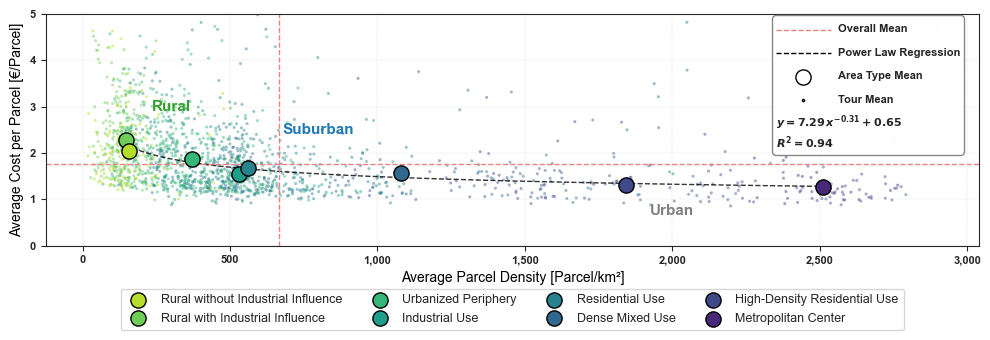

In [166]:
# ── Figure 7: Parcel Density vs. Average Delivery Cost ───────────────────

LABEL_POSITIONS = {
    "Rural":    {"x": 300,  "y": 3.0},
    "Suburban":  {"x": 800,  "y": 2.5},
    "Urban":     {"x": 2000, "y": 0.75},
}

# --- Data preparation ---
plot_df = (
    bc_valid[["main_area_description", "cost_per_parcel", "avg_stop_density_parcels_per_km2", "deliveries", "vehicle_cost"]]
    .copy()
    .rename(columns={
        "main_area_description": "area_type",
        "cost_per_parcel": "cost_per_parcel",
        "avg_stop_density_parcels_per_km2": "parcels_per_km2",
    })
)
plot_df = plot_df.dropna(subset=["area_type", "cost_per_parcel", "parcels_per_km2", "deliveries", "vehicle_cost"])
plot_df = plot_df[np.isfinite(plot_df["parcels_per_km2"])]
plot_df["area_type_group"] = plot_df["area_type"].map(AREA_GROUP_LOOKUP)
plot_df = plot_df.dropna(subset=["area_type_group"])
plot_df["bg_color"] = plot_df["area_type"].map(category_color_dict).fillna("#9e9e9e")

# Parcel-weighted averages (sum/sum) to match Figure 9 / Table 4 / Appendix D
def _pw_area_means(df):
    g = df.groupby(["area_type", "area_type_group"])
    out = g.apply(lambda d: pd.Series({
        "avg_density": (d["parcels_per_km2"] * d["deliveries"]).sum() / d["deliveries"].sum(),
        "avg_cost":    d["vehicle_cost"].sum() / d["deliveries"].sum(),
        "tour_count": len(d),
    }), include_groups=False).reset_index()
    return out
area_means = _pw_area_means(plot_df)

# --- Helper functions ---
def powerlaw_func(x, a, b, c):
    return a * np.power(x, b) + c

def add_group_labels(ax, df, group_colors, positions, y_offset=0.35):
    for grp, col in group_colors.items():
        pts = df[df["area_type_group"] == grp]
        if pts.empty:
            continue
        pos = positions.get(grp, {"x": None, "y": None})
        if pos["x"] is not None and pos["y"] is not None:
            tx, ty = pos["x"], pos["y"]
        else:
            tx = 0.5 * (pts["parcels_per_km2"].min() + pts["parcels_per_km2"].max())
            ty = pts["cost_per_parcel"].max() + y_offset
        ax.text(tx, ty, grp, ha="center", va="center",
                fontsize=11, fontweight="bold", color=col, zorder=6)

def fit_powerlaw_on_area_means(df):
    X = df["avg_density"].to_numpy(float)
    Y = df["avg_cost"].to_numpy(float)
    mask = np.isfinite(X) & np.isfinite(Y) & (X > 0)
    Xm, Ym = X[mask], Y[mask]
    if len(Xm) < 3:
        return np.full(3, np.nan), np.nan, None, None
    popt, _ = curve_fit(powerlaw_func, Xm, Ym,
                        p0=[Ym.max() - Ym.min(), -0.5, Ym.min()], maxfev=20_000)
    y_pred = powerlaw_func(Xm, *popt)
    ss_res, ss_tot = np.sum((Ym - y_pred)**2), np.sum((Ym - Ym.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot else np.nan
    x_fit = np.linspace(Xm.min(), Xm.max(), 200)
    return popt, r2, x_fit, powerlaw_func(x_fit, *popt)

def add_info_box(ax, popt, r2):
    tp = dict(size=8)
    reg = (r"$y = {:.2f} \, x^{{{:.2f}}} + {:.2f}$".format(*popt)
           if np.all(np.isfinite(popt)) else "")
    r2s = r"$R^2 = {:.2f}$".format(r2) if np.isfinite(r2) else ""

    def _icon(artist):
        da = DrawingArea(40, 15, 0, 0); da.add_artist(artist); return da
    def _row(icon, text):
        return HPacker(children=[icon, TextArea(text, textprops=tp)],
                       align="center", pad=0, sep=5)

    rows = [
        _row(_icon(Line2D([0, 40], [7, 7], color="lightcoral", ls="--", lw=1)),
             "Overall Mean"),
        _row(_icon(Line2D([0, 40], [7, 7], color="black", ls="--", lw=1)),
             "Power Law Regression"),
        _row(_icon(Line2D([20], [7], marker="o", ms=np.sqrt(120),
                          mfc="white", mec="black", ls="None")),
             "Area Type Mean"),
        _row(_icon(Line2D([20], [7], marker=".", ms=np.sqrt(10),
                          mfc="white", mec="black", ls="None")),
             "Tour Mean"),
    ]
    if reg:  rows.append(TextArea(reg, textprops=tp))
    if r2s:  rows.append(TextArea(r2s, textprops=tp))

    ab = AnnotationBbox(
        VPacker(children=rows, align="left", pad=0, sep=2),
        (0.98, 0.98), xycoords="axes fraction", box_alignment=(1, 1),
        bboxprops=dict(boxstyle="round", fc="white", alpha=0.95, ec="gray"),
        frameon=True)
    ax.add_artist(ab)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 3.75))

ax.scatter(plot_df["parcels_per_km2"], plot_df["cost_per_parcel"],
           c=plot_df["bg_color"], s=5, alpha=0.45, linewidths=0, zorder=1)

for _, row in area_means.iterrows():
    ax.scatter(row["avg_density"], row["avg_cost"],
               color=category_color_dict.get(row["area_type"], "#7f7f7f"),
               edgecolor="k", s=120, marker="o", label=row["area_type"], zorder=4)

add_group_labels(ax, plot_df, agg_colors, LABEL_POSITIONS, y_offset=0.35)

popt_pl, r2_pl, x_fit, y_fit = fit_powerlaw_on_area_means(area_means)
if x_fit is not None:
    ax.plot(x_fit, y_fit, color="black", ls="--", lw=1, alpha=0.8)

# Parcel-weighted overall means (consistent with Figure 9 / Table 4 / Appendix D)
mp = float((plot_df["parcels_per_km2"] * plot_df["deliveries"]).sum() / plot_df["deliveries"].sum())
md = float(plot_df["vehicle_cost"].sum() / plot_df["deliveries"].sum())
ax.axvline(mp, color="lightcoral", ls="--", lw=1)
ax.axhline(md, color="lightcoral", ls="--", lw=1)

ax.set_xlabel("Average Parcel Density [Parcel/km²]", fontsize=10)
ax.set_ylabel("Average Cost per Parcel [€/Parcel]", fontsize=10)
ax.grid(True, linestyle=":", linewidth=0.25)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))

handles, labels = ax.get_legend_handles_labels()
lbl2h = {l: h for h, l in zip(handles, labels)}
ordered = [l for l in reversed(category_color_dict) if l in lbl2h]
ax.legend([lbl2h[l] for l in ordered], ordered,
          loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4, frameon=True,
          fontsize=9, prop={'weight': 'normal', 'size': 9})

add_info_box(ax, popt_pl, r2_pl)
ax.set_ylim(0, 5)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("figures-and-tables/jotg_figure7_density_cost_scatter.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

### Figure 8 — Smoothed Surface of Average Parcel Delivery Cost

Spatial distribution of average delivery costs per parcel across the study area, derived from hexagonal aggregation of service points (10 km resolution) followed by interpolation. The base plane indicates the eight area types.



In [19]:
# ── Figure 8 — Data Preparation ──────────────────────────────────────────
# Build the interpolated cost surface and configure hub/basemap data.
# Requires: bc_valid, stop_gdf (from density cell), regionclusters.
from scipy.interpolate import griddata
from shapely.ops import unary_union
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib import patheffects as pe

# ── 1. regionclusters_split (single-part geometries for the base plane) ──
regionclusters_split = regionclusters.explode(index_parts=False).reset_index(drop=True)
if "id" not in regionclusters_split.columns:
    regionclusters_split = regionclusters_split.reset_index().rename(columns={"index": "id"})
if regionclusters_split.crs.to_epsg() != 25832:
    regionclusters_split = regionclusters_split.to_crs(25832)

# ── 2. Service points with per-tour cost ─────────────────────────────────
cost_by_tour = bc_valid.set_index("vehicle_id")[["Cost per Parcel [€/parcel]"]]
stop_with_cost = stop_gdf.merge(cost_by_tour, on="vehicle_id", how="inner")

gdf_points = gpd.GeoDataFrame(
    {"cost": stop_with_cost["Cost per Parcel [€/parcel]"].values},
    geometry=stop_with_cost.geometry.tolist(),
    crs=regionclusters_split.crs,
)

# Spatial join: assign area type to each stop
joined = gpd.sjoin(
    gdf_points,
    regionclusters_split[["area_type", "geometry"]],
    how="left",
    predicate="within",
)

# ── 3. Hexagonal aggregation (10 km resolution) ──────────────────────────
hex_size = 10_000
x_arr = joined.geometry.x.values
y_arr = joined.geometry.y.values
gridsize_hex = max(1, int((x_arr.max() - x_arr.min()) / hex_size))

fig_tmp, ax_tmp = plt.subplots()
hb = ax_tmp.hexbin(x_arr, y_arr, gridsize=gridsize_hex, mincnt=1)
plt.close(fig_tmp)

verts = hb.get_offsets()
hex_radius = np.ptp(hb.get_paths()[0].vertices[:, 0]) / 2

hex_heights = []
for hxv, hyv in verts:
    mask = (np.abs(x_arr - hxv) < hex_radius) & (np.abs(y_arr - hyv) < hex_radius)
    if not np.any(mask):
        continue
    avg_cost = joined.loc[mask, "cost"].mean()
    hex_heights.append((hxv, hyv, avg_cost))

# ── 4. Cubic interpolation grid ──────────────────────────────────────────
hx = np.array([h[0] for h in hex_heights])
hy = np.array([h[1] for h in hex_heights])
costs = np.array([h[2] for h in hex_heights])

grid_x, grid_y = np.mgrid[hx.min() : hx.max() : 200j, hy.min() : hy.max() : 200j]
grid_z = griddata((hx, hy), costs, (grid_x, grid_y), method="cubic")

# ── 5. Hub positions & provider colours ───────────────────────────────────
hubs = pd.read_csv("../KEP-hubs_v3.csv", sep=";")

prov_colors = {
    "dhl":    "#FFCC00",
    "dp/dhl": "#FFCC00",
    "dpd":    "#E3000B",
    "gls":    "#1C3F95",
    "ups":    "#392312",
    "hermes": "#00A0E1",
    "amazon": "#00A8E1",
    "fedex":  "#4D148C",
}

# ── 6. Helper functions for the 3-D surface plot ─────────────────────────

def _rotate_xy(xa, ya, cx, cy, deg):
    """Rotate arrays (xa, ya) around (cx, cy) by *deg* degrees."""
    xa, ya = np.asarray(xa, float), np.asarray(ya, float)
    th = np.deg2rad(float(deg))
    ct, st = np.cos(th), np.sin(th)
    dx, dy = xa - cx, ya - cy
    return cx + ct * dx - st * dy, cy + st * dx + ct * dy


def _transform_xy(xa, ya, cx, cy, rotate_deg=0.0,
                   swap_xy=False, mirror_x=False, mirror_y=False):
    """Apply swap, rotation, and optional mirroring."""
    xa, ya = np.asarray(xa, float), np.asarray(ya, float)
    if swap_xy:
        xa, ya = ya, xa
    if rotate_deg:
        xa, ya = _rotate_xy(xa, ya, cx, cy, rotate_deg)
    if mirror_x:
        xa = 2.0 * cx - xa
    if mirror_y:
        ya = 2.0 * cy - ya
    return xa, ya


def _draw_polygon3d(ax3d, geom, z=0.01, facecolor=(1, 1, 1, 0.8),
                    edgecolor=(0, 0, 0, 1), alpha=1.0, lw=0.8,
                    rotate_deg=0.0, origin=None,
                    swap_xy=False, mirror_x=False, mirror_y=False,
                    zsort_mode="max", sort_zpos=None):
    """Draw a single Polygon / MultiPolygon at height *z*."""
    if geom is None or geom.is_empty:
        return
    cx, cy = (float(origin[0]), float(origin[1])) if origin else \
             (float(geom.centroid.x), float(geom.centroid.y))
    parts = [geom] if geom.geom_type == "Polygon" else list(getattr(geom, "geoms", []))
    for poly in parts:
        ex_x, ex_y = poly.exterior.coords.xy
        ex_x, ex_y = _transform_xy(ex_x, ex_y, cx, cy, rotate_deg, swap_xy, mirror_x, mirror_y)
        verts_ex = [(float(x), float(y), float(z)) for x, y in zip(ex_x, ex_y)]
        coll = Poly3DCollection([verts_ex], facecolors=facecolor,
                                edgecolors=edgecolor, linewidths=lw, alpha=alpha)
        coll.set_clip_on(False)
        coll.set_zsort(zsort_mode)
        if sort_zpos is not None:
            coll.set_sort_zpos(float(sort_zpos))
        ax3d.add_collection3d(coll)
        for interior in poly.interiors:
            in_x, in_y = interior.coords.xy
            in_x, in_y = _transform_xy(in_x, in_y, cx, cy, rotate_deg, swap_xy, mirror_x, mirror_y)
            verts_in = [(float(x), float(y), float(z)) for x, y in zip(in_x, in_y)]
            hole = Poly3DCollection([verts_in], facecolors=(1, 1, 1, 0),
                                    edgecolors=edgecolor, linewidths=max(0.5 * lw, 0.3), alpha=1)
            hole.set_clip_on(False)
            hole.set_zsort(zsort_mode)
            if sort_zpos is not None:
                hole.set_sort_zpos(float(sort_zpos))
            ax3d.add_collection3d(hole)


def add_polygons_on_z0(ax3d, gdf, color_map,
                       edgecolor=(0.4, 0.4, 0.4, 1.0),
                       default_color=(0.85, 0.85, 0.85, 1.0),
                       alpha=1.0, draw_legend=True, z0=0.0,
                       swap_xy=False, rotate_deg=0.0,
                       mirror_x=False, mirror_y=False,
                       force_back=False):
    """Draw all polygons from *gdf* on z = z0 with area-type colouring."""
    area_col = None
    for cand in ("area_type", "main_area_type_name", "raumtyp", "main_area_description"):
        if cand in gdf.columns:
            area_col = cand
            break
    minx, miny, maxx, maxy = gdf.total_bounds
    origin = (0.5 * (float(minx) + float(maxx)), 0.5 * (float(miny) + float(maxy)))
    back_bias = -1e6 if force_back else None
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        at = row.get(area_col, None) if area_col else None
        fc = color_map.get(at, default_color)
        _draw_polygon3d(ax3d, geom, z=z0, facecolor=fc, edgecolor=edgecolor,
                        alpha=alpha, lw=0.35, rotate_deg=rotate_deg, origin=origin,
                        swap_xy=swap_xy, mirror_x=mirror_x, mirror_y=mirror_y,
                        zsort_mode="min" if force_back else "max", sort_zpos=back_bias)


def make_hub_union(hubs_df, radius_m=600.0, grow=1.01, eps=2.0, circle_sides=64):
    """Buffered union of all hub positions (with safety margin)."""
    R = float(radius_m) * float(grow)
    disks = []
    for _, r in hubs_df.iterrows():
        disks.append(Point(float(r["X"]), float(r["Y"])).buffer(R, quad_segs=circle_sides))
    return unary_union(disks).buffer(float(eps))


def punch_holes_under_hubs(gdf, hub_union):
    """Subtract hub disks from base-plane polygons."""
    gdf = gdf.copy()
    gdf["geometry"] = gdf.geometry.buffer(0)
    rows = []
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        new_geom = geom.difference(hub_union) if geom.intersects(hub_union) else geom
        if new_geom is None or new_geom.is_empty:
            continue
        new_row = row.copy()
        new_row.geometry = new_geom
        rows.append(new_row)
    return gpd.GeoDataFrame(rows, crs=gdf.crs)


def rotate_grid(xg, yg, cx, cy, deg):
    """Rotate interpolation grid 90° around its centre."""
    th = np.deg2rad(deg)
    ct, st = np.cos(th), np.sin(th)
    dx, dy = xg - cx, yg - cy
    return cx + ct * dx - st * dy, cy + st * dx + ct * dy


def add_hub_flags(ax3d, hubs_df, prov_colors, origin,
                  rotate_deg=0.0, swap_xy=False, mirror_x=False, mirror_y=False,
                  z0=0.0, eps=1e-3, pole_h_frac=0.18,
                  flag_w=800.0, flag_h=450.0,
                  edgecolor=(0, 0, 0, 1), pole_lw=1.2, flag_lw=0.8,
                  label_key="Typ", label_fs=8, label_dz=0.02,
                  grid=None):
    """Draw labelled flag poles at hub locations."""
    cx, cy = origin
    zmin, zmax = ax3d.get_zlim()
    zspan = max(zmax - zmin, 1.0)
    H = pole_h_frac * zspan

    def base_z_at(xr, yr):
        if grid is None:
            return z0 + eps
        Xr, Yr, Z = grid
        i = np.argmin(np.abs(Xr[:, 0] - xr))
        j = np.argmin(np.abs(Yr[0, :] - yr))
        z_here = float(Z[i, j]) if np.isfinite(Z[i, j]) else z0
        return max(z0 + eps, z_here + 0.03 * zspan)

    def normalize_provider(s):
        s = str(s).strip().lower()
        if s in ("dp dhl", "dpdhl", "deutsche post", "deutsche post/dhl"):
            return "dp/dhl"
        return s

    tmp = hubs_df.copy()
    tmp["prov_norm"] = tmp["Anbieter"].map(normalize_provider)
    priority_map = {"ups": 5, "hermes": 6, "dp/dhl": 4, "dhl": 3,
                    "fedex": 7, "gls": 0, "dpd": 1}
    tmp["priority"] = tmp["prov_norm"].map(priority_map).fillna(10).astype(int)
    tmp["_order_idx"] = np.arange(len(tmp))
    hubs_sorted = tmp.sort_values(["priority", "_order_idx"], kind="mergesort")

    LEFT_LABEL_PROVIDERS = {"dpd", "fedex"}

    for _, r in hubs_sorted.iterrows():
        x, y = float(r["X"]), float(r["Y"])
        lab = str(r.get("Anbieter", "")).strip().lower()
        if lab in ("dp/dhl",):
            lab = "dhl"
        color = prov_colors.get(lab, "#FFCC00")
        xt, yt = _transform_xy(
            np.array([x]), np.array([y]),
            cx, cy, rotate_deg, swap_xy, mirror_x, mirror_y,
        )
        xt, yt = float(xt[0]), float(yt[0])
        z_base = base_z_at(xt, yt)
        z_top = z_base + H

        line = ax3d.plot(
            [xt, xt], [yt, yt], [z_base, z_top],
            color=color, linewidth=pole_lw * 3,
            solid_capstyle="round", zorder=1000, alpha=1,
        )[0]
        line.set_zorder(116)
        line.set_rasterized(True)
        line.set_path_effects([pe.Stroke(linewidth=pole_lw * 3.15, foreground="k"), pe.Normal()])

        x_span = ax3d.get_xlim()[1] - ax3d.get_xlim()[0]
        dx = 0.01 * x_span
        ha = "left"
        x_text = xt + dx
        if lab in LEFT_LABEL_PROVIDERS:
            x_text = xt - dx
            ha = "right"

        ax3d.text(
            x_text, yt, z_top, lab.strip().upper(),
            ha=ha, va="center", fontsize=8, color="black",
            zorder=116, clip_on=False,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9),
        )

print(f"Hex cells: {len(hex_heights)} | Grid: {grid_x.shape} | Hubs: {len(hubs)}")
print("Data preparation for Figure 8 complete.")

Hex cells: 32 | Grid: (200, 200) | Hubs: 22
Data preparation for Figure 8 complete.


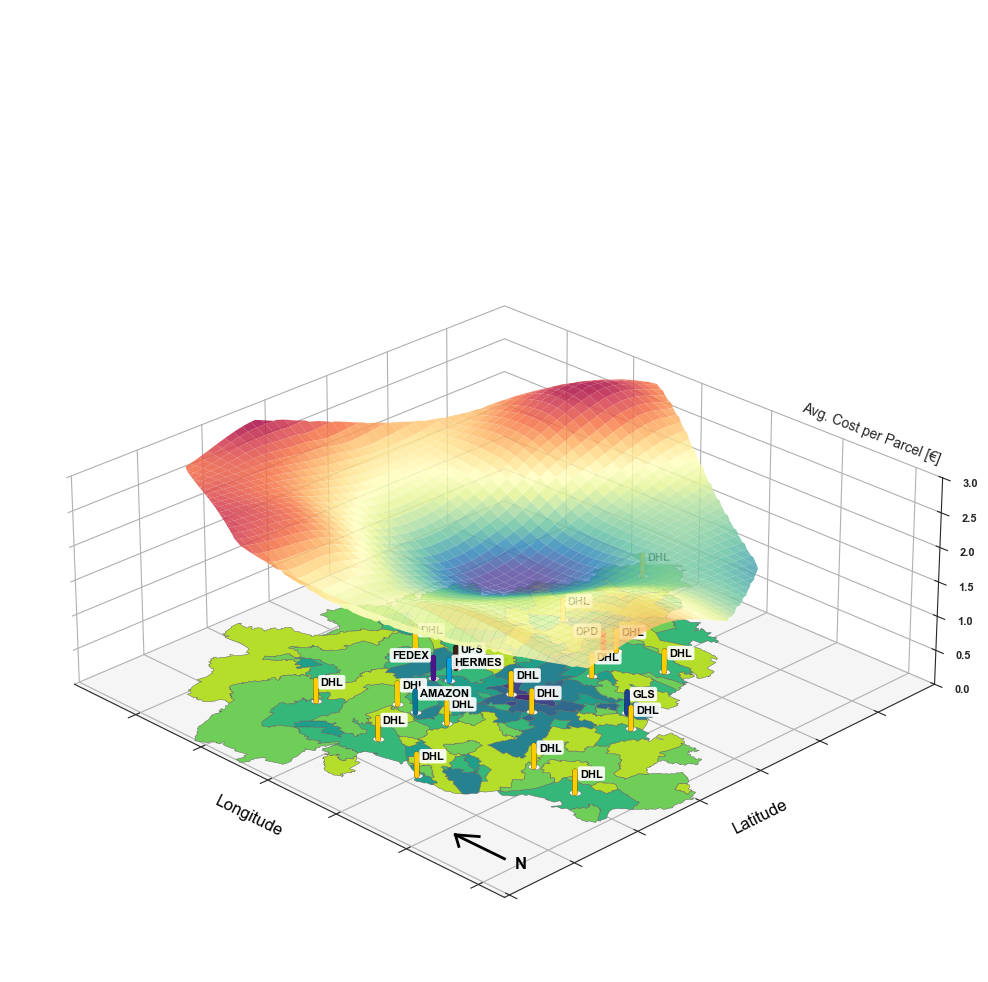

In [80]:

# --- Temporarily disable seaborn for correct 3-D z-ordering ---------------
import matplotlib as mpl

_rc_backup = mpl.rcParams.copy()
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    # Font face & weight — matches sns.set_theme(style='white') + mpl.rc('font', weight='bold')
    "font.family":      ["sans-serif"],
    "font.sans-serif":  ["Arial", "DejaVu Sans", "Liberation Sans",
                         "Bitstream Vera Sans", "sans-serif"],
    "font.weight":      "bold",
    "font.size":        12.0,
    "axes.labelsize":   12.0,
    "axes.labelweight": "normal",
    "axes.titlesize":   12.0,
    "axes.titleweight": "normal",
    "xtick.labelsize":  8.0,
    "ytick.labelsize":  8.0,
    # Colors — seaborn 'white' uses dark-gray (.15), not pure black
    "text.color":       ".15",
    "xtick.color":      ".15",
    "ytick.color":      ".15",
    "axes.edgecolor":   ".15",
    "axes.facecolor":   "white",
    "axes.grid":        False,
})

# Mask invalid interpolation values
grid_z_masked = np.ma.masked_invalid(grid_z)
finite_costs  = costs[np.isfinite(costs)]
vmin, vmax    = float(np.nanmin(finite_costs)), float(np.nanmax(finite_costs))

fig = plt.figure(figsize=(10, 10))
ax  = fig.add_subplot(111, projection="3d")

# Hub holes in basemap
hub_radius = 600.0
hub_union  = make_hub_union(hubs, radius_m=hub_radius, grow=1.005, eps=0)

base_cols = (
    ["area_type", "geometry"]
    if "area_type" in regionclusters_split.columns
    else ["geometry"]
)
base_punched = punch_holes_under_hubs(regionclusters_split[base_cols], hub_union)

# Basemap polygons on z = 0
add_polygons_on_z0(
    ax, base_punched, category_color_dict,
    alpha=1, draw_legend=False, z0=0.0,
    swap_xy=False, rotate_deg=90.0, mirror_x=False, mirror_y=False,
    force_back=True,
)

# Rotate interpolation grid 90°
cx = 0.5 * (float(grid_x.min()) + float(grid_x.max()))
cy = 0.5 * (float(grid_y.min()) + float(grid_y.max()))
Xr, Yr = rotate_grid(grid_x, grid_y, cx, cy, 90.0)

# Cost surface
surf = ax.plot_surface(
    Xr, Yr, grid_z_masked,
    cmap="Spectral_r", linewidth=0, antialiased=True,
    alpha=0.85, vmin=vmin, vmax=vmax,
)
surf.set_rasterized(True)
surf.set_zorder(99999)

# Hub flags
minx, miny, maxx, maxy = regionclusters_split.total_bounds
origin = (0.5 * (minx + maxx), 0.5 * (miny + maxy))

add_hub_flags(
    ax3d=ax, hubs_df=hubs, prov_colors=prov_colors,
    origin=origin,
    rotate_deg=90.0, swap_xy=False, mirror_x=False, mirror_y=False,
    z0=-0.10, eps=1e-3,
    pole_h_frac=0.1, flag_w=800.0, flag_h=450.0,
    edgecolor=(0, 0, 0, 1),
    label_key="Typ", label_fs=8,
    grid=(Xr, Yr, grid_z_masked),
)

# Axes labels
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("")
ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False)

# Rotated z-label via text2D
ax.text2D(
    0.82, 0.56, "Avg. Cost per Parcel [€]",
    transform=ax.transAxes, rotation=-21, va="center", ha="left",
    fontsize=10, fontweight="normal",
)

# Compress z-axis visually
ax.get_proj = lambda: np.dot(Axes3D.get_proj(ax), np.diag([1, 1, 0.5, 1]))

# Transparent x/y panes
ax.xaxis.pane.set_edgecolor((1, 1, 1, 0))
ax.yaxis.pane.set_edgecolor((1, 1, 1, 0))
ax.xaxis.pane.set_facecolor((1, 1, 1, 0))
ax.yaxis.pane.set_facecolor((1, 1, 1, 0))

# North arrow
x0    = float(grid_x.min()) + 53_000
y0    = float(grid_y.min()) - 2_500
x_span = float(grid_x.max() - grid_x.min())
L      = max(1.0, 0.1 * x_span)
x_tip  = min(x0 + L, float(grid_x.max()) - 0.01 * x_span)

h, w = 0.28 * L, 0.23 * L
ax.plot([x0, x_tip],  [y0, y0],     [0, 0], color="k", linewidth=2)
ax.plot([x0, x0 + h], [y0, y0 - w], [0, 0], color="k", linewidth=2)
ax.plot([x0, x0 + h], [y0, y0 + w], [0, 0], color="k", linewidth=2)
ax.text(x_tip + 0.2 * L, y0, 0, "N", color="k", fontsize=12, ha="left", va="center")

# View and limits
ax.view_init(elev=25, azim=-45)
ax.set_xlim(float(grid_x.min() + 2_000), float(grid_x.max() - 3_000))
ax.set_ylim(float(grid_y.min() - 8_500), float(grid_y.max() + 4_200))
ax.set_zlim(0.0, float(np.nanmax(finite_costs)))

# Rasterize all collections for clean SVG export
for coll in ax.collections:
    try:
        coll.set_rasterized(True)
    except Exception:
        pass

plt.tight_layout()
fig.savefig("figures-and-tables/jotg_figure8_cost_surface.svg",
            format="svg", bbox_inches="tight", pad_inches=0.02, transparent=True)
plt.show()

# --- Restore seaborn theme ------------------------------------------------
mpl.rcParams.update(_rc_backup)


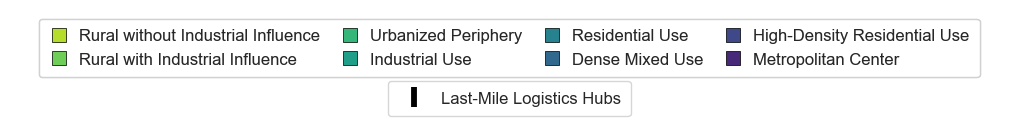

In [91]:
# ── Supplementary Legend — Area Types + Hub Marker ─────────────────────

labels_area  = list(category_color_dict.keys())[::-1]
colors_area  = [category_color_dict[k] for k in labels_area]
handles_area = [
    Line2D([0], [0], marker="s", linestyle="", color="w",
           markerfacecolor=c, markeredgewidth=0.5,
           markeredgecolor="black", markersize=10)
    for c in colors_area
]
hub_handle = Line2D([0], [0], marker="|", linestyle="",
                    color="black", markersize=14, markeredgewidth=4.2)
legend_prop = {"weight": "normal", "size": 12}

fig, ax = plt.subplots(figsize=(10, 0.8))
ax.axis("off")

leg1 = fig.legend(
    handles_area, labels_area,
    loc="upper center", ncol=4, frameon=True,
    bbox_to_anchor=(0.5, 0.98),
    prop=legend_prop,
    handlelength=1.2, handletextpad=0.6,
    columnspacing=1.2, borderpad=0.6,
 )
ax.add_artist(leg1)

fig.legend(
    [hub_handle], ["Last-Mile Logistics Hubs"],
    loc="upper center", ncol=1, frameon=True,
    bbox_to_anchor=(0.5, 0.2),
    prop=legend_prop,
    handlelength=2.0, handletextpad=0.6, borderpad=0.6
 )

fig.tight_layout(pad=0.05)
fig.savefig("figures-and-tables/jotg_figure8_cost_legend.svg",
            bbox_inches="tight", pad_inches=0.02)
plt.show()

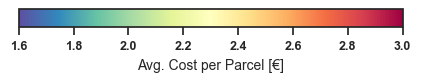

In [88]:
# ── Supplementary Colorbar — Average Delivery Cost ───────────────────

mpl.rcParams["svg.fonttype"] = "none"

norm = mpl.colors.Normalize(vmin=1.6, vmax=3.0)
sm   = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps["Spectral_r"])
sm.set_array([])

fig_cb, ax_cb = plt.subplots(figsize=(4, 0.45))

cbar = fig_cb.colorbar(sm, cax=ax_cb, orientation="horizontal")
cbar.set_label("Avg. Cost per Parcel [€]", fontsize=10, labelpad=4)
cbar.ax.tick_params(labelsize=9)

fig_cb.subplots_adjust(left=0.02, right=0.98, top=0.85, bottom=0.45)
fig_cb.savefig("figures-and-tables/jotg_figure8_colorbar_costs.svg", format="svg",
               bbox_inches="tight", pad_inches=0.02, transparent=True)
plt.show()

### Supplementary: Per-LSP Cost Surfaces

> **Note:** The following per-provider 3-D cost surface plots are **not part of the publication**. They are included here as supplementary analysis to illustrate how the spatial distribution of delivery costs naturally correlates with the position and reach of each logistics service provider's infrastructure (hub locations, depot coverage). The global colour scale is shared across all plots for direct comparability with the combined Figure 8 above.

In [23]:
# # ── Figure 8 per LSP — Individual 3-D cost surfaces ─────────────────────
# # One plot per logistics service provider, using the same global colour
# # scale (vmin / vmax) as the combined Figure 8 for comparability.

# _rc_backup = mpl.rcParams.copy()
# mpl.rcParams.update(mpl.rcParamsDefault)
# mpl.rcParams.update({
#     "font.family":      ["sans-serif"],
#     "font.sans-serif":  ["Arial", "DejaVu Sans", "Liberation Sans",
#                          "Bitstream Vera Sans", "sans-serif"],
#     "font.weight":      "bold",
#     "font.size":        12.0,
#     "axes.labelsize":   12.0,
#     "axes.labelweight": "normal",
#     "axes.titlesize":   12.0,
#     "axes.titleweight": "normal",
#     "xtick.labelsize":  8.0,
#     "ytick.labelsize":  8.0,
#     "text.color":       ".15",
#     "xtick.color":      ".15",
#     "ytick.color":      ".15",
#     "axes.edgecolor":   ".15",
#     "axes.facecolor":   "white",
#     "axes.grid":        False,
# })

# # Map vehicle_id → provider from bc_valid
# _vid_to_prov = bc_valid.set_index("vehicle_id")["provider"]

# # Add provider to the spatial-joined stops
# joined_prov = joined.copy()
# joined_prov["provider"] = joined_prov.index.map(
#     stop_with_cost["vehicle_id"].map(_vid_to_prov)
# )

# # Global colour limits (same as combined plot)
# finite_costs_global = costs[np.isfinite(costs)]
# vmin_global = float(np.nanmin(finite_costs_global))
# vmax_global = float(np.nanmax(finite_costs_global))

# # Shared geometry references (hub holes computed per-LSP inside the loop)
# hub_radius_lsp = 600.0
# base_cols_lsp = (
#     ["area_type", "geometry"]
#     if "area_type" in regionclusters_split.columns
#     else ["geometry"]
# )
# minx_lsp, miny_lsp, maxx_lsp, maxy_lsp = regionclusters_split.total_bounds
# origin_lsp = (0.5 * (minx_lsp + maxx_lsp), 0.5 * (miny_lsp + maxy_lsp))

# provider_labels = {
#     "amazon": "Amazon Logistics",
#     "dhl": "DHL",
#     "dpd": "DPD",
#     "fedex": "FedEx",
#     "gls": "GLS",
#     "hermes": "Hermes",
#     "ups": "UPS",
# }
# provider_order = ["dhl", "dpd", "gls", "hermes", "amazon", "ups", "fedex"]

# for prov in provider_order:
#     sub = joined_prov[joined_prov["provider"] == prov]
#     if len(sub) < 5:
#         print(f"  {prov}: only {len(sub)} stops — skipped")
#         continue

#     # Hex aggregation (same 10 km resolution)
#     x_p = sub.geometry.x.values
#     y_p = sub.geometry.y.values
#     gs_p = max(1, int((x_p.max() - x_p.min()) / hex_size))

#     fig_tmp2, ax_tmp2 = plt.subplots()
#     hb_p = ax_tmp2.hexbin(x_p, y_p, gridsize=gs_p, mincnt=1)
#     plt.close(fig_tmp2)

#     verts_p = hb_p.get_offsets()
#     hr_p = np.ptp(hb_p.get_paths()[0].vertices[:, 0]) / 2

#     hh_p = []
#     for hxv_p, hyv_p in verts_p:
#         m = (np.abs(x_p - hxv_p) < hr_p) & (np.abs(y_p - hyv_p) < hr_p)
#         if not np.any(m):
#             continue
#         hh_p.append((hxv_p, hyv_p, sub.loc[m, "cost"].mean()))

#     if len(hh_p) < 4:
#         print(f"  {prov}: only {len(hh_p)} hex cells — skipped (need ≥4 for cubic)")
#         continue

#     hx_p = np.array([h[0] for h in hh_p])
#     hy_p = np.array([h[1] for h in hh_p])
#     costs_p = np.array([h[2] for h in hh_p])

#     gx_p, gy_p = np.mgrid[hx_p.min():hx_p.max():200j, hy_p.min():hy_p.max():200j]
#     gz_p = griddata((hx_p, hy_p), costs_p, (gx_p, gy_p), method="cubic")
#     gz_p_masked = np.ma.masked_invalid(gz_p)

#     # Basemap with holes only for this LSP's hubs
#     prov_hubs = hubs[hubs["Anbieter"].str.strip().str.lower().isin(
#         [prov, {"dhl": "dp/dhl", "amazon": "amazon"}.get(prov, prov)]
#     )]
#     if len(prov_hubs) > 0:
#         hub_union_p = make_hub_union(prov_hubs, radius_m=hub_radius_lsp, grow=1.005, eps=0)
#         base_punched_p = punch_holes_under_hubs(
#             regionclusters_split[base_cols_lsp], hub_union_p,
#         )
#     else:
#         base_punched_p = regionclusters_split[base_cols_lsp]

#     fig_p = plt.figure(figsize=(10, 10))
#     ax_p = fig_p.add_subplot(111, projection="3d")

#     add_polygons_on_z0(
#         ax_p, base_punched_p, category_color_dict,
#         alpha=1, draw_legend=False, z0=0.0,
#         swap_xy=False, rotate_deg=90.0, mirror_x=False, mirror_y=False,
#         force_back=True,
#     )

#     cx_p = 0.5 * (float(gx_p.min()) + float(gx_p.max()))
#     cy_p = 0.5 * (float(gy_p.min()) + float(gy_p.max()))
#     Xr_p, Yr_p = rotate_grid(gx_p, gy_p, cx_p, cy_p, 90.0)

#     surf_p = ax_p.plot_surface(
#         Xr_p, Yr_p, gz_p_masked,
#         cmap="Spectral_r", linewidth=0, antialiased=True,
#         alpha=0.85, vmin=vmin_global, vmax=vmax_global,
#     )
#     surf_p.set_rasterized(True)
#     surf_p.set_zorder(99999)

#     # Hub flags
#     if len(prov_hubs) > 0:
#         add_hub_flags(
#             ax3d=ax_p, hubs_df=prov_hubs, prov_colors=prov_colors,
#             origin=origin_lsp,
#             rotate_deg=90.0, swap_xy=False, mirror_x=False, mirror_y=False,
#             z0=-0.10, eps=1e-3,
#             pole_h_frac=0.1, flag_w=800.0, flag_h=450.0,
#             edgecolor=(0, 0, 0, 1),
#             label_key="Typ", label_fs=8,
#             grid=(Xr_p, Yr_p, gz_p_masked),
#         )

#     ax_p.set_xlabel("Longitude")
#     ax_p.set_ylabel("Latitude")
#     ax_p.set_zlabel("")
#     ax_p.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
#     ax_p.tick_params(axis="y", which="both", left=False, right=False, labelleft=False)

#     ax_p.text2D(
#         0.82, 0.56, "Avg. Cost per Parcel [€]",
#         transform=ax_p.transAxes, rotation=-21, va="center", ha="left",
#         fontsize=10, fontweight="normal",
#     )

#     ax_p.set_title(f"{provider_labels[prov]}  (n = {len(sub):,} stops)", y=0.88)
#     ax_p.get_proj = lambda: np.dot(Axes3D.get_proj(ax_p), np.diag([1, 1, 0.5, 1]))

#     ax_p.xaxis.pane.set_edgecolor((1, 1, 1, 0))
#     ax_p.yaxis.pane.set_edgecolor((1, 1, 1, 0))
#     ax_p.xaxis.pane.set_facecolor((1, 1, 1, 0))
#     ax_p.yaxis.pane.set_facecolor((1, 1, 1, 0))

#     # North arrow
#     x0_p = float(grid_x.min()) + 53_000
#     y0_p = float(grid_y.min()) - 2_500
#     x_span_p = float(grid_x.max() - grid_x.min())
#     L_p = max(1.0, 0.1 * x_span_p)
#     x_tip_p = min(x0_p + L_p, float(grid_x.max()) - 0.01 * x_span_p)
#     h_p, w_p = 0.28 * L_p, 0.23 * L_p
#     ax_p.plot([x0_p, x_tip_p], [y0_p, y0_p], [0, 0], color="k", linewidth=2)
#     ax_p.plot([x0_p, x0_p + h_p], [y0_p, y0_p - w_p], [0, 0], color="k", linewidth=2)
#     ax_p.plot([x0_p, x0_p + h_p], [y0_p, y0_p + w_p], [0, 0], color="k", linewidth=2)
#     ax_p.text(x_tip_p + 0.2 * L_p, y0_p, 0, "N", color="k", fontsize=12, ha="left", va="center")

#     ax_p.view_init(elev=25, azim=-45)
#     ax_p.set_xlim(float(grid_x.min() + 2_000), float(grid_x.max() - 3_000))
#     ax_p.set_ylim(float(grid_y.min() - 8_500), float(grid_y.max() + 4_200))
#     ax_p.set_zlim(0.0, vmax_global)

#     for coll_p in ax_p.collections:
#         try:
#             coll_p.set_rasterized(True)
#         except Exception:
#             pass

#     fig_p.subplots_adjust(top=1.0, bottom=0.0, left=0.0, right=1.0)
#     plt.show()

#     print(f"  {provider_labels[prov]}: {len(sub):,} stops → {len(hh_p)} hex cells")

# # Restore seaborn theme
# mpl.rcParams.update(_rc_backup)
# print("\nAll per-LSP cost surface plots complete.")

## 8. CO₂ Emissions *(→ Figure 9, Figure 10, Table 4)*

### Figure 9 — Benchmarking CO₂ per Parcel Across Area Types

Bar chart benchmarking each area type's average CO₂ emissions per parcel against the network-wide average (index = 1.0). The chart shows mean index values with standard deviations, absolute emissions in g CO₂ per parcel, vehicle counts (nEV and nTotal), and the share of EV tours.


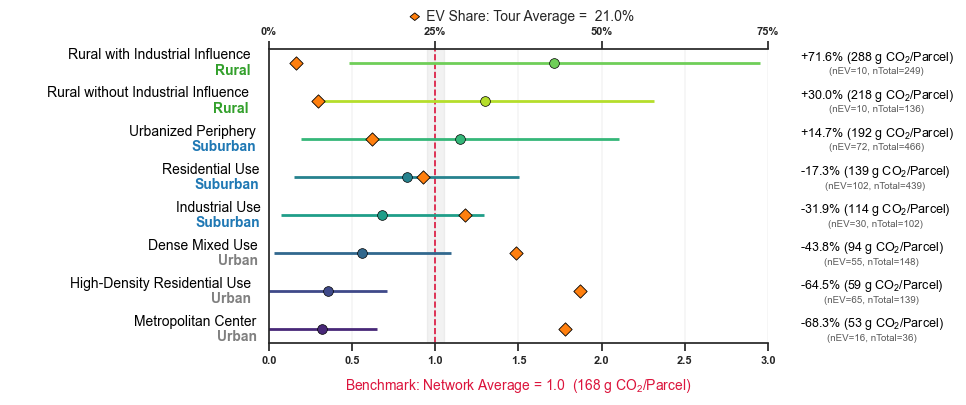

In [ ]:

# ── Figure 9 — CO₂ Benchmarking by Area Type ────────────────────────────
# Forest plot: each area type's mean CO₂ per parcel indexed against the
# network average (= 1.0), with ±1 SD whiskers, EV tour share on a
# twin axis, and right-side annotation boxes.
# Requires: bc_valid, category_color_dict, category_dict, determine_area_type
#           (all from setup / data-loading cells).

# ── 1. Prepare working copy ─────────────────────────────────────────────

result = bc_valid.copy()
result["main_area_type_name"] = (
    result["main_area_type"].astype(str).map(category_dict).fillna("Unknown")
)
co2_col = "emissions_per_parcel"          # g CO₂ per parcel (already in bc)
CO2_LABEL = r"CO$_{\mathregular{2}}$"     # renders "2" in text font
area_colors = category_color_dict         # 8-area-type colour mapping

# Aggregated-type colours for the small labels below each Y tick
_cat_agg_colors = {
    "Urban":    "#808080",
    "Suburban": "#1f78b4",
    "Rural":    "#33a02c",
}

# ── 2. EV indicator ─────────────────────────────────────────────────────

def _ensure_is_ev(df):
    if "is_ev" in df.columns:
        return df["is_ev"].astype(bool)
    cols = {c.lower(): c for c in df.columns}
    for cand in ("vehicle_powertrain", "powertrain", "drivetrain",
                 "vehicle_type", "fuel_type"):
        if cand in cols:
            s = df[cols[cand]].astype(str).str.lower()
            return s.str.contains("bev|ev|electric")
    raise ValueError("Missing EV indicator. Provide 'is_ev' or a powertrain column.")

is_ev = _ensure_is_ev(result)

# ── 3. Statistics for the forest plot ────────────────────────────────────

overall_mean = result[co2_col].mean()
stats = (
    result.groupby("main_area_type_name")[co2_col]
          .agg(mean="mean", std=lambda s: float(np.std(s, ddof=1)), n="count")
)

bench = (stats["mean"] / overall_mean).sort_values()
areas = bench.index.tolist()
colors = [area_colors.get(a, "#999999") for a in areas]

sd_norm  = (stats.loc[areas, "std"] / overall_mean).to_numpy()
ci_lo    = bench.values - sd_norm
ci_hi    = bench.values + sd_norm

y = np.arange(len(areas))
fig_h = 0.5 * len(areas) + 0.5
fig, ax = plt.subplots(figsize=(10, fig_h))

# Equivalence band and reference line
ax.axvspan(0.95, 1.05, color="#cccccc", alpha=0.25, zorder=0)
ax.axvline(1.0, color="crimson", ls="--", lw=1.2, zorder=1)

# Forest elements (point + whisker)
for i, a in enumerate(areas):
    ax.hlines(y[i], ci_lo[i], ci_hi[i], color=colors[i], lw=2, zorder=2)
    ax.plot(bench.iloc[i], y[i], "o", ms=7,
            color=colors[i], mec="k", mew=0.5, zorder=30)

ax.set_yticks(y)
ax.set_yticklabels([''] * len(areas))  # labels placed via ax.text below

# x limits with extra room for annotation boxes
xmin_core = 0.0
xmax_core = float(max(ci_hi.max(), bench.max()))
xrange_core = xmax_core - xmin_core
xmax = min(xmax_core + 0.38 * xrange_core, 3.0)
ax.set_xlim(xmin_core, xmax)

# ── 4. EV counts & weighted share ───────────────────────────────────────

ev_count_by_area = (
    result.assign(is_ev=is_ev)
          .groupby("main_area_type_name")["is_ev"]
          .sum().reindex(areas).fillna(0).astype(int)
)
total_tours_by_area = (
    result.groupby("main_area_type_name")[co2_col]
          .count().reindex(areas).fillna(0).astype(int)
)

weight_mode = "tour"
def _weighted_mean_bool(x, w=None):
    x = np.asarray(x, dtype=float)
    if w is None:
        return float(np.mean(x)) if x.size else np.nan
    w = np.asarray(w, dtype=float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return float(np.average(x[m], weights=w[m])) if np.any(m) else np.nan

w_series = (result["deliveries"]
            if (weight_mode == "parcel" and "deliveries" in result.columns)
            else None)

ev_share = (
    result.assign(is_ev=is_ev)
          .groupby("main_area_type_name")["is_ev"]
          .apply(lambda s: _weighted_mean_bool(
              s, w_series.loc[s.index] if w_series is not None else None))
          .reindex(areas)
)

# ── 5. Right-side annotation boxes ──────────────────────────────────────

xrange_full = ax.get_xlim()[1] - ax.get_xlim()[0]
offset = 0.08 * xrange_full
_ANNOT_X_MIN = 2.0   # fixed min x so labels sit right of EV diamonds

for i, a in enumerate(areas):
    pct   = (bench.loc[a] - 1.0) * 100.0
    abs_g = float(stats.loc[a, "mean"])
    n_ev  = int(ev_count_by_area.loc[a])
    n_all = int(total_tours_by_area.loc[a])

    line1 = f"{pct:+.1f}% ({abs_g:,.0f} g {CO2_LABEL}/Parcel)"
    line2 = f"(nEV={n_ev:,}, nTotal={n_all:,})"

    ta1 = TextArea(line1, textprops=dict(size=9, weight="normal", color="black"))
    ta2 = TextArea(line2, textprops=dict(size=7, weight="normal", color="0.35"))
    vpack = VPacker(children=[ta1, ta2], align="center", pad=0, sep=1.0)

    ab = AnnotationBbox(
        vpack,
        (ci_hi[-1] + offset, y[i]),
        xycoords=("data", "data"),
        box_alignment=(0.0, 0.5),
        frameon=True,
        bboxprops=dict(boxstyle="round,pad=0.18",
                       fc="white", ec="white", lw=0.8, alpha=1),
        zorder=4,
        clip_on=False,
    )
    ax.add_artist(ab)

# Benchmark note – set as xlabel after tight_layout (see end of cell)

ax.grid(axis="x", linewidth=0.25, alpha=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── 6. Twin axis — EV tour share ────────────────────────────────────────

def _map_share(s, x_at_0=0.0, x_at_25=1.0):
    s = np.asarray(s, dtype=float)
    scale = (x_at_25 - x_at_0) / 0.25
    return x_at_0 + scale * s

xmin_ax, xmax_ax = ax.get_xlim()
ax2 = ax.twiny()
ax2.set_xlim(xmin_ax, xmax_ax)

overall_ev_share = _weighted_mean_bool(is_ev, w_series) * 100.0
ax2.set_xlabel(f"      EV Share: Tour Average =  {overall_ev_share:.1f}%", fontsize=10, weight="medium")


ticks_share = np.array([0.0, 0.25, 0.5, 0.75])
tick_pos = _map_share(ticks_share)
m = (tick_pos >= xmin_ax) & (tick_pos <= xmax_ax)
ax2.set_xticks(tick_pos[m])
ax2.set_xticklabels([f"{int(t * 100)}%" for t in ticks_share[m]])

x_ev = _map_share(np.asarray(ev_share, dtype=float))
ax2.scatter(x_ev, y, marker="D", s=46,
            color="tab:orange", edgecolor="k", linewidth=0.6, zorder=10)

ax2.grid(False)
ax2.spines["bottom"].set_visible(False)
ax2.spines["top"].set_visible(True)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

# EV legend marker is now part of ax2 xlabel

# ── 7. Left-side labels: main area type + aggregated type ────────────────
# Two ax.text() calls via get_yaxis_transform() (axes-fraction x, data y).
# va="bottom" places the area-type name above y[i];
# va="top" places the aggregate label below y[i] → pair is centred on tick.

for i, a in enumerate(areas):
    agg     = AREA_GROUP_LOOKUP.get(a, "unknown")
    agg_col = _cat_agg_colors.get(agg, "0.35")

    ax.text(-0.02, y[i], a,
            transform=ax.get_yaxis_transform(),
            ha="right", va="bottom", size=10, weight="normal", color="black",
            clip_on=False)
    ax.text(-0.02, y[i], agg,
            transform=ax.get_yaxis_transform(),
            ha="right", va="top", size=10, weight="bold", color=agg_col,
            clip_on=False)

fig.tight_layout()
plt.subplots_adjust(bottom=0.22)
ax.set_xlabel(
    f"Benchmark: Network Average = 1.0  ({overall_mean:.0f} g {CO2_LABEL}/Parcel)",
    color="crimson", fontsize=10, weight="medium", labelpad=8,
)
# place orange diamond marker (matching plot style) at the start of the EV xlabel
fig.canvas.draw()
_lbl = ax2.xaxis.label
_bb = _lbl.get_window_extent(fig.canvas.get_renderer())
_x0, _y0 = fig.transFigure.inverted().transform((_bb.x0, (_bb.y0 + _bb.y1) / 2))
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from matplotlib.markers import MarkerStyle
_ms = MarkerStyle("D")
_dp = _ms.get_path().transformed(_ms.get_transform())
_diamond = mpatches.PathPatch(
    _dp.transformed(mtransforms.Affine2D().scale(0.012 * fig_h / 8, 0.012).translate(_x0 + 0.012, _y0)),
    facecolor="tab:orange", edgecolor="k", linewidth=0.6, zorder=99,
    transform=fig.transFigure, clip_on=False
)
fig.add_artist(_diamond)

plt.show()
fig.savefig("figures-and-tables/jotg_figure9_co2_benchmarking.pdf", dpi=300, bbox_inches="tight")


### Figure 10 — Smoothed Surface of Total Daily CO₂ Emissions

Spatial distribution of total daily CO₂ emissions across the study area. The surface is derived from link-based HBEFA emission calculations aggregated to 10 km hexagons, followed by cubic interpolation with a Delaunay hull mask. Base map shows aggregated area types (Urban / Suburban / Rural) and LMD traffic volumes.

In [25]:
# ── Figure 10 — Data Preparation & Helper Functions ──────────────────────
# Load HBEFA per-link emissions, aggregate to 10 km hex grid, compute
# Delaunay-masked interpolation surface, define 3-D drawing utilities.

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
from scipy.interpolate import griddata
from scipy.spatial import Delaunay

# ── Aggregated area-type colour mapping ──────────────────────────────────

category_color_dict_agg = {
    "Urban":    "#808080",
    "Suburban": "#1f78b4",
    "Rural":    "#33a02c",
}

GROUP_BY_NAME  = {v: AREA_GROUP_LOOKUP[v] for v in AREA_GROUP_LOOKUP}
_GROUP_BY_ID   = {1: "Urban", 2: "Urban", 3: "Urban",
                  4: "Suburban", 5: "Suburban", 6: "Suburban",
                  7: "Rural", 8: "Rural"}

def area_type_group(x):
    """Map area-type name or integer ID → Urban / Suburban / Rural."""
    try:
        rid = int(str(x).strip())
        if rid in _GROUP_BY_ID:
            return _GROUP_BY_ID[rid]
    except Exception:
        pass
    return GROUP_BY_NAME.get(str(x).strip(), "unknown")

from collections import defaultdict
import matsim as _matsim

_event_file = "../input/simRes/500-it/basecase_13052025/basecase_13052025.output_events.xml.gz"
_DAYEND = 24 * 3600

_link_counts = defaultdict(lambda: defaultdict(int))
_van_links   = defaultdict(list)            # vehicle_id → [link_id, …]
_last_link   = {}

for _ev in _matsim.event_reader(_event_file, types="left link"):
    if _ev["time"] > _DAYEND:
        continue
    _veh, _link = _ev["vehicle"], _ev["link"]
    if _link == _last_link.get(_veh, ""):
        continue
    _last_link[_veh] = _link

    if "_Supply_Vehicle_" in _veh or "_veh_supply_" in _veh:
        if "supply_light_van" in _veh:
            _link_counts[_link]["supply_van"] += 1
        elif "light" in _veh:
            _link_counts[_link]["truck_light"] += 1
        else:
            _link_counts[_link]["truck"] += 1
    elif "_CEP_Vehicle_" in _veh or "_veh_cep_" in _veh or "_egrocery_van_" in _veh:
        _link_counts[_link]["van"] += 1
        _van_links[_veh].append(_link)
    elif "_cargoBike_" in _veh or "_cargobike_" in _veh:
        _link_counts[_link]["bike"] += 1

# Build per-link DataFrame
_counts_df = pd.DataFrame.from_dict(_link_counts, orient="index").fillna(0).astype(int)
for _c in ["van", "truck", "truck_light", "supply_van", "bike"]:
    if _c not in _counts_df.columns:
        _counts_df[_c] = 0
_counts_df["total_count"] = _counts_df.sum(axis=1)
_counts_df.index.name = "link_id"

print(f"Parsed events: {len(_counts_df):,} links with freight traffic")

category_dict_int = {int(k): v for k, v in category_dict.items()}
networkplus = pd.read_pickle("../input/networkplus.pkl")
_link_raumtyp = networkplus["raumtyp"].to_dict()

network_volumes = network.merge(
    _counts_df, left_on="link_id", right_index=True, how="left"
).fillna(0)
network_volumes["van"]         = network_volumes["van"].astype(int)
network_volumes["total_count"] = network_volumes["total_count"].astype(int)
network_volumes["raumtyp"]     = network_volumes["link_id"].map(_link_raumtyp)

network_volumes_filtered = (
    network_volumes[network_volumes["van"] > 0]
    .copy()
    .rename(columns={"van": "van_count"})
)

# ── Load HBEFA emissions ─────────────────────────────────────────────────

emissions_15min_long = pd.read_pickle(
    "../input/simRes/batch/processed/"
    "basecase_13052025_500it_emissions_15min_long_JoTG.pkl"
)

emissions_day = (
    emissions_15min_long
    .groupby("link_id", as_index=False)["emissions_g"]
    .sum()
    .rename(columns={"emissions_g": "emissions_g_day"})
)

# Spatialise links — keep only those with positive emissions
links_gdf = (
    network[["link_id", "geometry"]]
    .drop_duplicates(subset=["link_id"])
    .merge(emissions_day, on="link_id", how="left")
    .fillna({"emissions_g_day": 0.0})
)
if links_gdf.crs != regionclusters_split.crs:
    links_gdf = links_gdf.to_crs(regionclusters_split.crs)
links_gdf = links_gdf[links_gdf["emissions_g_day"] > 0]

# ── 10 km flat-topped hex grid ───────────────────────────────────────────

hex_size = 10_000.0
r  = hex_size / 2.0
dx = 1.5 * r
dy = np.sqrt(3) * r / 2.0

minx, miny, maxx, maxy = links_gdf.total_bounds
minx -= hex_size; miny -= hex_size; maxx += hex_size; maxy += hex_size

def _hex_polygon(cx, cy, rad):
    angles = np.deg2rad([0, 60, 120, 180, 240, 300])
    return Polygon([(cx + rad * np.cos(a), cy + rad * np.sin(a)) for a in angles])

hexes, hex_ids = [], []
j, row_i = 0, 0
y = miny
while y <= maxy + 1e-6:
    x_off = 0.0 if row_i % 2 == 0 else dx / 2.0
    x = minx
    while x <= maxx + 1e-6:
        hexes.append(_hex_polygon(x + x_off, y, r))
        hex_ids.append(j); j += 1
        x += dx
    y += dy; row_i += 1

hex_gdf = gpd.GeoDataFrame({"hex_id": hex_ids}, geometry=hexes, crs=links_gdf.crs)
hex_gdf["cx"] = hex_gdf.geometry.centroid.x.astype(float)
hex_gdf["cy"] = hex_gdf.geometry.centroid.y.astype(float)

# Assign each link to its dominant hex (longest overlap)
inter = gpd.overlay(
    links_gdf[["link_id", "geometry", "emissions_g_day"]],
    hex_gdf[["hex_id", "geometry"]], how="intersection",
)
inter["seg_len"] = inter.geometry.length
link2hex = inter.loc[
    inter.groupby("link_id")["seg_len"].idxmax(), ["link_id", "hex_id"]
]

# Sum emissions per hex [kg/day]
em_hex = (
    emissions_day.merge(link2hex, on="link_id", how="inner")
    .groupby("hex_id", as_index=False)["emissions_g_day"].sum()
)
em_hex["emissions_kg_day"] = em_hex["emissions_g_day"] / 1000.0

hex_emit = (
    hex_gdf.merge(em_hex[["hex_id", "emissions_kg_day"]], on="hex_id", how="left")
    .fillna({"emissions_kg_day": 0.0})
)

# Dominant area type per hex (centroid spatial join)
centroids = gpd.GeoDataFrame(
    {"hex_id": hex_emit["hex_id"], "geometry": hex_emit.geometry.centroid},
    crs=hex_emit.crs,
)
ct = gpd.sjoin(
    centroids, regionclusters_split[["area_type", "geometry"]],
    how="left", predicate="within",
)
hex_emit = hex_emit.merge(ct[["hex_id", "area_type"]], on="hex_id", how="left")

# Build height tuples (cx, cy, shifted_kg, colour) — drop zero hexes
em_hex_heights = []
for _, row in hex_emit.iterrows():
    kg = float(row["emissions_kg_day"])
    if kg <= 0:
        continue
    em_hex_heights.append((
        float(row["cx"]), float(row["cy"]),
        (kg + 4000) / 1000,
        category_color_dict.get(row.get("area_type"), "#888888"),
    ))

em_hx     = np.array([h[0] for h in em_hex_heights])
em_hy     = np.array([h[1] for h in em_hex_heights])
em_values = np.array([h[2] for h in em_hex_heights])

# ── Cubic interpolation + Delaunay hull mask ─────────────────────────────

em_grid_x, em_grid_y = np.mgrid[em_hx.min():em_hx.max():500j, em_hy.min():em_hy.max():500j]
em_grid_z         = griddata((em_hx, em_hy), em_values, (em_grid_x, em_grid_y), method="cubic")
em_grid_z_masked  = np.ma.masked_invalid(em_grid_z)

tri    = Delaunay(np.column_stack([em_hx, em_hy]))
XY     = np.column_stack([em_grid_x.ravel(), em_grid_y.ravel()])
inside = (tri.find_simplex(XY) >= 0).reshape(em_grid_x.shape)
em_grid_z_masked = np.ma.masked_array(em_grid_z_masked, mask=~inside)

em_finite = em_values[np.isfinite(em_values)]
em_vmin = float(np.nanmin(em_finite))
em_vmax = float(np.nanmax(em_finite))

print(
    f"Total daily CO₂: {emissions_day['emissions_g_day'].sum() / 1e6:.2f} t  |  "
    f"Links: {len(emissions_day):,}  |  Non-zero hexes: {len(em_hex_heights)}  |  "
    f"Surface range: {em_vmin:.2f} – {em_vmax:.2f}"
)

# ── 3-D rotation & drawing helpers ───────────────────────────────────────

def _rotate_xy(xa, ya, cx, cy, deg):
    xa, ya = np.asarray(xa, float), np.asarray(ya, float)
    th = np.deg2rad(float(deg))
    c, s = np.cos(th), np.sin(th)
    dx, dy = xa - cx, ya - cy
    return cx + c * dx - s * dy, cy + s * dx + c * dy

def rotate_grid(X, Y, cx, cy, deg):
    return _rotate_xy(X, Y, cx, cy, deg)

def draw_area_polygons_at(
    ax3d, gdf, color_map,
    edgecolor=(0.4, 0.4, 0.4, 1.0),
    default_color=(0.85, 0.85, 0.85, 1.0),
    alpha=0.9, z0=0.0,
    rotate_deg=0.0, origin=None,
    rasterized=True, force_back=True,
):
    if origin is None:
        bx = gdf.total_bounds
        origin = (0.5 * (bx[0] + bx[2]), 0.5 * (bx[1] + bx[3]))
    cx, cy = origin
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        fc = color_map.get(row.get("area_type_group"), default_color)
        polys = (
            [geom] if geom.geom_type == "Polygon"
            else list(geom.geoms) if geom.geom_type == "MultiPolygon"
            else []
        )
        for poly in polys:
            ex_x, ex_y = poly.exterior.coords.xy
            ex_x, ex_y = _rotate_xy(ex_x, ex_y, cx, cy, rotate_deg)
            verts = [(float(x), float(y), float(z0)) for x, y in zip(ex_x, ex_y)]
            coll = Poly3DCollection(
                [verts], facecolors=fc, edgecolors=edgecolor,
                linewidths=0.4, alpha=alpha,
            )
            coll.set_zsort("min")
            coll.set_sort_zpos(-1e9)
            if rasterized:
                coll.set_rasterized(True)
            ax3d.add_collection3d(coll)
            for interior in poly.interiors:
                ix, iy = interior.coords.xy
                ix, iy = _rotate_xy(ix, iy, cx, cy, rotate_deg)
                verts_in = [(float(x), float(y), float(z0)) for x, y in zip(ix, iy)]
                hole = Poly3DCollection(
                    [verts_in], facecolors=(1, 1, 1, 0),
                    edgecolors=edgecolor, linewidths=0.3, alpha=1.0,
                )
                if rasterized:
                    hole.set_rasterized(True)
                if force_back:
                    try:
                        hole.set_zsort("min")
                        hole.set_sort_zpos(-1e12)
                    except Exception:
                        hole._sort_zpos = -1e12
                ax3d.add_collection3d(hole)

def add_traffic_lines_3d(
    ax3d, gdf_lines, value_col="van_count",
    z0=0.0, lw_min=0.2, lw_max=6.0,
    alpha=0.85, crs_target=None, rasterized=True,
    rotate_deg=0.0, origin=None,
    cmap="Reds", vmin=None, vmax=None,
    min_tone=0.25, force_front=True,
):
    if gdf_lines is None or gdf_lines.empty:
        return
    gdf = gdf_lines.copy()
    m = np.isfinite(gdf[value_col]) & (gdf[value_col] > 0)
    gdf = gdf[m]
    if gdf.empty:
        return
    if (crs_target is not None and hasattr(gdf, "to_crs")
            and gdf.crs is not None and gdf.crs != crs_target):
        gdf = gdf.to_crs(crs_target)
    v = gdf[value_col].to_numpy(dtype=float)
    if vmin is None:
        vmin = float(np.nanmin(v))
    if vmax is None:
        vmax = float(np.nanmax(v))
    if vmax <= vmin:
        vmax = vmin + 1.0
    norm = np.clip((v - vmin) / (vmax - vmin), 0, 1)
    norm = min_tone + (1.0 - min_tone) * norm
    lw_vec = np.clip(
        lw_min + ((v - vmin) / (vmax - vmin)) * (lw_max - lw_min),
        lw_min, lw_max,
    )
    lw_map = dict(zip(gdf.index.to_numpy(), lw_vec))
    if origin is None:
        bx = gdf.total_bounds
        origin = (0.5 * (bx[0] + bx[2]), 0.5 * (bx[1] + bx[3]))
    cx, cy = origin
    cmap_obj = plt.get_cmap(cmap)
    segments, widths, colors = [], [], []
    for row_idx, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        idx = np.where(gdf.index.to_numpy() == row_idx)[0][0]
        col = list(cmap_obj(norm[idx]))
        col[3] = alpha
        line_w = lw_map.get(row_idx, lw_min)
        def _add_ls(ls, _col=tuple(col), _lw=line_w):
            coords = np.asarray(ls.coords, dtype=float)
            if coords.shape[0] < 2:
                return
            xr, yr = _rotate_xy(coords[:, 0], coords[:, 1], cx, cy, rotate_deg)
            segments.append(np.column_stack([xr, yr, np.full(len(xr), z0)]))
            widths.append(float(_lw))
            colors.append(_col)
        if geom.geom_type == "LineString":
            _add_ls(geom)
        elif geom.geom_type == "MultiLineString":
            for ls in geom.geoms:
                _add_ls(ls)
    if not segments:
        return
    lc = Line3DCollection(segments, linewidths=np.asarray(widths))
    lc.set_colors(colors)
    if rasterized:
        lc.set_rasterized(True)
    if force_front:
        try:
            lc.set_zsort("max")
            lc.set_sort_zpos(1e12)
        except Exception:
            lc._sort_zpos = 1e12
    ax3d.add_collection3d(lc)

def _truncated_cmap(name="Reds", lo=0.0, hi=1.0, N=256):
    base = mpl.colormaps[name]
    return mpl.colors.LinearSegmentedColormap.from_list(
        f"{name}_trunc", base(np.linspace(lo, hi, N)),
    )

Parsed events: 72,901 links with freight traffic
Total daily CO₂: 30.39 t  |  Links: 72,901  |  Non-zero hexes: 95  |  Surface range: 4.00 – 6.07


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\1660549685.py:109: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


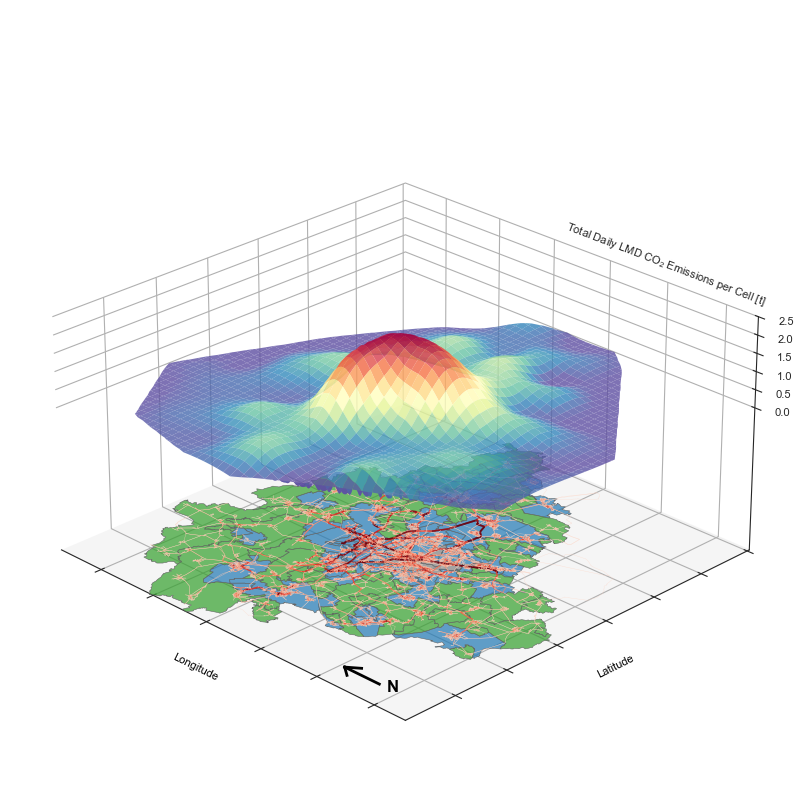

In [110]:
# ── Figure 10 — 3-D Emission Surface ─────────────────────────────────────

# Temporarily disable seaborn for correct 3-D z-ordering
_rc_backup = mpl.rcParams.copy()
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    "font.family":      ["sans-serif"],
    "font.sans-serif":  ["Arial", "DejaVu Sans", "Liberation Sans",
                         "Bitstream Vera Sans", "sans-serif"],
    "font.weight":      "bold",
    "font.size":        9.0,
    "axes.labelsize":   9.0,
    "axes.labelweight": "normal",
    "axes.titlesize":   9.0,
    "axes.titleweight": "normal",
    "xtick.labelsize":  8.0,
    "ytick.labelsize":  8.0,
    "text.color":       ".15",
    "xtick.color":      ".15",
    "ytick.color":      ".15",
    "axes.edgecolor":   ".15",
    "axes.facecolor":   "white",
    "axes.grid":        False,
})

ROTATE_DEG = 90.0
cx = 0.5 * (float(em_grid_x.min()) + float(em_grid_x.max()))
cy = 0.5 * (float(em_grid_y.min()) + float(em_grid_y.max()))
origin = (cx, cy)

fig = plt.figure(figsize=(10, 10))
ax  = fig.add_subplot(111, projection="3d")

# Basemap: aggregated area-type polygons
base_gdf = regionclusters_split[["area_type", "geometry"]].copy()
base_gdf["area_type_group"] = base_gdf["area_type"].apply(area_type_group)
draw_area_polygons_at(
    ax, base_gdf, category_color_dict_agg,
    alpha=0.7, z0=0, rotate_deg=ROTATE_DEG, origin=origin,
)

# Traffic lines
lines_gdf = network_volumes_filtered[network_volumes_filtered["van_count"] > 0].copy()
add_traffic_lines_3d(
    ax3d=ax, gdf_lines=lines_gdf, value_col="van_count",
    z0=1e-6, lw_min=0.25, lw_max=1.25, alpha=0.75,
    crs_target=regionclusters_split.crs,
    rasterized=True, rotate_deg=ROTATE_DEG, origin=origin,
    cmap="Reds", vmax=100, min_tone=0.15,
)

# Emission surface
Xr, Yr = rotate_grid(em_grid_x, em_grid_y, cx, cy, ROTATE_DEG)
surf = ax.plot_surface(
    Xr, Yr, em_grid_z_masked,
    cmap="Spectral_r", linewidth=0, antialiased=True,
    alpha=0.8, vmin=em_vmin, vmax=em_vmax,
)
surf.set_rasterized(True)

# Axes styling
ax.set_xlabel("Longitude", fontsize=8, fontweight="normal")
ax.set_ylabel("Latitude", fontsize=8, fontweight="normal")

ax.get_proj = lambda: np.dot(Axes3D.get_proj(ax), np.diag([1, 1, 0.7, 1]))

ax.xaxis.pane.set_edgecolor((1, 1, 1, 0))
ax.yaxis.pane.set_edgecolor((1, 1, 1, 0))
ax.xaxis.pane.set_facecolor((1, 1, 1, 0))
ax.yaxis.pane.set_facecolor((1, 1, 1, 0))

ax.set_xlim(float(Xr.min()), float(Xr.max() + 2500))
ax.set_ylim(float(Yr.min() - 2500), float(Yr.max()))
ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False)

# North arrow
x0     = float(Xr.min()) + 48_500
y0     = float(Yr.min()) + 2_000
x_span = float(Xr.max() - Xr.min())
L      = max(1.0, 0.1 * x_span)
x_tip  = min(x0 + L, float(Xr.max()) - 0.01 * x_span)
h_ar, w_ar = 0.28 * L, 0.23 * L
ax.plot([x0, x_tip],     [y0, y0],        [0, 0], color="k", linewidth=2)
ax.plot([x0, x0 + h_ar], [y0, y0 - w_ar], [0, 0], color="k", linewidth=2)
ax.plot([x0, x0 + h_ar], [y0, y0 + w_ar], [0, 0], color="k", linewidth=2)
ax.text(x_tip + 0.2 * L, y0, 0, "N", color="k", fontsize=12, ha="left", va="center")

# Rotated z-label
ax.text2D(
    0.72, 0.67, r"Total Daily LMD CO$_{\mathregular{2}}$ Emissions per Cell [t]",
    transform=ax.transAxes, rotation=-21, va="center", ha="left",
    fontsize=8, fontweight="normal",
)

ax.view_init(elev=25, azim=-45)
ax.set_zlim(0, 6.5)
ticks = np.arange(4.0, 6.51, 0.5)
ax.set_zticks(ticks)
ax.set_zticklabels([f"{v - 4.0:.1f}" for v in ticks], fontsize=8, fontweight="normal")

# Rasterize all collections for clean SVG export
for coll in ax.collections:
    try:
        coll.set_rasterized(True)
    except Exception:
        pass

plt.tight_layout()
fig.savefig("figures-and-tables/jotg_figure10_emissions_surface.svg", format="svg",
            bbox_inches="tight", pad_inches=0.02, transparent=True)
plt.show()

# Restore seaborn theme
mpl.rcParams.update(_rc_backup)

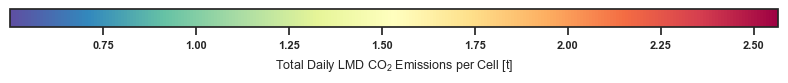

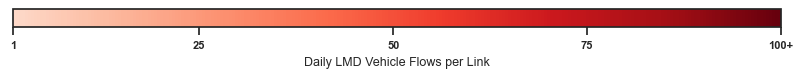

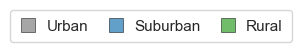

In [27]:
# ── Figure 10 — Colorbars & Area-Type Legend ─────────────────────────────

mpl.rcParams["svg.fonttype"] = "none"

# --- Emissions colorbar (Spectral_r) ---
norm_em = mpl.colors.Normalize(vmin=em_vmin - 3.5, vmax=em_vmax - 3.5)
sm_em   = mpl.cm.ScalarMappable(norm=norm_em, cmap=mpl.colormaps["Spectral_r"])
sm_em.set_array([])

fig_cb1, ax_cb1 = plt.subplots(figsize=(8, 0.45))
cbar1 = fig_cb1.colorbar(sm_em, cax=ax_cb1, orientation="horizontal")
cbar1.set_label(r"Total Daily LMD CO$_{\mathregular{2}}$ Emissions per Cell [t]", fontsize=9, labelpad=4)
cbar1.ax.tick_params(labelsize=8)
fig_cb1.subplots_adjust(left=0.02, right=0.98, top=0.85, bottom=0.45)
# fig_cb1.savefig("figures-and-tables/jotg_figure10_colorbar_emissions.svg", format="svg",
#                  bbox_inches="tight", pad_inches=0.02, transparent=True)
plt.show()

# --- Traffic colorbar (truncated Reds) ---
cmap_traffic = _truncated_cmap("Reds", lo=0.15, hi=1.0)
norm_tr = mpl.colors.Normalize(
    vmin=float(network_volumes_filtered["van_count"].min()), vmax=100,
)
sm_tr = mpl.cm.ScalarMappable(norm=norm_tr, cmap=cmap_traffic)
sm_tr.set_array([])

fig_cb2, ax_cb2 = plt.subplots(figsize=(8, 0.45))
cbar2 = fig_cb2.colorbar(sm_tr, cax=ax_cb2, orientation="horizontal")
cbar2.set_label("Daily LMD Vehicle Flows per Link", fontsize=9, labelpad=4)
cbar2.set_ticks([1, 25, 50, 75, 100])
cbar2.set_ticklabels(["1", "25", "50", "75", "100+"])
cbar2.ax.tick_params(labelsize=8)
fig_cb2.subplots_adjust(left=0.02, right=0.98, top=0.85, bottom=0.45)
# fig_cb2.savefig("figures-and-tables/jotg_figure10_colorbar_traffic.svg", format="svg",
#                  bbox_inches="tight", pad_inches=0.02, transparent=True)
plt.show()

# --- Area-type legend (1 × 3) ---
labels_area  = list(category_color_dict_agg.keys())
colors_area  = [category_color_dict_agg[k] for k in labels_area]
handles_area = [
    Line2D([0], [0], marker="s", linestyle="", color="w",
           markerfacecolor=c, markeredgewidth=0.5,
           markeredgecolor="black", markersize=10, alpha=0.7)
    for c in colors_area
]

fig_lg, ax_lg = plt.subplots(figsize=(2, 0.925 / 2.5))
ax_lg.axis("off")
fig_lg.legend(
    handles_area, labels_area, loc="center", ncol=3, frameon=True,
    fontsize=9, prop={'weight': 'normal'}, handlelength=1.2, handletextpad=0.6,
    columnspacing=1.2, borderpad=0.6,
)
fig_lg.tight_layout(pad=0.1)
# fig_lg.savefig("figures-and-tables/jotg_figure10_legend_area_types_agg.svg",
#                 bbox_inches="tight", pad_inches=0.02)
plt.show()

### Table 4 — Aggregated Network Metrics by Area Types

Summary of LMD vehicle counts, total driven distance, CO₂ emissions, and network utilisation intensity by area type. Metrics are reported both at the aggregated (Urban/Suburban/Rural) and detailed (8-type) level.


In [162]:
# ── Table 4: Aggregated Network Metrics by Area Types ───────────────────
# Fully LINK-based aggregation along the MATSim road network:
#   (a) Network length        — each link counted once per raumtyp
#   (b) LMD driven distance   — van_count × link length, by link-raumtyp
#   (c) LMD CO₂ emissions     — per-link HBEFA emissions (emissions_day),
#                               by link-raumtyp (same source as Figure 10)
# Vehicle count stays tour-based (per-link vehicles is meaningless).
# Reported at detailed (8 types) and aggregated (3 types) levels.
# Reuses _counts_df, _van_links, network_volumes, networkplus,
# category_dict_int, emissions_day from the Figure 10 data-preparation cell.

# ── 1. Low-utilisation filter ───────────────────────────────────────────
# Subtract link traversals of vehicles NOT in bc_valid (util ≤ 5 %)
# from a private copy of the counts so the Figure 10 data stays intact.

from collections import Counter

_counts_filtered = _counts_df.copy()

_valid_vids = set(bc_valid["vehicle_id"].astype(str).unique())
_low_util_vids = set(_van_links.keys()) - _valid_vids

if _low_util_vids:
    _dec = Counter()
    for _vid in _low_util_vids:
        _dec.update(_van_links[_vid])
    _dec_series = _counts_filtered.index.to_series().map(_dec).fillna(0).astype(int)
    _before = int(_counts_filtered["van"].sum())
    _counts_filtered["van"] = (_counts_filtered["van"] - _dec_series).clip(lower=0)
    _after  = int(_counts_filtered["van"].sum())
    _counts_filtered["total_count"] = _counts_filtered[["van", "truck", "truck_light", "supply_van", "bike"]].sum(axis=1)
    print(f"Low-util filter: {len(_low_util_vids)} vehicles removed, "
          f"van traversals {_before:,} → {_after:,}")
else:
    print("No low-util vehicles to remove.")

# ── 2. Build filtered network_volumes for Table 4 ───────────────────────

_link_raumtyp = networkplus["raumtyp"].to_dict()

_nv = network.merge(
    _counts_filtered, left_on="link_id", right_index=True, how="left"
).fillna(0)
_nv["van"]         = _nv["van"].astype(int)
_nv["total_count"] = _nv["total_count"].astype(int)
_nv["raumtyp"]     = _nv["link_id"].map(_link_raumtyp)

# Keep links with ANY freight traffic AND valid area type (raumtyp 1–8)
nv_valid = _nv[
    (_nv["total_count"] > 0)
    & (_nv["raumtyp"].isin(range(1, 9)))
].copy()
nv_valid["area_type_detail"] = nv_valid["raumtyp"].map(category_dict_int)
nv_valid["area_type_agg"]    = nv_valid["raumtyp"].apply(determine_area_type)

# ── 3. Network length per area type (each link counted once) ────────────

net_detail = (
    nv_valid.groupby("area_type_detail")["length"].sum() / 1000
).rename("Network Length (km)")

net_agg = (
    nv_valid.groupby("area_type_agg")["length"].sum() / 1000
).rename("Network Length (km)")

# ── 4. LMD distance per area type (van_count × link length) ────────────

nv_valid["km_on_link"] = nv_valid["van"] * (nv_valid["length"] / 1000)

lmd_detail = (
    nv_valid.groupby("area_type_detail")["km_on_link"].sum()
).rename("Total LMD Distance (km)")

lmd_agg = (
    nv_valid.groupby("area_type_agg")["km_on_link"].sum()
).rename("Total LMD Distance (km)")

# ── 5. LMD CO₂ emissions per area type (link-based, HBEFA) ─────────────
# Uses the same per-link emissions_day series as Figure 10 surface plot,
# attributed to the link's own raumtyp. Links without raumtyp 1–8 are
# dropped (consistent with network/LMD-distance logic above).

_em_links = emissions_day.merge(
    nv_valid[["link_id", "area_type_detail", "area_type_agg"]],
    on="link_id",
    how="inner",
)

em_detail = (
    _em_links.groupby("area_type_detail")["emissions_g_day"].sum() / 1e6
).rename("LMD CO₂ Emissions (t)")

em_agg = (
    _em_links.groupby("area_type_agg")["emissions_g_day"].sum() / 1e6
).rename("LMD CO₂ Emissions (t)")

# ── 6. Tour-level vehicle count from bc_valid ──────────────────────────

bc_valid["main_area_type_name"] = bc_valid["main_area_type"].map(category_dict_int)
bc_valid["area_type_agg"]       = bc_valid["main_area_type"].apply(determine_area_type)

def _veh_count(df, group_col):
    """Unique vehicles by *group_col* (tour-level, majority raumtyp)."""
    return df.groupby(group_col)["vehicle_id"].nunique().rename("Vehicles").to_frame()

veh_detail = _veh_count(bc_valid, "main_area_type_name")
veh_agg    = _veh_count(bc_valid, "area_type_agg")

# ── 7. Build table per level ───────────────────────────────────────────

def _build_table(net_series, lmd_series, em_series, veh_df):
    """Merge network, LMD distance, link-emissions, vehicle count; compute shares."""
    tbl = (
        veh_df
        .join(net_series, how="outer")
        .join(lmd_series, how="outer")
        .join(em_series,  how="outer")
        .fillna(0)
    )

    totals = tbl.sum()
    tbl["Network Share (%)"]       = tbl["Network Length (km)"] / totals["Network Length (km)"] * 100
    tbl["LMD Distance Share (%)"]  = tbl["Total LMD Distance (km)"] / totals["Total LMD Distance (km)"] * 100
    tbl["LMD Emission Share (%)"]  = tbl["LMD CO₂ Emissions (t)"] / totals["LMD CO₂ Emissions (t)"] * 100
    tbl["LMD Distance (km)\nper Network km"] = tbl["Total LMD Distance (km)"] / tbl["Network Length (km)"]

    cols = [
        "Vehicles",
        "Network Length (km)",
        "Total LMD Distance (km)",
        "LMD CO₂ Emissions (t)",
        "Network Share (%)",
        "LMD Distance Share (%)",
        "LMD Emission Share (%)",
        "LMD Distance (km)\nper Network km",
    ]
    return tbl[cols]

table4_detail = _build_table(net_detail, lmd_detail, em_detail, veh_detail)
table4_agg    = _build_table(net_agg,    lmd_agg,    em_agg,    veh_agg)

# ── 8. Sort rows ───────────────────────────────────────────────────────

detail_order = [category_dict_int[i] for i in range(1, 9)]
table4_detail = table4_detail.reindex(detail_order)

agg_order = ["Urban", "Suburban", "Rural"]
table4_agg = table4_agg.reindex(agg_order)

# ── 9. Total row ───────────────────────────────────────────────────────

total_row = table4_detail.sum().to_frame("Total").T
total_row["Network Share (%)"]      = 100.0
total_row["LMD Distance Share (%)"] = 100.0
total_row["LMD Emission Share (%)"] = 100.0
total_row["LMD Distance (km)\nper Network km"] = np.nan

# ── 10. Combine into display table ─────────────────────────────────────

table4 = pd.concat([table4_agg, table4_detail, total_row])
table4.index.name = "Area Type"

# Rounding
table4["Vehicles"]                         = table4["Vehicles"].astype(int)
table4["Network Length (km)"]              = table4["Network Length (km)"].round(0).astype(int)
table4["Total LMD Distance (km)"]          = table4["Total LMD Distance (km)"].round(0).astype(int)
table4["LMD CO₂ Emissions (t)"]            = table4["LMD CO₂ Emissions (t)"].round(2)
table4["Network Share (%)"]                = table4["Network Share (%)"].round(2)
table4["LMD Distance Share (%)"]           = table4["LMD Distance Share (%)"].round(2)
table4["LMD Emission Share (%)"]           = table4["LMD Emission Share (%)"].round(2)
table4["LMD Distance (km)\nper Network km"] = table4["LMD Distance (km)\nper Network km"].round(2)

# ── 11. Export CSVs ────────────────────────────────────────────────────

table4_agg_export = pd.concat([table4_agg, total_row])
table4_agg_export.index.name = "Area Type"
table4_agg_export.to_csv("figures-and-tables/jotg_table4_network_metrics_agg.csv")

table4_detail_export = pd.concat([table4_detail, total_row])
table4_detail_export.index.name = "Area Type"
table4_detail_export.to_csv("figures-and-tables/jotg_table4_network_metrics_detail.csv")

# ── 12. Display ────────────────────────────────────────────────────────

print(f"Total vehicles: {int(table4.loc['Total', 'Vehicles']):,}")
print(f"Total network length: {int(table4.loc['Total', 'Network Length (km)']):,} km")
print(f"Total LMD distance: {int(table4.loc['Total', 'Total LMD Distance (km)']):,} km")
print(f"Total LMD CO₂ emissions (link-based): {table4.loc['Total', 'LMD CO₂ Emissions (t)']:.2f} t")
print()

table4.style.format({
    "Vehicles":                         "{:,}",
    "Network Length (km)":              "{:,}",
    "Total LMD Distance (km)":         "{:,}",
    "LMD CO₂ Emissions (t)":           "{:,.2f}",
    "Network Share (%)":                "{:.2f}",
    "LMD Distance Share (%)":          "{:.2f}",
    "LMD Emission Share (%)":          "{:.2f}",
    "LMD Distance (km)\nper Network km": "{:.2f}",
}, na_rep="–").set_caption("Table 4 — Aggregated Network Metrics by Area Types (link-based)")


Low-util filter: 24 vehicles removed, van traversals 1,204,585 → 1,199,859
Total vehicles: 1,715
Total network length: 9,823 km
Total LMD distance: 153,817 km
Total LMD CO₂ emissions (link-based): 30.35 t



,Vehicles,Network Length (km),Total LMD Distance (km),LMD CO₂ Emissions (t),Network Share (%),LMD Distance Share (%),LMD Emission Share (%),LMD Distance (km) per Network km
Area Type,,,,,,,,
Urban,323,797,"18,970",3.44,8.11,12.33,11.33,23.80
Suburban,"1,007","5,101","91,908",18.29,51.93,59.75,60.27,18.02
Rural,385,"3,926","42,939",8.62,39.96,27.92,28.39,10.94
Metropolitan Center,36,55,"1,693",0.31,0.56,1.10,1.01,30.91
High-Density Residential Use,139,264,"5,667",0.99,2.69,3.68,3.26,21.46
Dense Mixed Use,148,478,"11,610",2.15,4.87,7.55,7.07,24.28
Residential Use,439,"1,800","30,157",5.99,18.32,19.61,19.73,16.76
Industrial Use,102,674,"14,816",2.92,6.86,9.63,9.63,21.99
Urbanized Periphery,466,"2,627","46,936",9.38,26.75,30.51,30.91,17.86


## Appendix

Supplementary materials providing additional detail on logistics infrastructure, vehicle specifications, multivariate calibration diagnostics, and spatially disaggregated operational KPIs.

### Appendix 1A — Logistics Hub Map

Study-area map showing all 22 last-mile logistics hub locations in the Region Hanover, differentiated by logistics service provider. Hub markers are numbered for cross-referencing with Appendix 1B. An inset map shows the study area's position within Germany. Basemap tiles from CartoDB Positron provide geographic context.

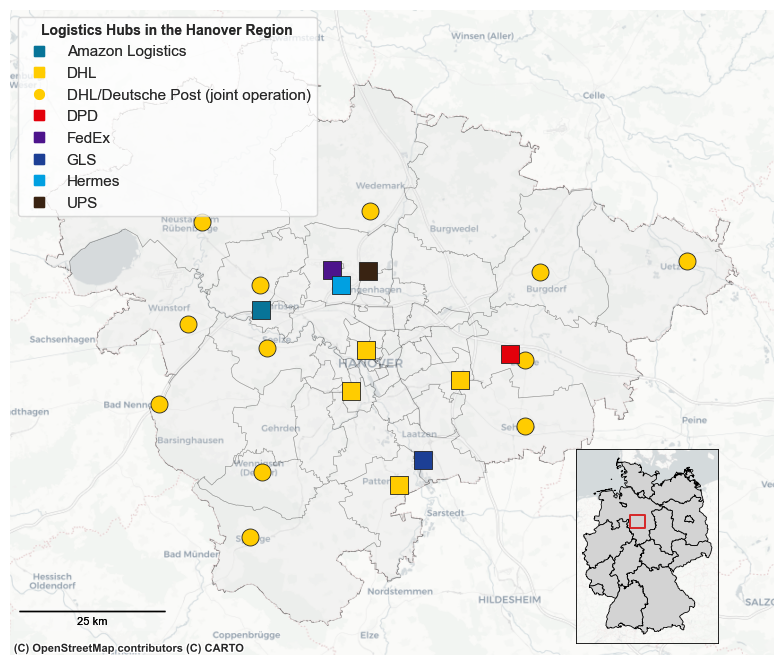

In [29]:
# ── Appendix A — Logistics Hub Map ───────────────────────────────────────
# Study-area map with basemap tiles, hub markers,
# inset Germany overview, and a fixed 25 km scalebar.
# Requires: hubs, gdf_de (from earlier cells).

from shapely import wkt

# ── 1. Fixed scalebar helper ─────────────────────────────────────────────

def _add_fixed_scalebar(ax, length_km=25, location="lower left", height_offset=0.1):
    """Add a fixed-length scalebar in metres (Web Mercator)."""
    size_m = float(length_km) * 1000.0
    fp = FontProperties(size=8, weight="regular")
    sb = AnchoredSizeBar(
        transform=ax.transData,
        size=size_m,
        label=f"{length_km:g} km",
        loc=location,
        pad=0.4, borderpad=0.4, sep=4,
        frameon=False, color="black",
        fontproperties=fp, fill_bar=True,
        bbox_to_anchor=(0, height_offset),
        bbox_transform=ax.transAxes,
    )
    ax.add_artist(sb)
    renderer = ax.figure.canvas.get_renderer()
    bb = sb.get_tightbbox(renderer)
    rect = mpatches.Rectangle(
        (bb.x0 / ax.figure.bbox.width, bb.y0 / ax.figure.bbox.height),
        bb.width / ax.figure.bbox.width,
        bb.height / ax.figure.bbox.height,
        transform=ax.figure.transFigure,
        facecolor="white", alpha=0.2,
        zorder=sb.zorder - 1, linewidth=0,
    )
    ax.add_artist(rect)
    ax.add_artist(sb)

# ── 2. Provider display mappings ─────────────────────────────────────────

prov_colors = {
    "dhl": "#FFCC00", "dp/dhl": "#FFCC00",
    "dpd": "#E3000B", "gls": "#1C3F95", "ups": "#392312",
    "hermes": "#00A0E1", "amazon": "#077498", "fedex": "#4D148C",
    "other": "#7f7f7f",
}
prov_markers = {
    "dhl": "s", "dp/dhl": "o", "dpd": "s", "gls": "s",
    "ups": "s", "hermes": "s", "amazon": "s", "fedex": "s", "other": "s",
}
prov_labels = {
    "dhl": "DHL",
    "dp/dhl": "DHL/Deutsche Post (joint operation)",
    "dpd": "DPD", "gls": "GLS", "ups": "UPS",
    "hermes": "Hermes", "amazon": "Amazon Logistics", "fedex": "FedEx", "other": "Other",
}

def _provider_key(raw: str) -> str:
    s = str(raw).strip().lower()
    if "dp/dhl" in s or s.startswith("dp ") or s == "dp" or "deutsche post" in s:
        return "dp/dhl"
    for token in ("dhl", "wl", "dpd", "gls", "ups", "hermes", "amazon", "fedex"):
        if token in s:
            return {"wl": "dhl"}.get(token, token)
    return "other"

# ── 3. Data preparation ──────────────────────────────────────────────────

# Normalize column names if needed
if "# X" in hubs.columns and "# Y" in hubs.columns:
    hubs = hubs.rename(columns={"# X": "X", "# Y": "Y"})

# Hub GeoDataFrame (EPSG:25832 → Web Mercator)
hub_geom = [Point(float(x), float(y)) for x, y in zip(hubs["X"], hubs["Y"])]
hubs_gdf = gpd.GeoDataFrame(hubs.copy(), geometry=hub_geom, crs="EPSG:25832")
hubs_3857 = hubs_gdf.to_crs(epsg=3857).sort_values("Anbieter")
hubs_3857["hub_id"] = np.arange(1, len(hubs_3857) + 1)
hubs_3857["prov_key"] = hubs_3857["Anbieter"].apply(_provider_key)

# Gemeinden (PLZ areas) → Web Mercator
areas_df = pd.read_csv("../input/plz_areas.csv")
areas_df["geometry"] = areas_df["WKT"].apply(lambda wkt_str: wkt.loads(wkt_str))
gdf_areas = gpd.GeoDataFrame(areas_df, geometry="geometry", crs="EPSG:25832")
gdf_areas_3857 = gdf_areas.to_crs(epsg=3857)

# Germany outline
gdf_de = gpd.read_file("../de.json")
if gdf_de.crs is None:
    gdf_de = gdf_de.set_crs(epsg=4326)
gdf_de_3857 = gdf_de.to_crs(epsg=3857)

# ── 4. Main map ──────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 8))

# Study-area outline (light grey)
gdf_areas_3857.plot(
    ax=ax, color="#dddddd", alpha=0.25,
    edgecolor="black", linewidth=0.4, zorder=1,
)

# Basemap tiles
ctx.add_basemap(
    ax, source=ctx.providers.CartoDB.Positron,
    crs=gdf_areas_3857.crs.to_string(), attribution_size=8, zorder=0,
)

# Hub markers (sorted alphabetically for consistent z-ordering)
present_keys = list(np.unique(hubs_3857["prov_key"]))
for k in present_keys:
    sub = hubs_3857[hubs_3857["prov_key"] == k]
    ax.scatter(
        sub.geometry.x, sub.geometry.y,
        marker=prov_markers.get(k, "o"),
        facecolor=prov_colors.get(k, prov_colors["other"]),
        edgecolor="#222222", linewidth=0.6, s=150, zorder=3,
        label=prov_labels.get(k, k),
    )

# Provider legend (upper-left)
handles = [
    mlines.Line2D([], [], color=prov_colors.get(k, prov_colors["other"]),
                  marker=prov_markers.get(k, "o"), linestyle="", markersize=7)
    for k in present_keys
]
labels = [prov_labels.get(k, k) for k in present_keys]
leg = ax.legend(
    handles, labels,
    title="Logistics Hubs in the Hanover Region",
    loc="upper left", frameon=True, framealpha=0.5,
    fontsize=9, title_fontsize=10, prop={'weight': 'normal'},
)
ax.add_artist(leg)

# Axes cleanup
ax.get_yaxis().set_visible(False)
ax.get_xaxis().set_visible(False)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()

# ── 5. Inset — Germany overview ──────────────────────────────────────────

ax_in = inset_axes(ax, width="30%", height="30%", loc="lower right", borderpad=0.8)
gdf_de_3857.plot(ax=ax_in, facecolor="lightgray", edgecolor="black", linewidth=0.6, zorder=1)
try:
    ctx.add_basemap(
        ax_in, source=ctx.providers.CartoDB.PositronNoLabels,
        crs=gdf_de_3857.crs.to_string(), attribution=False, zorder=0,
    )
except Exception:
    pass

# Region bounding box on the inset
minx, miny, maxx, maxy = gdf_areas_3857.total_bounds
region_rect = gpd.GeoDataFrame({"geometry": [box(minx, miny, maxx, maxy)]}, crs=gdf_areas_3857.crs)
region_rect.boundary.plot(ax=ax_in, edgecolor="#d62728", linewidth=1.4, zorder=2)

gx0, gy0, gx1, gy1 = gdf_de_3857.total_bounds
padx, pady = (gx1 - gx0) * 0.05, (gy1 - gy0) * 0.05
ax_in.set_xlim(gx0 - padx, gx1 + padx)
ax_in.set_ylim(gy0 - pady, gy1 + pady)
ax_in.set_xticks([]); ax_in.set_yticks([])
for sp in ax_in.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(0.6)
    sp.set_edgecolor("black")

# ── 6. Scalebar ──────────────────────────────────────────────────────────

_add_fixed_scalebar(ax, length_km=25, location="lower left", height_offset=0.03)

fig.savefig("figures-and-tables/jotg_appendix_a_logistics_hubs.pdf", format="pdf", bbox_inches="tight",
            pad_inches=0.02, transparent=True)
plt.show()

### Appendix 1B — Logistics Hubs Table

Tabular summary of all 22 logistics hubs in the simulation, including provider, facility name, hub type, street address, postal code, city, and geographic coordinates (WGS 84). Hub IDs match the numbered markers in Appendix 1A.

In [30]:
# ── Appendix 1B — Logistics Hubs in the Hanover Region ───────────────────
# Hardcoded from the paper's LaTeX table (IDs match Figure in Appendix 1A).

hubs_table = pd.DataFrame([
    [1,  "Amazon Logistics", "Amazon Logistics HAJ8 in Garbsen",              "Parcel Center",              "Grabenfeldstraße",          30826, "Garbsen",                  52.42490,  9.56959],
    [2,  "DHL",              "Paketzentrum / Zustellbasis Anderten",           "Parcel Center / Delivery Base","Kleiner Holzhägen 2",     30559, "Hannover Anderten",        52.35895,  9.87527],
    [3,  "DHL",              "Zustellbasis Hannover am Güterbahnhof",         "Delivery Base",              "Gertrud-Knebusch-Straße 11",30167,"Hannover Güterbahnhof",    52.38704,  9.73008],
    [4,  "DHL",              "Zustellbasis Hannover-Süd",                     "Delivery Base",              "Mercedesstraße 5",          30453, "Hannover Süd",             52.34876,  9.70844],
    [5,  "DHL",              "Brief- und Logistikzentrum Pattensen (Hannover)","Mail and Logistics Center",  "Ludwig-Erhard-Str. 39",    30982, "Pattensen",                52.26046,  9.78133],
    [6,  "Deutsche Post",    "Deutsche Post, Wunstorf",                       "Delivery Sub-depot",         "Max-Planck-Straße 3",       31515, "Wunstorf",                 52.41154,  9.45797],
    [7,  "Deutsche Post",    "Deutsche Post, Springe",                        "Delivery Sub-depot",         "Fünfhausenstraße 21",       31832, "Springe",                  52.21180,  9.55332],
    [8,  "Deutsche Post",    "Sehnde",                                        "Delivery Sub-depot",         "Peiner Str. 59",            31319, "Sehnde",                   52.31860,  9.96300],
    [9,  "Deutsche Post",    "Deutsche Post, Lehrte",                         "Delivery Sub-depot",         "Poststraße 12",             31275, "Lehrte",                   52.37300,  9.97500],
    [10, "Deutsche Post",    "Deutsche Post, Burgdorf",                       "Delivery Sub-depot",         "Lise-Meitner-Straße 13",   31303, "Burgdorf",                 52.45999,  9.99700],
    [11, "Deutsche Post",    "Uetze",                                         "Delivery Sub-depot",         "Nordmannstraße 1",          31311, "Uetze",                    52.47015, 10.22356],
    [12, "Deutsche Post",    "Deutsche Post, Bantorf",                        "Delivery Sub-depot",         "Laverastr.",                30890, "Barsinghausen",            52.33500,  9.43500],
    [13, "Deutsche Post",    "Seelze",                                        "Delivery Sub-depot",         "Immengarten 8 Tor West",   30926, "Seelze",                   52.39500,  9.60000],
    [14, "Deutsche Post",    "Wennigsen",                                     "Delivery Sub-depot",         "Hauptstraße 15",            30974, "Wennigsen",                52.27266,  9.57071],
    [15, "Deutsche Post",    "Deutsche Post, Garbsen",                        "Delivery Sub-depot",         "Molkereistraße 13",         30826, "Garbsen",                  52.44820,  9.56897],
    [16, "Deutsche Post",    "Deutsche Post, Neustadt",                       "Delivery Sub-depot",         "Justus-von-Liebig-Straße",  31535, "Neustadt am Rübenberge",   52.50000,  9.45000],
    [17, "Deutsche Post",    "Deutsche Post, Bissendorf",                     "Delivery Sub-depot",         "Auf d. Haube 6",            30900, "Wedemark",                 52.51711,  9.73654],
    [18, "DPD",              "DPD Paketzentrum in Lehrte",                    "Parcel Center",              "Europastraße 1",            31275, "Lehrte",                   52.38294,  9.95112],
    [19, "GLS",              "GLS in Hannover Laatzen",                       "Parcel Center",              "Koldinger Straße 1",        30880, "Laatzen",                  52.28417,  9.81795],
    [20, "Hermes",           "Hermes LC Hannover Langenhagen",                "Parcel Center",              "Münchner Str. 39",          30855, "Langenhagen",              52.44770,  9.69213],
    [21, "UPS",              "UPS Depot Hannover",                            "Parcel Center",              "Rehkamp 15",                30853, "Hannover",                 52.46126,  9.73341],
    [22, "FedEx",            "FedEx Station - Heinz-Peter-Piper Str.",        "Parcel Center",              "Heinz-Peter-Piper Str.",    30855, "Hannover",                 52.46150,  9.67905],
], columns=["ID", "Provider", "Facility", "Type", "Street", "Postal Code", "City", "Latitude", "Longitude"])

hubs_table = hubs_table.set_index("ID")
hubs_table

,Provider,Facility,Type,Street,Postal Code,City,Latitude,Longitude
ID,,,,,,,,
1,Amazon Logistics,Amazon Logistics HAJ8 in Garbsen,Parcel Center,Grabenfeldstraße,30826,Garbsen,52.42490,9.56959
2,DHL,Paketzentrum / Zustellbasis Anderten,Parcel Center / Delivery Base,Kleiner Holzhägen 2,30559,Hannover Anderten,52.35895,9.87527
3,DHL,Zustellbasis Hannover am Güterbahnhof,Delivery Base,Gertrud-Knebusch-Straße 11,30167,Hannover Güterbahnhof,52.38704,9.73008
4,DHL,Zustellbasis Hannover-Süd,Delivery Base,Mercedesstraße 5,30453,Hannover Süd,52.34876,9.70844
5,DHL,Brief- und Logistikzentrum Pattensen (Hannover),Mail and Logistics Center,Ludwig-Erhard-Str. 39,30982,Pattensen,52.26046,9.78133
6,Deutsche Post,"Deutsche Post, Wunstorf",Delivery Sub-depot,Max-Planck-Straße 3,31515,Wunstorf,52.41154,9.45797
7,Deutsche Post,"Deutsche Post, Springe",Delivery Sub-depot,Fünfhausenstraße 21,31832,Springe,52.21180,9.55332
8,Deutsche Post,Sehnde,Delivery Sub-depot,Peiner Str. 59,31319,Sehnde,52.31860,9.96300
9,Deutsche Post,"Deutsche Post, Lehrte",Delivery Sub-depot,Poststraße 12,31275,Lehrte,52.37300,9.97500


### Appendix B — Specifications and Emission Parameters of LMD Vans

Technical specifications of the two last-mile delivery (LMD) van types used in the simulation: medium vans (< 2 t payload) and large vans (> 2 t payload). Parameters cover nominal capacity, cost components (fixed, distance-based, labour, overtime), TTW CO₂ driving emissions by road type (urban/highway/rural) for full and empty loading states, cold-start and idling emissions, and operational constraints (service times, delivery windows, speed limits).

In [31]:
# ── Appendix B — LMD Van Specifications ──────────────────────────────────

van_specs = pd.DataFrame([
    # ── Capacity and costs ──
    ["Nominal capacity [parcels]",              "165",              "230"],
    ["Fixed cost [EUR/day]",                    "171.78",           "189.15"],
    ["Distance cost [EUR/km]",                  "0.37",             "0.39"],
    ["Labor cost [EUR/h]",                      "22.87 *",          "22.87 *"],
    ["Overtime threshold [h]",                  "7.5",              "7.5"],
    ["Overtime cost [EUR/s]",                   "0.006 **",         "0.006 **"],
    # ── TTW CO₂ driving emissions (full → empty) ──
    ["CO₂ Urban [g/km]",                       "213 → 197",        "302 → 276"],
    ["CO₂ Highway [g/km]",                     "185 → 171",        "275 → 250"],
    ["CO₂ Rural [g/km]",                       "126 → 117",        "186 → 170"],
    # ── Other exhaust parameters ──
    ["Idle CO₂ [g/s]",                         "0.80",             "0.90"],
    ["Cold start CO₂ [g/event]",               "8.0",              "10.0"],
    ["Minimum cold dwell [s]",                  "300",              "300"],
    # ── Operational parameters ──
    ["Avg. service time per parcel [min]",      "2.0 (cap 15.0)",   "2.0 (cap 15.0)"],
    ["Delivery time window [h]",                "08:00–20:00",      "08:00–20:00"],
    ["Vehicle start window [h]",                "07:00–14:00",      "07:00–14:00"],
    ["Maximum velocity [km/h]",                 "160",              "140"],
], columns=["Parameter", "Van <2 t (Medium)", "Van >2 t (Large)"])

van_specs = van_specs.set_index("Parameter")

print("* 8 h baseline included in fixed cost")
print("** Applied only if t_tour > 7.5 h")
print()
print("Vehicle cost: C_veh = C_fix + d · c_km + max(0, t_tour − 7.5 h) · c_overtime")
van_specs

* 8 h baseline included in fixed cost
** Applied only if t_tour > 7.5 h

Vehicle cost: C_veh = C_fix + d · c_km + max(0, t_tour − 7.5 h) · c_overtime


,Van <2 t (Medium),Van >2 t (Large)
Parameter,,
Nominal capacity [parcels],165,230
Fixed cost [EUR/day],171.78,189.15
Distance cost [EUR/km],0.37,0.39
Labor cost [EUR/h],22.87 *,22.87 *
Overtime threshold [h],7.5,7.5
Overtime cost [EUR/s],0.006 **,0.006 **
CO₂ Urban [g/km],213 → 197,302 → 276
CO₂ Highway [g/km],185 → 171,275 → 250
CO₂ Rural [g/km],126 → 117,186 → 170


### Appendix C — Multivariate Pair Grid Analysis of Tour Calibration KPIs

A 6 × 6 pair grid matrix visualising pairwise relationships among the six key tour-level calibration KPIs: Tour Length, Tour Duration, Driving Share of Tour, Vehicle Utilization, Mean Distance Between Stops, and Average Speed. The diagonal shows univariate histograms; the upper triangle displays OLS regression lines with Pearson correlation coefficients (r); the lower triangle combines scatter plots with 2-D density contours (KDE) and heatmaps for identifying non-linear associations and clustering patterns.

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\168488858.py:85: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000028E77A49400>' will be ignored
  coll.set_rasterized(True)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\168488858.py:85: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000028EA447E490>' will be ignored
  coll.set_rasterized(True)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\168488858.py:85: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000028EA468D310>' will be ignored
  coll.set_rasterized(True)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\168488858.py:85: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000028EA46160D0>' will be ignored
  coll.set_rasterized(True)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\168488858.py:85: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet objec

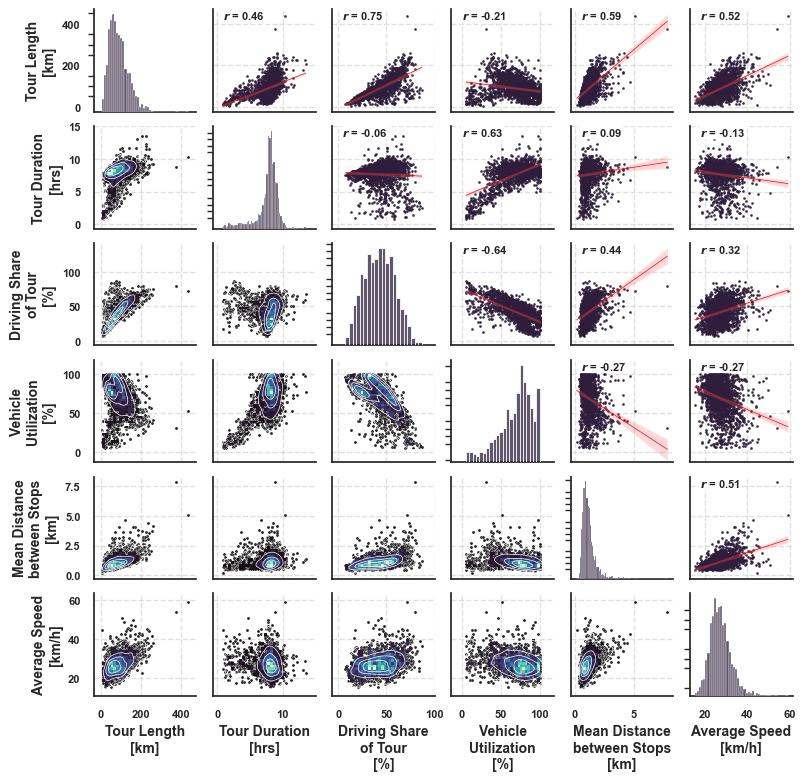

In [32]:
from scipy import stats

# --- backup rcParams touched by the pair grid --------------------------------
_rc_bak = {k: mpl.rcParams[k] for k in [
    'font.weight', 'xtick.labelsize', 'ytick.labelsize']}

mpl.rc('font', weight='bold')
mpl.rc('xtick', labelsize=8)
mpl.rc('ytick', labelsize=8)

# --- data selection -----------------------------------------------------------
data = bc_valid[['Tour Length (km)', 'Tour Duration (hrs)',
           'Driving Share of Tour (%)', 'Vehicle Utilization (%)',
           'Mean Distance Between Stops (km)', 'Average Speed (km/h)']].copy()

data.columns = ['Tour Length\n[km]',
                'Tour Duration\n[hrs]',
                'Driving Share\nof Tour\n[%]',
                'Vehicle\nUtilization\n[%]',
                'Mean Distance\nbetween Stops\n[km]',
                'Average Speed\n[km/h]']

data['Vehicle\nUtilization\n[%]'] *= 100

# --- PairGrid -----------------------------------------------------------------
g = sns.PairGrid(data, height=1.66, aspect=1.41, diag_sharey=False)

# Diagonal: histograms
def diag_hist(x, **kwargs):
    ax = plt.gca()
    if "color" not in kwargs:
        kwargs["color"] = ".3"
    sns.histplot(x=x, kde=False, **kwargs)
    for p in ax.patches:
        p.set_rasterized(True)
    ax.minorticks_on()
    ax.grid(True, linestyle="--", alpha=0.6)

g.map_diag(diag_hist)

# Upper triangle: regression + Pearson r
def regplot(x, y, **kwargs):
    sns.regplot(x=x, y=y, ci=95,
                scatter_kws={'s': 1, 'rasterized': True},
                line_kws={'color': 'red', 'linewidth': 0.5}, **kwargs)
    r, _ = stats.pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(f'$r$ = {r:.2f}', xy=(.1, .9), xycoords=ax.transAxes,
                bbox=dict(boxstyle="round,pad=0.1", ec="white",
                          fc="white", lw=0.01), fontsize=8)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', alpha=0.6)

g.map_upper(regplot)

# Lower triangle: scatter + density
def plot_lower(x, y, **kwargs):
    sns.scatterplot(x=x, y=y, s=5, color=".15", rasterized=True)
    sns.histplot(x=x, y=y, bins=30, pthresh=.1, cmap="mako")
    sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=0.5)
    ax = plt.gca()
    ax.minorticks_on()
    ax.grid(True, linestyle='--', alpha=0.6)

g.map_lower(plot_lower)

# --- axis labels + cleanup ----------------------------------------------------
for i in range(len(data.columns)):
    for j in range(len(data.columns)):
        xlabel = g.axes[i][j].get_xlabel()
        ylabel = g.axes[i][j].get_ylabel()
        if xlabel in data.columns:
            g.axes[i][j].set_xlabel(xlabel, fontsize=10, fontweight='bold')
        if ylabel in data.columns:
            g.axes[i][j].set_ylabel(ylabel, fontsize=10, fontweight='bold')

for ax in g.diag_axes:
    ax.yaxis.set_ticks([])

for ax in g.axes.flatten():
    for im in ax.images:
        im.set_rasterized(True)
    for coll in ax.collections:
        try:
            coll.set_rasterized(True)
        except Exception:
            pass

g.fig.set_size_inches(7.8, 7.8)

g.savefig("figures-and-tables/jotg_appendix_c_pairgrid.svg", dpi=300, bbox_inches='tight')
g.savefig("figures-and-tables/jotg_appendix_c_pairgrid.pdf", dpi=300, bbox_inches='tight')

plt.show()

# --- restore rcParams --------------------------------------------------------
mpl.rcParams.update(_rc_bak)

### Appendix D — Operational KPIs by Area Type

Comprehensive table of 34 operational KPIs across 7 thematic sections (Meta Data, Tour Structure, Temporal Metrics, Delivery Metrics, Load Metrics, Cost Metrics, Emission Metrics), disaggregated by both the 3 aggregated (Rural / Suburban / Urban) and 8 detailed area types. Includes a LaTeX `longtable` export for direct manuscript integration.

In [33]:
# --- Appendix D: Operational KPIs by Area Type --------------------------------
# Computed from bc_valid (filtered tours, Vehicle Utilization >= 5 %)

from collections import OrderedDict

# --- column order -------------------------------------------------------------
agg_order   = ['Rural', 'Suburban', 'Urban']
detail_order = [
    'Rural without Industrial Influence',
    'Rural with Industrial Influence',
    'Urbanized Periphery',
    'Industrial Use',
    'Residential Use',
    'Dense Mixed Use',
    'High-Density Residential Use',
    'Metropolitan Center',
]

def _build_kpi_block(grp):
    """Return an OrderedDict  {(section, kpi_label): Series} for one groupby."""
    rows = OrderedDict()

    # --- Meta Data ------------------------------------------------------------
    sec = 'Meta Data'
    rows[(sec, 'Total Vehicles all [#]')]           = grp.size()
    rows[(sec, 'Total Vehicles (Size Medium) [#]')] = grp['veh_size'].apply(lambda x: (x == 'm').sum())
    rows[(sec, 'Total Vehicles (Size Large) [#]')]  = grp['veh_size'].apply(lambda x: (x == 'l').sum())
    rows[(sec, 'Total Tour Length [km]')]            = grp['Tour Length (km)'].sum()
    rows[(sec, 'Total Number of Stops [#]')]         = grp['service_num'].sum()
    rows[(sec, 'Total Number of Deliveries [#]')]    = grp['deliveries'].sum()

    # --- Tour Structure -------------------------------------------------------
    sec = 'Tour Structure'
    rows[(sec, 'Avg. Tour Length [km]')]                   = grp['Tour Length (km)'].mean()
    rows[(sec, 'Avg. Initial Delivery Distance [km]')]     = grp['Initial Delivery Distance (km)'].mean()
    rows[(sec, 'Avg. Number of Stops [#]')]                = grp['service_num'].mean()
    rows[(sec, 'Avg. Distance Between Stops [km]')]        = grp['Mean Distance Between Stops (km)'].mean()
    rows[(sec, 'Avg. Max. Distance Between Stops [km]')]   = grp['max_dist_wo_init'].mean()
    rows[(sec, 'Avg. Delivery Area [km²]')]                = grp['delivery_area_km2'].mean()
    rows[(sec, 'Avg. Driving Share [%]')]                   = grp['Driving Share of Tour (%)'].mean()
    rows[(sec, 'Avg. Speed [km/h]')]                        = grp['Average Speed (km/h)'].mean()

    # --- Temporal Metrics -----------------------------------------------------
    sec = 'Temporal Metrics'
    rows[(sec, 'Avg. Tour Duration [hrs]')]  = grp['Tour Duration (hrs)'].mean()
    rows[(sec, 'Avg. Driving Time [hrs]')]   = grp['Driving Time (hrs)'].mean()

    # --- Delivery Metrics -----------------------------------------------------
    sec = 'Delivery Metrics'
    rows[(sec, 'Avg. Deliveries per Tour [#]')]  = grp['deliveries'].mean()
    rows[(sec, 'Avg. Deliveries per Stop [#]')]  = grp['deliveries_per_stop'].mean()
    rows[(sec, 'Avg. B2B Ratio per Tour [%]')]   = grp['b2b_ration'].mean() * 100

    # --- Load Metrics ---------------------------------------------------------
    sec = 'Load Metrics'
    rows[(sec, 'Avg. Total Weight per Tour [kg]')]         = grp['total_weight'].mean()
    rows[(sec, 'Avg. Weight per Parcel [kg]')]             = grp['avg_weight_per_parcel'].mean()
    rows[(sec, 'Avg. Vehicle Utilization per Tour [%]')]   = grp['Vehicle Utilization (%)'].mean() * 100

    # --- Cost Metrics ---------------------------------------------------------
    sec = 'Cost Metrics'
    rows[(sec, 'Total Vehicle Cost (all tours, per day) [€]')] = grp['vehicle_cost'].sum()
    rows[(sec, 'Avg. Total Vehicle Cost [€]')]                  = grp['vehicle_cost'].mean()
    rows[(sec, 'Avg. Fixed Vehicle Cost [€]')]                  = grp['vehicle_fix_cost'].mean()
    rows[(sec, 'Avg. Distance-based Cost [€]')]                 = grp['vehicle_km_cost'].mean()
    rows[(sec, 'Avg. Overtime Cost [€]')]                       = grp['overtime_cost'].mean()
    rows[(sec, 'Avg. Cost per Parcel [€/Parcel]')]              = grp['cost_per_parcel'].mean()
    rows[(sec, 'Avg. Cost per Kilogram [€/kg]')]                = grp['cost_per_kg'].mean()

    # --- Emission Metrics -----------------------------------------------------
    sec = 'Emission Metrics'
    rows[(sec, r'Total CO$_{\mathregular{2}}$ Emissions (all tours, per day) [kg]')] = grp['emissions_total_g'].sum() / 1000
    rows[(sec, r'Avg. CO$_{\mathregular{2}}$ Emissions per Tour [kg]')]              = grp['emissions_total_g'].mean() / 1000
    # Parcel-/km-/kg-weighted averages (sum emissions / sum denominator) to match Figure 9 & Table 4
    rows[(sec, r'Avg. CO$_{\mathregular{2}}$ per Parcel [g/Parcel]')]                = grp['emissions_total_g'].sum() / grp['deliveries'].sum()
    rows[(sec, r'Avg. CO$_{\mathregular{2}}$ per km [g/km]')]                        = grp['emissions_total_g'].sum() / grp['Tour Length (km)'].sum()
    rows[(sec, r'Avg. CO$_{\mathregular{2}}$ per kg Payload [g/kg]')]                = grp['emissions_total_g'].sum() / grp['total_weight'].sum()

    return rows

# --- aggregated (Rural / Suburban / Urban) ------------------------------------
grp_agg = bc_valid.groupby('area_type_agg')
kpi_agg = _build_kpi_block(grp_agg)
df_agg  = pd.DataFrame(kpi_agg).T.reindex(columns=agg_order)

# --- detailed (8 area types) -------------------------------------------------
grp_det = bc_valid.groupby('main_area_description')
kpi_det = _build_kpi_block(grp_det)
df_det  = pd.DataFrame(kpi_det).T.reindex(columns=detail_order)

# --- combine side-by-side ----------------------------------------------------
appendix_d = pd.concat([df_agg, df_det], axis=1)
appendix_d.index = pd.MultiIndex.from_tuples(appendix_d.index, names=['Section', 'KPI'])

# --- formatting ---------------------------------------------------------------
int_rows = [
    'Total Vehicles all [#]', 'Total Vehicles (Size Medium) [#]',
    'Total Vehicles (Size Large) [#]', 'Total Number of Stops [#]',
    'Total Number of Deliveries [#]',
]
euro_sum_rows = ['Total Vehicle Cost (all tours, per day) [€]',
                 r'Total CO$_{\mathregular{2}}$ Emissions (all tours, per day) [kg]']

def _fmt(val, kpi):
    if pd.isna(val):
        return '—'
    if kpi in int_rows:
        return f'{int(val):,}'
    if kpi in euro_sum_rows:
        return f'{val:,.0f}'
    return f'{val:,.2f}'

styled = appendix_d.copy()
for (sec, kpi), row in styled.iterrows():
    for col in styled.columns:
        styled.loc[(sec, kpi), col] = _fmt(appendix_d.loc[(sec, kpi), col], kpi)

appendix_d.to_csv('figures-and-tables/jotg_appendix_d_kpi_area_type.csv')

styled

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\3902720512.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '385' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  styled.loc[(sec, kpi), col] = _fmt(appendix_d.loc[(sec, kpi), col], kpi)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\3902720512.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1,007' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  styled.loc[(sec, kpi), col] = _fmt(appendix_d.loc[(sec, kpi), col], kpi)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_25328\3902720512.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '323' has dtype incompatible with float64, please

Rural  \
Section          KPI                                                             
Meta Data        Total Vehicles all [#]                                    385   
                 Total Vehicles (Size Medium) [#]                          300   
                 Total Vehicles (Size Large) [#]                            85   
                 Total Tour Length [km]                              45,758.69   
                 Total Number of Stops [#]                              22,962   
                 Total Number of Deliveries [#]                         41,698   
Tour Structure   Avg. Tour Length [km]                                  118.85   
                 Avg. Initial Delivery Distance [km]                     18.56   
                 Avg. Number of Stops [#]                                59.64   
                 Avg. Distance Between Stops [km]                         1.44   
                 Avg. Max. Distance Between Stops [km]                    8.26   
                 Avg. Delivery Area [km²]                                54.07   
                 Avg. Driving Share [%]                                  51.43   
                 Avg. Speed [km/h]                                       30.21   
Temporal Metrics Avg. Tour Duration [hrs]                                 7.65   
                 Avg. Driving Time [hrs]                                  3.91   
Delivery Metrics Avg. Deliveries per Tour [#]                           108.31   
                 Avg. Deliveries per Stop [#]                             1.96   
                 Avg. B2B Ratio per Tour [%]                             11.42   
Load Metrics     Avg. Total Weight per Tour [kg]                        481.50   
                 Avg. Weight per Parcel [kg]                              4.50   
                 Avg. Vehicle Utilization per Tour [%]                   61.05   
Cost Metrics     Total Vehicle Cost (all tours, per day) [€]            91,137   
                 Avg. Total Vehicle Cost [€]                            236.72   
                 Avg. Fixed Vehicle Cost [€]                            175.61   
                 Avg. Distance-based Cost [€]                            44.53   
                 Avg. Overtime Cost [€]                                  16.57   
                 Avg. Cost per Parcel [€/Parcel]                          2.88   
                 Avg. Cost per Kilogram [€/kg]                            0.69   
Emission Metrics Total CO$_{\mathregular{2}}$ Emissions (all tou...      9,168   
                 Avg. CO$_{\mathregular{2}}$ Emissions per Tour ...      23.81   
                 Avg. CO$_{\mathregular{2}}$ per Parcel [g/Parcel]      263.20   
                 Avg. CO$_{\mathregular{2}}$ per km [g/km]              196.34   
                 Avg. CO$_{\mathregular{2}}$ per kg Payload [g/kg]       61.68   

                                                                      Suburban  \
Section          KPI                                                             
Meta Data        Total Vehicles all [#]                                  1,007   
                 Total Vehicles (Size Medium) [#]                          646   
                 Total Vehicles (Size Large) [#]                           361   
                 Total Tour Length [km]                              90,634.33   
                 Total Number of Stops [#]                              54,882   
                 Total Number of Deliveries [#]                        131,989   
Tour Structure   Avg. Tour Length [km]                                   90.00   
                 Avg. Initial Delivery Distance [km]                     14.20   
                 Avg. Number of Stops [#]                                54.50   
                 Avg. Distance Between Stops [km]                         1.20   
                 Avg. Max. Distance Between Stops [km]                    5.90   
                 Avg. Delivery Area [km²]             

In [34]:
# --- LaTeX longtable export for Appendix D ------------------------------------

col_headers = {
    'Rural':       r'\shortstack{Rural}',
    'Suburban':    r'\shortstack{Suburban}',
    'Urban':       r'\shortstack{Urban}',
    'Rural without Industrial Influence': r'\shortstack{Rural without\\Industrial\\Influence}',
    'Rural with Industrial Influence':    r'\shortstack{Rural with\\Industrial\\Influence}',
    'Urbanized Periphery':                r'\shortstack{Urbanized\\Periphery}',
    'Industrial Use':                     r'\shortstack{Industrial\\Use}',
    'Residential Use':                    r'\shortstack{Residential\\Use}',
    'Dense Mixed Use':                    r'\shortstack{Dense\\Mixed Use}',
    'High-Density Residential Use':       r'\shortstack{High-Density\\Residential Use}',
    'Metropolitan Center':                r'\shortstack{Metropolitan\\Center}',
}

# formatting helpers
def _latex_num(val, kpi):
    """Format a single numeric value for LaTeX."""
    if pd.isna(val):
        return '—'
    if kpi in int_rows:
        return f'{int(val):,}'
    if kpi in euro_sum_rows:
        return f'{val:,.0f}'
    return f'{val:,.2f}'

def _latex_kpi(kpi):
    """Escape LaTeX-sensitive characters in KPI names."""
    return (kpi
            .replace('#', r'\#')
            .replace('%', r'\%')
            .replace('€', '€')
            .replace('²', '$^2$')
            .replace('$_2$', r'$_2$'))

lines = []
lines.append(r'\begin{landscape}')
lines.append(r'\begin{tiny}')
lines.append(r'\renewcommand{\arraystretch}{1.2}')
lines.append(r'\setlength{\tabcolsep}{3pt}')
lines.append(r'\begin{longtable}{l' + 'r' * len(appendix_d.columns) + '}')
lines.append(r'\toprule')

# header row
hdr = 'KPI & \n' + ' & \n'.join(col_headers[c] for c in appendix_d.columns) + r' \\'
lines.append(hdr)
lines.append(r'\midrule')
lines.append(r'\endfirsthead')

# repeated header
lines.append(r'\toprule')
lines.append(hdr)
lines.append(r'\midrule')
lines.append(r'\endhead')

# data rows grouped by section
prev_sec = None
for (sec, kpi), row in appendix_d.iterrows():
    if sec != prev_sec:
        lines.append(r'\addlinespace')
        lines.append(r'\multicolumn{' + str(1 + len(appendix_d.columns)) + r'}{l}{\textbf{' + sec + r'}} \\')
        prev_sec = sec
    vals = ' & '.join(_latex_num(row[c], kpi) for c in appendix_d.columns)
    lines.append(f'{_latex_kpi(kpi)} & {vals} \\\\')

lines.append('')
lines.append(r'\bottomrule')
lines.append(r'\caption{Comparison of average KPIs by spatial context for evaluating delivery performance, efficiency, cost, and emission characteristics of LMD tours.}')
lines.append(r'\label{tab:kpi_area_types}')
lines.append(r'\end{longtable}')
lines.append(r'\end{tiny}')
lines.append(r'\end{landscape}')

latex_str = '\n'.join(lines)
print(latex_str)

\begin{landscape}
\begin{tiny}
\renewcommand{\arraystretch}{1.2}
\setlength{\tabcolsep}{3pt}
\begin{longtable}{lrrrrrrrrrrr}
\toprule
KPI & 
\shortstack{Rural} & 
\shortstack{Suburban} & 
\shortstack{Urban} & 
\shortstack{Rural without\\Industrial\\Influence} & 
\shortstack{Rural with\\Industrial\\Influence} & 
\shortstack{Urbanized\\Periphery} & 
\shortstack{Industrial\\Use} & 
\shortstack{Residential\\Use} & 
\shortstack{Dense\\Mixed Use} & 
\shortstack{High-Density\\Residential Use} & 
\shortstack{Metropolitan\\Center} \\
\midrule
\endfirsthead
\toprule
KPI & 
\shortstack{Rural} & 
\shortstack{Suburban} & 
\shortstack{Urban} & 
\shortstack{Rural without\\Industrial\\Influence} & 
\shortstack{Rural with\\Industrial\\Influence} & 
\shortstack{Urbanized\\Periphery} & 
\shortstack{Industrial\\Use} & 
\shortstack{Residential\\Use} & 
\shortstack{Dense\\Mixed Use} & 
\shortstack{High-Density\\Residential Use} & 
\shortstack{Metropolitan\\Center} \\
\midrule
\endhead
\addlinespace
\multico

## 9. Summary & Generated Outputs

This notebook reproduces the complete analysis pipeline for the Journal of Transport Geography paper. All figures and tables appear in the order of the manuscript, followed by supplementary appendices that provide additional detail on logistics infrastructure, vehicle specifications, multivariate calibration diagnostics, and spatially disaggregated operational KPIs.

### Key Findings

1. **Study Area (Figure 1, Table 1):** The cluster-based classification reveals substantial structural heterogeneity across the Region Hanover, providing a meaningful basis for spatially differentiated logistics analysis.

2. **Parcel Demand (Figure 2):** The 7 simulated LSPs show distinct spatial concentration patterns, with DHL and Amazon having the broadest coverage while niche carriers concentrate in urban cores.

3. **Calibration & Validation (Table 2, Figure 3):** Average simulated Tour Duration is ~7.5 hours (consistent with literature). Street-level demand validation and tour distance distributions closely match reference data.

4. **Tour Characteristics (Table 3, Figures 4–6):** Urban tours are shortest and most efficient; rural tours are longest and least efficient. Tour KPIs systematically differ by area type.

5. **Delivery Costs (Figures 7–8):** Delivery cost per parcel decreases sublinearly with increasing delivery density. Rural areas incur the highest costs (~2.88 €/parcel), urban areas the lowest (~1.74 €/parcel).

6. **CO₂ Emissions (Figures 9–10, Table 4):** Suburban areas account for ~60% of total CO₂ emissions, rural ~27%. Urban deliveries are most efficient per parcel but generate concentrated local impacts.

### Appendices

7. **Appendix 1A — Logistics Hub Map:** Static map of all 22 simulated logistics hub locations and their service areas within the Region Hanover.

8. **Appendix 1B — Logistics Hubs Table:** Tabular summary of hub attributes including carrier, location, and hub type.

9. **Appendix B — Van Specifications:** Specifications and emission parameters of the last-mile delivery van types used in the simulation (medium and large).

10. **Appendix C — Multivariate Pair Grid:** 6 × 6 pair grid matrix showing pairwise relationships among key tour calibration KPIs (histograms, Pearson r regression, density-weighted scatter plots).

11. **Appendix D — Operational KPIs by Area Type:** Comprehensive table of 34 KPIs across 7 sections (Meta Data, Tour Structure, Temporal, Delivery, Load, Cost, Emission Metrics) disaggregated by 3 aggregated and 8 detailed area types. Includes LaTeX longtable export for direct manuscript integration.

---

### Folder Structure

All exports are saved to `figures-and-tables/` within the notebook directory:

```
journal-of-transport-geography-paper/
├── result-analysis-Journal-of-Transport-Geography-Paper.ipynb
├── result-writer-Journal-of-Transport-Geography-Paper.ipynb
└── figures-and-tables/
    ├── jotg_figure1_area_types_dual_map.pdf
    ├── jotg_figure2_carrier_distribution_maps.pdf
    ├── jotg_figure3_combined_validation_plot.pdf
    ├── jotg_figure4_hexbin_{urban,suburban,rural,total}.pdf
    ├── jotg_figure5_fleet_composition_distance.pdf
    ├── jotg_figure6a_boxplot_distributions.pdf
    ├── jotg_figure6b_ecdf_distributions.pdf
    ├── jotg_figure7_density_cost_scatter.pdf
    ├── jotg_figure8_cost_surface.svg / _cost_legend.svg / _colorbar_costs.svg
    ├── jotg_figure9_co2_benchmarking.pdf
    ├── jotg_figure10_emissions_surface.svg / _colorbar_*.svg / _legend_*.svg
    ├── jotg_appendix_a_logistics_hubs.pdf
    ├── jotg_appendix_c_pairgrid.{svg,pdf}
    ├── jotg_table2_descriptive_kpis.csv
    ├── jotg_table3_result_raumtyp_diff.csv
    ├── jotg_table3_result_raumtyp_agg.csv
    ├── jotg_table4_network_metrics_{agg,detail}.csv
    └── jotg_appendix_d_kpi_area_type.csv
```


### Generated Figures

| File(s) | Paper Element | Description |
|:---|:---|:---|
| `jotg_figure1_area_types_dual_map.pdf` | Figure 1 | Study area characterization |
| `jotg_figure2_carrier_distribution_maps.pdf` | Figure 2 | Carrier-level parcel distribution (7 × 3) |
| `jotg_figure3_combined_validation_plot.pdf` | Figure 3 | Demand validation (regression + distance) |
| `jotg_figure4_hexbin_{urban,suburban,rural,total}.pdf` | Figure 4 | Hexbin: Tour length vs. vehicle utilization (4 panels) |
| `jotg_figure5_fleet_composition_distance.pdf` | Figure 5 | Fleet composition & driven distance |
| `jotg_figure6a_boxplot_distributions.pdf`, `jotg_figure6b_ecdf_distributions.pdf` | Figure 6 | Boxplots + ECDFs by area type (2 files) |
| `jotg_figure7_density_cost_scatter.pdf` | Figure 7 | Delivery density vs. cost per parcel |
| `jotg_figure8_cost_surface.svg`, `jotg_figure8_cost_legend.svg`, `jotg_figure8_colorbar_costs.svg` | Figure 8 | Spatial delivery cost surface + legend + colorbar |
| `jotg_figure9_co2_benchmarking.pdf` | Figure 9 | CO₂ benchmarking by area type |
| `jotg_figure10_emissions_surface.svg`, `jotg_figure10_colorbar_emissions.svg`, `jotg_figure10_colorbar_traffic.svg`, `jotg_figure10_legend_area_types_agg.svg` | Figure 10 | Spatial CO₂ emissions surface + colorbars + legend |
| `jotg_appendix_a_logistics_hubs.pdf` | Appendix 1A | Logistics hub map |
| `jotg_appendix_c_pairgrid.pdf` | Appendix C | Multivariate pair grid of tour KPIs |

### Generated Tables

| File | Paper Element | Description |
|:---|:---|:---|
| `jotg_table2_descriptive_kpis.csv` | Table 2 | Descriptive statistics of operational KPIs |
| `jotg_table3_result_raumtyp_diff.csv` | Table 3 | Detailed area type statistics (8 categories) |
| `jotg_table3_result_raumtyp_agg.csv` | Table 3 | Aggregated area type statistics (3 categories) |
| `jotg_table4_network_metrics_agg.csv` | Table 4 | Aggregated network metrics (3 categories) |
| `jotg_table4_network_metrics_detail.csv` | Table 4 | Detailed network metrics (8 categories) |
| `jotg_appendix_d_kpi_area_type.csv` | Appendix D | 34 KPIs × 11 area-type columns |

### LaTeX Exports

| Cell | Paper Element | Description |
|:---|:---|:---|
| Appendix D (LaTeX cell) | Appendix D | `longtable` environment — 34 KPIs × 11 area-type columns, landscape orientation |

